In [1]:
import sys
print(sys.executable)

C:\Users\edanp\OneDrive\Desktop\DS\10\IRModels\PROJECT\Fair-RAG\.venv\Scripts\python.exe


In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

2.1.2+cu121
True
NVIDIA GeForce RTX 4070 Laptop GPU


# Fair-RAG Experiment Runner

Runs a full Fair-RAG evaluation (EE + EU + Diversity) for a chosen model / ranker / reranker combination.

**How to use:**
1. Edit the toggles in **Cell 2** (Configuration).
2. Run all cells sequentially.
3. The run directory is printed at the end; artefacts live in `experiment_runs/<run_id>/`.

In [2]:
"""Cell 1 — Imports"""
import copy
import os
import sys

# Ensure repo root is importable when notebook cwd is the repo root
REPO_ROOT = os.path.abspath(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    ExperimentRunner,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    build_query_metric_rows,
    list_run_dirs,
    maybe_to_dataframe,
    setting_id,
)


def format_macro_table_for_display(df):
    if df is None:
        return df

    table = df.copy()

    def _rerank_with_param(row):
        method = row.get("rerank_method")
        if method == "pl":
            return f"pl(a={row.get('pl_alpha')}, s={row.get('pl_samples')})"
        if method == "mmr":
            return f"mmr(λ={row.get('mmr_lambda')})"
        return "deterministic"

    table["dataset"] = table.apply(
        lambda r: f"{r.get('dataset_type')}:{r.get('lamp_num')}:{r.get('lamp_split_type')}", axis=1
    )
    table["ranking model"] = table["ranker"]
    table["LLM model"] = table["generator_name"]
    table["re-ranking method"] = table.apply(_rerank_with_param, axis=1)
    table["EU"] = table["expected_utility"]
    table["ILD"] = table["avg_ild_jaccard"]
    table["Jaccard"] = table["avg_jaccard_mean"]
    table["EE-D"] = table["ee_disparity"]
    table["EE-R"] = table["ee_relevance"]

    return table[
        [
            "dataset",
            "ranking model",
            "LLM model",
            "re-ranking method",
            "EU",
            "ILD",
            "Jaccard",
            "EE-D",
            "EE-R",
        ]
    ]


print("Imports OK")

Imports OK


## Configuration

Edit the variables below, then run this cell before running the experiment.

| Toggle | Options |
|--------|---------|
| `DATASET_TYPE` | `"lamp"` (TREC-RAG: future) |
| `LAMP_NUM` | `1`–`7` |
| `LAMP_SPLIT_TYPE` | `"user"` \| `"time"` |
| `GENERATOR_NAME` | `"flanT5Small"` \| `"flanT5Base"` \| `"flanT5XXL"` \| `"bonsai8BMLX1bit"` \| `"lfm25MLX12B4bit"` \| `"qwen35MLX4B4bit"` |
| `RANKER` | `"bm25"` \| `"splade"` \| `"contriever"` \| `"gold"` |
| `RERANK_METHOD` | `"pl"` \| `"mmr"` \| `"deterministic"` |
| `TOP_K` | integer (documents per list) |
| `NUM_QUERIES` | integer or `None` (all) |
| `PL_SAMPLES` | number of stochastic PL samples (ignored for MMR/det) |
| `PL_ALPHA` | temperature (`1`=uniform, higher=more deterministic) |
| `MMR_LAMBDA` | `0.0`–`1.0` (higher=more relevance-focused) |
| `BATCH_REUSE_POLICY` | `"smart"` \| `"fresh"` \| `"resume-only"` |
| `RESUME` | single-run only: `True` to resume an explicit existing run |
| `RUN_ID` | single-run only: explicit existing run id to resume |

In [ ]:
# =============================================================================
# EXPERIMENT TOGGLES — edit these values to configure your run
# =============================================================================

# --- Execution mode ----------------------------------------------------------
RUN_MODE             = "batch"    # "single" | "batch"
REPORT_EVERY_QUERIES = 50         # print rolling avg EU / EE / diversity every N queries
BATCH_REUSE_POLICY   = "smart"    # "smart" | "fresh" | "resume-only"
RESUME               = False      # single-run only: True = resume an explicit existing run_id
RUN_ID               = None       # single-run only: set to an existing run ID string to resume
BATCH_ID             = "lamp2_bm25_mmr_pl"  # optional explicit batch id

# --- Dataset -----------------------------------------------------------------
DATASET_TYPE    = "lamp"         # "lamp" (TREC-RAG: future)
LAMP_NUM        = 2              # LaMP task number (1–7)
LAMP_SPLIT_TYPE = "user"         # "user" | "time"
NUM_QUERIES     = None           # int or None (None = all queries)

# --- Retrieval ---------------------------------------------------------------
RANKER          = "bm25"         # "bm25" | "splade" | "contriever" | "gold"
TOP_K           = 5              # documents per ranked list

# --- Re-ranking --------------------------------------------------------------
RERANK_METHOD   = "deterministic"  # base default for single-run mode
PL_ALPHA        = 4              # PL temperature (higher = more deterministic)
PL_SAMPLES      = 10             # number of stochastic PL lists per query
MMR_LAMBDA      = 0.55           # MMR trade-off (1=fully relevance, 0=fully diverse)
SEED            = 42             # full-run seed used for reranking and generation

# --- Generator (LLM) ---------------------------------------------------------
GENERATOR_NAME  = "flanT5Small"  # e.g. "flanT5Small" | "flanT5Base" | "flanT5XXL"
MULTI_GPU       = False          # True to use distributed inference

# --- Metrics -----------------------------------------------------------------
COMPUTE_EE        = True         # Expected Exposure (EE-D, EE-R, EE-L)
COMPUTE_EU        = True         # Expected Utility (task-specific metric)
COMPUTE_DIVERSITY = True         # ILD-Jaccard + mean Jaccard similarity

# --- Flush/checkpoint cadence ------------------------------------------------
FLUSH_EVERY = 1                 # flush manifest after every N completed (qid, list_id) units

# =============================================================================
# Build base RunConfig from toggles
# =============================================================================

base_cfg = RunConfig(
    dataset=DatasetConfig(
        dataset_type=DATASET_TYPE,
        lamp_num=LAMP_NUM,
        lamp_split_type=LAMP_SPLIT_TYPE,
        num_queries=NUM_QUERIES,
    ),
    retrieval=RetrievalConfig(
        ranker=RANKER,
        top_k=TOP_K,
    ),
    rerank=RerankConfig(
        method=RERANK_METHOD,
        pl_alpha=PL_ALPHA,
        pl_samples=PL_SAMPLES,
        mmr_lambda=MMR_LAMBDA,
        seed=SEED,
    ),
    generation=GenerationConfig(
        generator_name=GENERATOR_NAME,
        multi_gpu=MULTI_GPU,
    ),
    metrics=MetricsConfig(
        compute_ee=COMPUTE_EE,
        compute_eu=COMPUTE_EU,
        compute_diversity=COMPUTE_DIVERSITY,
    ),
    checkpoint=CheckpointConfig(
        flush_every=FLUSH_EVERY,
        report_every_queries=REPORT_EVERY_QUERIES,
    ),
    resume=RESUME,
    run_id=RUN_ID,
)

# =============================================================================
# Batch overrides: BM25 reranking comparison
#   - deterministic baseline
#   - MMR (lambda=0.55)
#   - PL (alpha=1, 2, 4, 8) with 10 samples each
# =============================================================================

BATCH_OVERRIDES = [
    {
        "ranker": "bm25",
        "rerank_method": "deterministic",
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "mmr",
        "mmr_lambda": 0.55,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 1,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 2,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 4,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 8,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
]


def build_cfg_from_override(base: RunConfig, override: dict) -> RunConfig:
    cfg = copy.deepcopy(base)
    cfg.resume = False
    cfg.run_id = None
    if "generator_name" in override:
        cfg.generation.generator_name = override["generator_name"]
    if "ranker" in override:
        cfg.retrieval.ranker = override["ranker"]
    if "top_k" in override:
        cfg.retrieval.top_k = override["top_k"]
    if "num_queries" in override:
        cfg.dataset.num_queries = override["num_queries"]
    if "rerank_method" in override:
        cfg.rerank.method = override["rerank_method"]
    if "pl_alpha" in override:
        cfg.rerank.pl_alpha = override["pl_alpha"]
    if "pl_samples" in override:
        cfg.rerank.pl_samples = override["pl_samples"]
    if "mmr_lambda" in override:
        cfg.rerank.mmr_lambda = override["mmr_lambda"]
    if "seed" in override:
        cfg.rerank.seed = override["seed"]
    if "resume" in override:
        cfg.resume = override["resume"]
    if "run_id" in override:
        cfg.run_id = override["run_id"]
    return cfg


batch_cfgs = [build_cfg_from_override(base_cfg, item) for item in BATCH_OVERRIDES]

print("Base setting ID:", setting_id(base_cfg))
print("Run mode:", RUN_MODE)
if RUN_MODE == "batch":
    print("Batch reuse policy:", BATCH_REUSE_POLICY)
    print("Batch setting IDs:")
    for cfg in batch_cfgs:
        print("  -", setting_id(cfg))

Base setting ID: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42
Run mode: batch
Batch reuse policy: smart
Batch setting IDs:
  - lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42
  - lamp1_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
  - lamp1_user__flanT5Small__bm25__pl_a1_s10__k5__nqall__seed42
  - lamp1_user__flanT5Small__bm25__pl_a2_s10__k5__nqall__seed42
  - lamp1_user__flanT5Small__bm25__pl_a4_s10__k5__nqall__seed42
  - lamp1_user__flanT5Small__bm25__pl_a8_s10__k5__nqall__seed42


## Run Experiment

Execute the cell below to start the experiment.  
In batch mode, rerunning the same cell will automatically skip completed matching settings and resume interrupted matching settings when `BATCH_REUSE_POLICY = "smart"`.

In [9]:
if RUN_MODE == "single":
    runner = ExperimentRunner(base_cfg)
    run_output = runner.run()
    run_dirs = [run_output.run_dir]
else:
    batch_runner = BatchExperimentRunner(
        batch_cfgs,
        batch_id=BATCH_ID,
        reuse_policy=BATCH_REUSE_POLICY,
    )
    batch_output = batch_runner.run_all()
    run_dirs = batch_output["run_dirs"]

print("Completed run directories:")
for path in run_dirs:
    print("  -", path)

[Batch] Starting run 1/6: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 8042.36it/s]


Setting: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.2928, ILD=0.8756, EU=0.1200
Setting: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 51 queries: EE-D=1.0000, EE-R=0.3056, ILD=0.8755, EU=0.1176
Completed setting: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260416_160216_lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260416_160216_lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42/macro_summary.json
[Batch] Starting run 2/6: lamp1_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
Setting: lamp1_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
Setting: lamp1_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.2838, ILD=0.8926, EU=0.0800
Setting: lamp1_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42 | 

## Results Summary

Inspect aggregated metrics across all processed queries.

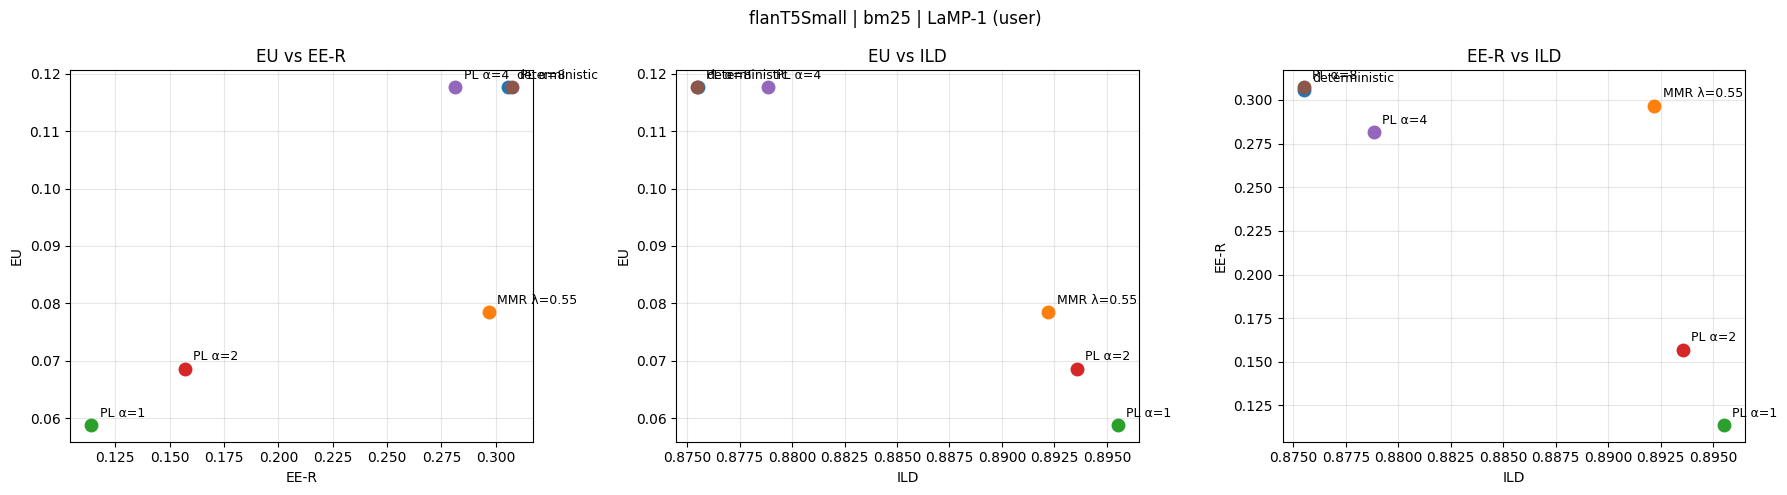

Macro comparison rows:


,dataset,ranking model,LLM model,re-ranking method,EU,ILD,Jaccard,EE-D,EE-R
0,lamp:1:user,bm25,flanT5Small,deterministic,0.117647,0.875496,0.124504,1.000000,0.305603
1,lamp:1:user,bm25,flanT5Small,mmr(λ=0.55),0.078431,0.892207,0.107793,1.000000,0.296762
2,lamp:1:user,bm25,flanT5Small,"pl(a=1, s=10)",0.058824,0.895525,0.104475,0.150275,0.113871
3,lamp:1:user,bm25,flanT5Small,"pl(a=2, s=10)",0.068627,0.893574,0.106426,0.178039,0.156987
4,lamp:1:user,bm25,flanT5Small,"pl(a=4, s=10)",0.117647,0.878841,0.121159,0.697882,0.281387
5,lamp:1:user,bm25,flanT5Small,"pl(a=8, s=10)",0.117647,0.875487,0.124513,0.964235,0.307319



Loaded rows:
  Run-level rows  : 6
  Query-level rows: (hidden)


In [18]:
import matplotlib.pyplot as plt

macro_rows = build_macro_comparison_rows(run_dirs)

macro_table = maybe_to_dataframe(macro_rows)
query_table = None

def reranker_label(row):
    method = row.get("rerank_method")
    if method == "mmr":
        return f"MMR λ={row.get('mmr_lambda')}"
    if method == "deterministic":
        return "deterministic"
    return f"PL α={row.get('pl_alpha')}"


def run_context_title(rows):
    if not rows:
        return "No rows to plot"
    sample = rows[0]
    dataset = f"LaMP-{sample.get('lamp_num')} ({sample.get('lamp_split_type')})"
    llm = sample.get("generator_name")
    ranker = sample.get("ranker")
    return f"{llm} | {ranker} | {dataset}"


# Use all rows from the selected run_dirs so this works for both BM25 and Gold batches.
plot_rows = macro_rows
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(run_context_title(plot_rows), fontsize=12)
plots = [
    ("ee_relevance", "expected_utility", "EE-R", "EU"),
    ("avg_ild_jaccard", "expected_utility", "ILD", "EU"),
    ("avg_ild_jaccard", "ee_relevance", "ILD", "EE-R"),
]

for ax, (x_key, y_key, x_label, y_label) in zip(axes, plots):
    for row in plot_rows:
        x = row.get(x_key)
        y = row.get(y_key)
        if x is None or y is None:
            continue
        label = reranker_label(row)
        ax.plot(x, y, marker="o", linestyle="None", markersize=9)
        ax.annotate(label, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"{y_label} vs {x_label}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Macro comparison rows:")
display(format_macro_table_for_display(macro_table))

print("\nLoaded rows:")
print(f"  Run-level rows  : {len(macro_rows)}")
print("  Query-level rows: (hidden)")

## BM25 Batch Analysis — flanT5Small, LaMP-4 (all queries)

Reranking comparison: BM25+det, BM25+MMR(λ=0.55), BM25+PL(α∈{1,2,4,8})

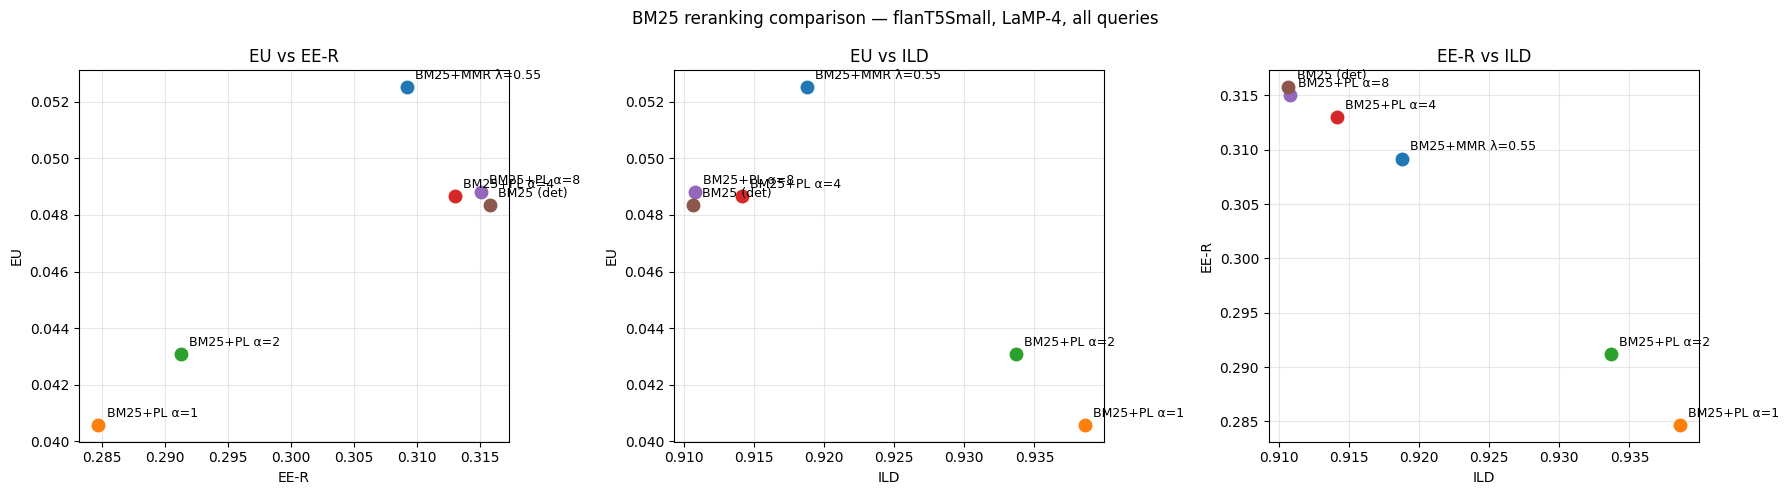

BM25 macro comparison rows:


,n_queries,metric_name,expected_utility,max_utility,min_utility,avg_ild_jaccard,avg_jaccard_mean,ee_disparity,ee_relevance,ee_difference,...,lamp_split_type,generator_name,ranker,rerank_method,pl_alpha,pl_samples,mmr_lambda,top_k,num_queries_config,run_dir
0,833,rouge-l,0.052520,0.052520,0.052520,0.918768,0.081232,1.000000,0.309192,0.854995,...,user,flanT5Small,bm25,mmr,1,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
1,833,rouge-l,0.040576,0.107557,0.005358,0.938581,0.061419,0.206660,0.284683,0.242270,...,user,flanT5Small,bm25,pl,1,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
2,833,rouge-l,0.043083,0.109661,0.006296,0.933666,0.066334,0.248658,0.291219,0.268361,...,user,flanT5Small,bm25,pl,2,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
3,833,rouge-l,0.048664,0.089461,0.020699,0.914125,0.085875,0.706415,0.312993,0.623159,...,user,flanT5Small,bm25,pl,4,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
4,833,rouge-l,0.048803,0.057382,0.041346,0.910765,0.089235,0.958795,0.315043,0.820582,...,user,flanT5Small,bm25,pl,8,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
5,833,rouge-l,0.048353,0.048353,0.048353,0.910675,0.089325,1.000000,0.315762,0.851408,...,user,flanT5Small,bm25,deterministic,1,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...



  Run-level rows: 6


In [ ]:
import os
import matplotlib.pyplot as plt
from framework import build_macro_comparison_rows, maybe_to_dataframe

_RUNS_ROOT = os.path.join(REPO_ROOT, "experiment_runs")
bm25_run_dirs = [
    os.path.join(_RUNS_ROOT, "20260415_204153_lamp4_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42"),
    os.path.join(_RUNS_ROOT, "20260415_210055_lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nqall__seed42"),
    os.path.join(_RUNS_ROOT, "20260415_235822_lamp4_user__flanT5Small__bm25__pl_a2_s10__k5__nqall__seed42"),
    os.path.join(_RUNS_ROOT, "20260416_025517_lamp4_user__flanT5Small__bm25__pl_a4_s10__k5__nqall__seed42"),
    os.path.join(_RUNS_ROOT, "20260416_055951_lamp4_user__flanT5Small__bm25__pl_a8_s10__k5__nqall__seed42"),
    os.path.join(_RUNS_ROOT, "20260416_085915_lamp4_user__flanT5Small__bm25__det__k5__nqall__seed42"),
]

bm25_macro_rows = build_macro_comparison_rows(bm25_run_dirs)
bm25_macro_table = maybe_to_dataframe(bm25_macro_rows)


def bm25_label(row):
    method = row.get("rerank_method", "")
    if method == "deterministic":
        return "BM25 (det)"
    if method == "mmr":
        return f"BM25+MMR λ={row.get('mmr_lambda')}"
    return f"BM25+PL α={row.get('pl_alpha')}"


bm25_plots = [
    ("ee_relevance",   "expected_utility", "EE-R", "EU"),
    ("avg_ild_jaccard","expected_utility",  "ILD",  "EU"),
    ("avg_ild_jaccard","ee_relevance",       "ILD",  "EE-R"),
]

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("BM25 reranking comparison — flanT5Small, LaMP-4, all queries", fontsize=12)

for ax, (x_key, y_key, x_label, y_label) in zip(axes2, bm25_plots):
    for row in bm25_macro_rows:
        x = row.get(x_key)
        y = row.get(y_key)
        if x is None or y is None:
            continue
        lbl = bm25_label(row)
        ax.plot(x, y, marker="o", linestyle="None", markersize=9)
        ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"{y_label} vs {x_label}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("BM25 macro comparison rows:")
display(format_macro_table_for_display(bm25_macro_table))
print(f"\n  Run-level rows: {len(bm25_macro_rows)}")

## BM25 Batch Analysis — flanT5Small, LaMP-1 (all queries)

Reranking comparison: BM25+det, BM25+MMR(λ=0.55), BM25+PL(α∈{1,2,4,8})

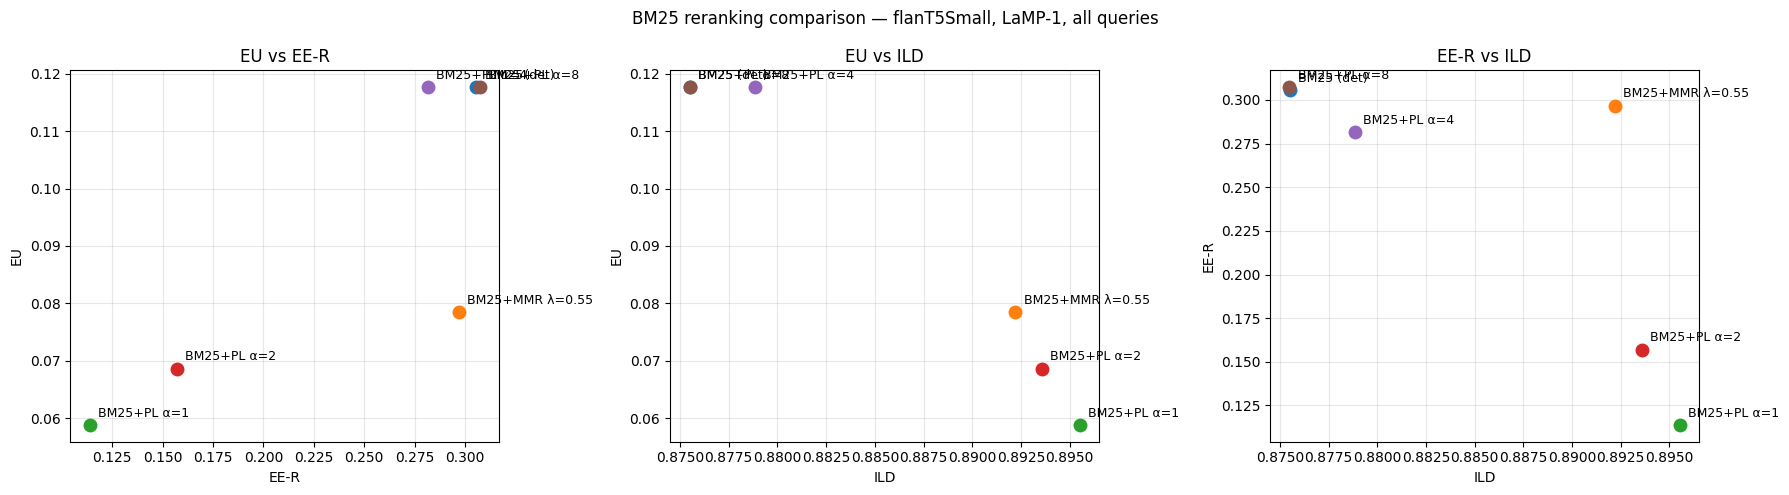

LaMP-1 BM25 macro comparison rows:


,n_queries,metric_name,expected_utility,max_utility,min_utility,avg_ild_jaccard,avg_jaccard_mean,ee_disparity,ee_relevance,ee_difference,...,lamp_split_type,generator_name,ranker,rerank_method,pl_alpha,pl_samples,mmr_lambda,top_k,num_queries_config,run_dir
0,51,acc,0.117647,0.117647,0.117647,0.875496,0.124504,1.000000,0.305603,0.809642,...,user,flanT5Small,bm25,deterministic,4,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
1,51,acc,0.078431,0.078431,0.078431,0.892207,0.107793,1.000000,0.296762,0.816774,...,user,flanT5Small,bm25,mmr,4,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
2,51,acc,0.058824,0.176471,0.039216,0.895525,0.104475,0.150275,0.113871,0.369895,...,user,flanT5Small,bm25,pl,1,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
3,51,acc,0.068627,0.196078,0.039216,0.893574,0.106426,0.178039,0.156987,0.359936,...,user,flanT5Small,bm25,pl,2,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
4,51,acc,0.117647,0.274510,0.058824,0.878841,0.121159,0.697882,0.281387,0.622690,...,user,flanT5Small,bm25,pl,4,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
5,51,acc,0.117647,0.117647,0.117647,0.875487,0.124513,0.964235,0.307319,0.785096,...,user,flanT5Small,bm25,pl,8,10,0.55,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...



  Run-level rows: 6


In [ ]:
import os
import matplotlib.pyplot as plt
from framework import build_macro_comparison_rows, maybe_to_dataframe

# Run dirs are populated from batch_output after the experiment above completes
lamp1_bm25_run_dirs = run_dirs  # set by the Run Experiment cell

lamp1_bm25_macro_rows = build_macro_comparison_rows(lamp1_bm25_run_dirs)
lamp1_bm25_macro_table = maybe_to_dataframe(lamp1_bm25_macro_rows)


def lamp1_bm25_label(row):
    method = row.get("rerank_method", "")
    if method == "deterministic":
        return "BM25 (det)"
    if method == "mmr":
        return f"BM25+MMR λ={row.get('mmr_lambda')}"
    return f"BM25+PL α={row.get('pl_alpha')}"


_plots = [
    ("ee_relevance",    "expected_utility", "EE-R", "EU"),
    ("avg_ild_jaccard", "expected_utility",  "ILD",  "EU"),
    ("avg_ild_jaccard", "ee_relevance",       "ILD",  "EE-R"),
]

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle("BM25 reranking comparison — flanT5Small, LaMP-1, all queries", fontsize=12)

for ax, (x_key, y_key, x_label, y_label) in zip(axes3, _plots):
    for row in lamp1_bm25_macro_rows:
        x = row.get(x_key)
        y = row.get(y_key)
        if x is None or y is None:
            continue
        lbl = lamp1_bm25_label(row)
        ax.plot(x, y, marker="o", linestyle="None", markersize=9)
        ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"{y_label} vs {x_label}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("LaMP-1 BM25 macro comparison rows:")
display(format_macro_table_for_display(lamp1_bm25_macro_table))
print(f"\n  Run-level rows: {len(lamp1_bm25_macro_rows)}")

---
## LaMP-2 — BM25 Reranking Batch

BM25+det, BM25+MMR(λ=0.55), BM25+PL(α∈{1,2,4,8}) — flanT5Small, all queries

In [11]:
# LaMP-2 batch: update config and run
import copy
from framework import BatchExperimentRunner, RunConfig, DatasetConfig, RetrievalConfig, RerankConfig, GenerationConfig, MetricsConfig, CheckpointConfig, setting_id

_lamp2_base = RunConfig(
    dataset=DatasetConfig(dataset_type="lamp", lamp_num=2, lamp_split_type="user", num_queries=None),
    retrieval=RetrievalConfig(ranker="bm25", top_k=5),
    rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=42),
    generation=GenerationConfig(generator_name="flanT5Small", multi_gpu=False),
    metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
    checkpoint=CheckpointConfig(flush_every=1, report_every_queries=50),
    resume=False, run_id=None,
)

_lamp2_overrides = [
    {"rerank_method": "deterministic"},
    {"rerank_method": "mmr", "mmr_lambda": 0.55},
    {"rerank_method": "pl", "pl_alpha": 1, "pl_samples": 10},
    {"rerank_method": "pl", "pl_alpha": 2, "pl_samples": 10},
    {"rerank_method": "pl", "pl_alpha": 4, "pl_samples": 10},
    {"rerank_method": "pl", "pl_alpha": 8, "pl_samples": 10},
]

def _apply_override(base, ov):
    cfg = copy.deepcopy(base); cfg.resume = False; cfg.run_id = None
    if "rerank_method" in ov: cfg.rerank.method = ov["rerank_method"]
    if "pl_alpha" in ov: cfg.rerank.pl_alpha = ov["pl_alpha"]
    if "pl_samples" in ov: cfg.rerank.pl_samples = ov["pl_samples"]
    if "mmr_lambda" in ov: cfg.rerank.mmr_lambda = ov["mmr_lambda"]
    return cfg

_lamp2_cfgs = [_apply_override(_lamp2_base, o) for o in _lamp2_overrides]
print("LaMP-2 settings:"); [print(" -", setting_id(c)) for c in _lamp2_cfgs]

_lamp2_batch = BatchExperimentRunner(_lamp2_cfgs, batch_id="lamp2_bm25_mmr_pl", reuse_policy="smart")
_lamp2_out = _lamp2_batch.run_all()
lamp2_run_dirs = _lamp2_out["run_dirs"]
print("LaMP-2 batch complete. Dirs:"); [print(" -", d) for d in lamp2_run_dirs]

LaMP-2 settings:
 - lamp2_user__flanT5Small__bm25__det__k5__nqall__seed42
 - lamp2_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
 - lamp2_user__flanT5Small__bm25__pl_a1_s10__k5__nqall__seed42
 - lamp2_user__flanT5Small__bm25__pl_a2_s10__k5__nqall__seed42
 - lamp2_user__flanT5Small__bm25__pl_a4_s10__k5__nqall__seed42
 - lamp2_user__flanT5Small__bm25__pl_a8_s10__k5__nqall__seed42
[Batch] Starting run 1/6: lamp2_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp2_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp2_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.1974, ILD=0.9131, EU=0.0600
Setting: lamp2_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 100 queries: EE-D=1.0000, EE-R=0.2530, ILD=0.9122, EU=0.1000
Setting: lamp2_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 150 queries: EE-D=1.0000, EE-R=0.2632, ILD=0.9115, EU=0.1067
Setting: lamp2_user__flanT5Small__bm25__det__k5__n

[None, None, None, None, None, None]

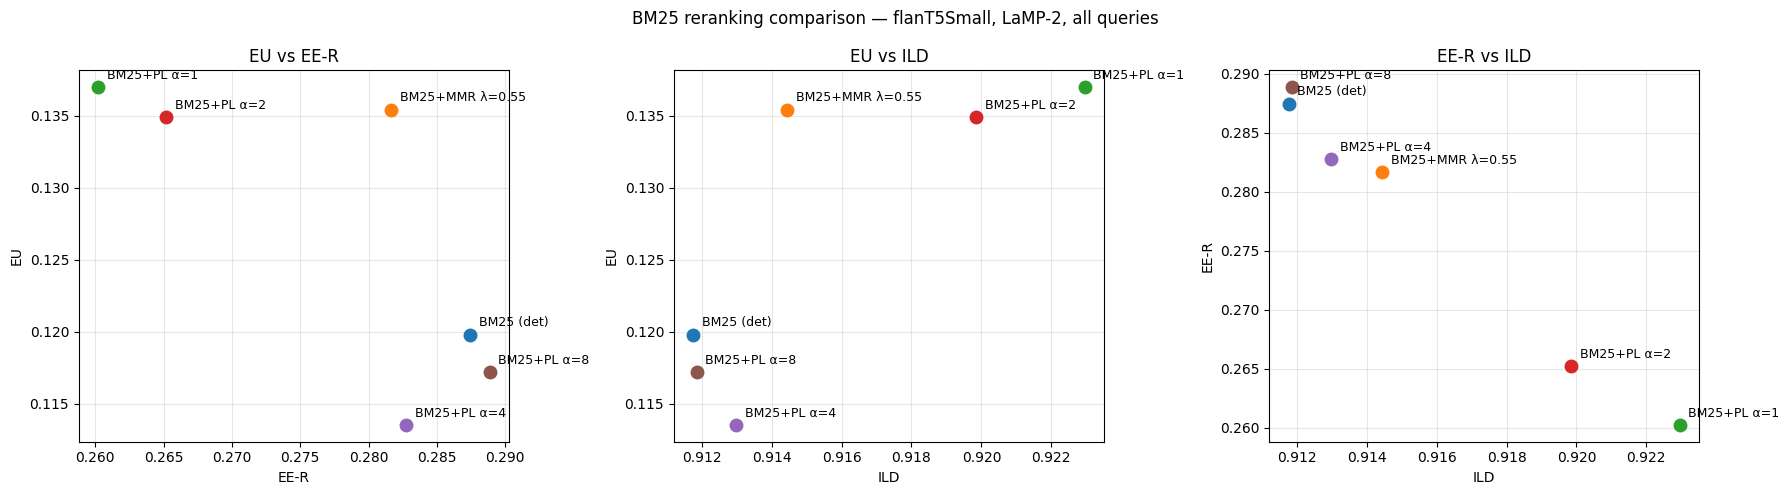

LaMP-2 macro rows:


,dataset,ranking model,LLM model,re-ranking method,EU,ILD,Jaccard,EE-D,EE-R
0,lamp:2:user,bm25,flanT5Small,deterministic,0.119792,0.911765,0.088235,0.997917,0.287464
1,lamp:2:user,bm25,flanT5Small,mmr(λ=0.55),0.135417,0.914451,0.085549,0.997917,0.281661
2,lamp:2:user,bm25,flanT5Small,"pl(a=1, s=10)",0.136979,0.922951,0.077049,0.300771,0.260230
3,lamp:2:user,bm25,flanT5Small,"pl(a=2, s=10)",0.134896,0.919857,0.080143,0.356792,0.265191
4,lamp:2:user,bm25,flanT5Small,"pl(a=4, s=10)",0.113542,0.912991,0.087009,0.723646,0.282768
5,lamp:2:user,bm25,flanT5Small,"pl(a=8, s=10)",0.117188,0.911862,0.088138,0.973833,0.288861



  Run-level rows: 6


In [15]:
import matplotlib.pyplot as plt
from framework import build_macro_comparison_rows, maybe_to_dataframe

def _bm25_label(row):
    m = row.get("rerank_method", "")
    if m == "deterministic": return "BM25 (det)"
    if m == "mmr": return f"BM25+MMR λ={row.get('mmr_lambda')}"
    return f"BM25+PL α={row.get('pl_alpha')}"

lamp2_macro_rows = build_macro_comparison_rows(lamp2_run_dirs)
lamp2_macro_table = maybe_to_dataframe(lamp2_macro_rows)

_p = [("ee_relevance","expected_utility","EE-R","EU"),("avg_ild_jaccard","expected_utility","ILD","EU"),("avg_ild_jaccard","ee_relevance","ILD","EE-R")]
fig4, axes4 = plt.subplots(1, 3, figsize=(18, 5))
fig4.suptitle("BM25 reranking comparison — flanT5Small, LaMP-2, all queries", fontsize=12)
for ax, (xk, yk, xl, yl) in zip(axes4, _p):
    for row in lamp2_macro_rows:
        x, y = row.get(xk), row.get(yk)
        if x is None or y is None: continue
        ax.plot(x, y, marker="o", linestyle="None", markersize=9)
        ax.annotate(_bm25_label(row), (x, y), textcoords="offset points", xytext=(6,6), fontsize=9)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(f"{yl} vs {xl}"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("LaMP-2 macro rows:"); display(format_macro_table_for_display(lamp2_macro_table))
print(f"\n  Run-level rows: {len(lamp2_macro_rows)}")

---
## LaMP-3 — BM25 Reranking Batch

BM25+det, BM25+MMR(λ=0.55), BM25+PL(α∈{1,2,4,8}) — flanT5Small, all queries

In [19]:
import copy
from framework import BatchExperimentRunner, RunConfig, DatasetConfig, RetrievalConfig, RerankConfig, GenerationConfig, MetricsConfig, CheckpointConfig, setting_id

_lamp3_base = RunConfig(
    dataset=DatasetConfig(dataset_type="lamp", lamp_num=3, lamp_split_type="user", num_queries=None),
    retrieval=RetrievalConfig(ranker="bm25", top_k=5),
    rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=42),
    generation=GenerationConfig(generator_name="flanT5Small", multi_gpu=False),
    metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
    checkpoint=CheckpointConfig(flush_every=1, report_every_queries=50),
    resume=False, run_id=None,
)
_lamp3_cfgs = [_apply_override(_lamp3_base, o) for o in _lamp2_overrides]  # same overrides
print("LaMP-3 settings:"); [print(" -", setting_id(c)) for c in _lamp3_cfgs]

_lamp3_batch = BatchExperimentRunner(_lamp3_cfgs, batch_id="lamp3_bm25_mmr_pl", reuse_policy="smart")
_lamp3_out = _lamp3_batch.run_all()
lamp3_run_dirs = _lamp3_out["run_dirs"]
print("LaMP-3 batch complete.")

LaMP-3 settings:
 - lamp3_user__flanT5Small__bm25__det__k5__nqall__seed42
 - lamp3_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
 - lamp3_user__flanT5Small__bm25__pl_a1_s10__k5__nqall__seed42
 - lamp3_user__flanT5Small__bm25__pl_a2_s10__k5__nqall__seed42
 - lamp3_user__flanT5Small__bm25__pl_a4_s10__k5__nqall__seed42
 - lamp3_user__flanT5Small__bm25__pl_a8_s10__k5__nqall__seed42
[Batch] Starting run 1/6: lamp3_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp3_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp3_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.3483, ILD=0.8169, EU=0.4200
Setting: lamp3_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 100 queries: EE-D=1.0000, EE-R=0.3262, ILD=0.8298, EU=0.4600
Setting: lamp3_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 150 queries: EE-D=1.0000, EE-R=0.3674, ILD=0.8296, EU=0.4733
Setting: lamp3_user__flanT5Small__bm25__det__k5__n

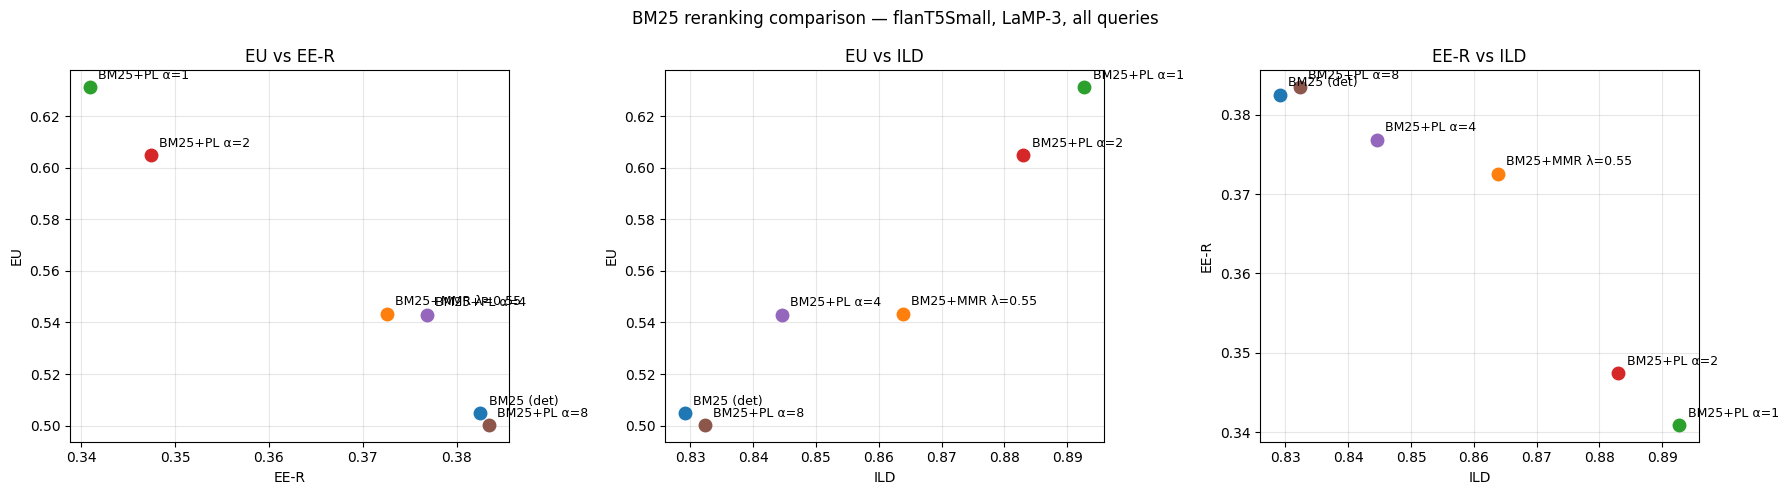

LaMP-3 macro rows:


,dataset,ranking model,LLM model,re-ranking method,EU,ILD,Jaccard,EE-D,EE-R
0,lamp:3:user,bm25,flanT5Small,deterministic,0.504823,0.829148,0.170852,1.000000,0.382497
1,lamp:3:user,bm25,flanT5Small,mmr(λ=0.55),0.543408,0.863803,0.136197,1.000000,0.372571
2,lamp:3:user,bm25,flanT5Small,"pl(a=1, s=10)",0.631190,0.892707,0.107293,0.130418,0.340942
3,lamp:3:user,bm25,flanT5Small,"pl(a=2, s=10)",0.604823,0.883010,0.116990,0.148412,0.347450
4,lamp:3:user,bm25,flanT5Small,"pl(a=4, s=10)",0.543087,0.844527,0.155473,0.557569,0.376846
5,lamp:3:user,bm25,flanT5Small,"pl(a=8, s=10)",0.500322,0.832259,0.167741,0.900502,0.383450



  Run-level rows: 6


In [20]:
import matplotlib.pyplot as plt
from framework import build_macro_comparison_rows, maybe_to_dataframe

lamp3_macro_rows = build_macro_comparison_rows(lamp3_run_dirs)
lamp3_macro_table = maybe_to_dataframe(lamp3_macro_rows)

fig5, axes5 = plt.subplots(1, 3, figsize=(18, 5))
fig5.suptitle("BM25 reranking comparison — flanT5Small, LaMP-3, all queries", fontsize=12)
for ax, (xk, yk, xl, yl) in zip(axes5, _p):
    for row in lamp3_macro_rows:
        x, y = row.get(xk), row.get(yk)
        if x is None or y is None: continue
        ax.plot(x, y, marker="o", linestyle="None", markersize=9)
        ax.annotate(_bm25_label(row), (x, y), textcoords="offset points", xytext=(6,6), fontsize=9)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(f"{yl} vs {xl}"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("LaMP-3 macro rows:"); display(format_macro_table_for_display(lamp3_macro_table))
print(f"\n  Run-level rows: {len(lamp3_macro_rows)}")

---
## LaMP-5 — BM25 Reranking Batch

BM25+det, BM25+MMR(λ=0.55), BM25+PL(α∈{1,2,4,8}) — flanT5Small, all queries

In [21]:
import copy
from framework import BatchExperimentRunner, RunConfig, DatasetConfig, RetrievalConfig, RerankConfig, GenerationConfig, MetricsConfig, CheckpointConfig, setting_id

_lamp5_base = RunConfig(
    dataset=DatasetConfig(dataset_type="lamp", lamp_num=5, lamp_split_type="user", num_queries=None),
    retrieval=RetrievalConfig(ranker="bm25", top_k=5),
    rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=42),
    generation=GenerationConfig(generator_name="flanT5Small", multi_gpu=False),
    metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
    checkpoint=CheckpointConfig(flush_every=1, report_every_queries=50),
    resume=False, run_id=None,
)
_lamp5_cfgs = [_apply_override(_lamp5_base, o) for o in _lamp2_overrides]
print("LaMP-5 settings:"); [print(" -", setting_id(c)) for c in _lamp5_cfgs]

_lamp5_batch = BatchExperimentRunner(_lamp5_cfgs, batch_id="lamp5_bm25_mmr_pl", reuse_policy="smart")
_lamp5_out = _lamp5_batch.run_all()
lamp5_run_dirs = _lamp5_out["run_dirs"]
print("LaMP-5 batch complete.")

LaMP-5 settings:
 - lamp5_user__flanT5Small__bm25__det__k5__nqall__seed42
 - lamp5_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
 - lamp5_user__flanT5Small__bm25__pl_a1_s10__k5__nqall__seed42
 - lamp5_user__flanT5Small__bm25__pl_a2_s10__k5__nqall__seed42
 - lamp5_user__flanT5Small__bm25__pl_a4_s10__k5__nqall__seed42
 - lamp5_user__flanT5Small__bm25__pl_a8_s10__k5__nqall__seed42
[Batch] Starting run 1/6: lamp5_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp5_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp5_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.4509, ILD=0.8485, EU=0.2027
Setting: lamp5_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 100 queries: EE-D=1.0000, EE-R=0.3854, ILD=0.8508, EU=0.2032
Setting: lamp5_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 150 queries: EE-D=1.0000, EE-R=0.4013, ILD=0.8494, EU=0.1801
Setting: lamp5_user__flanT5Small__bm25__det__k5__n

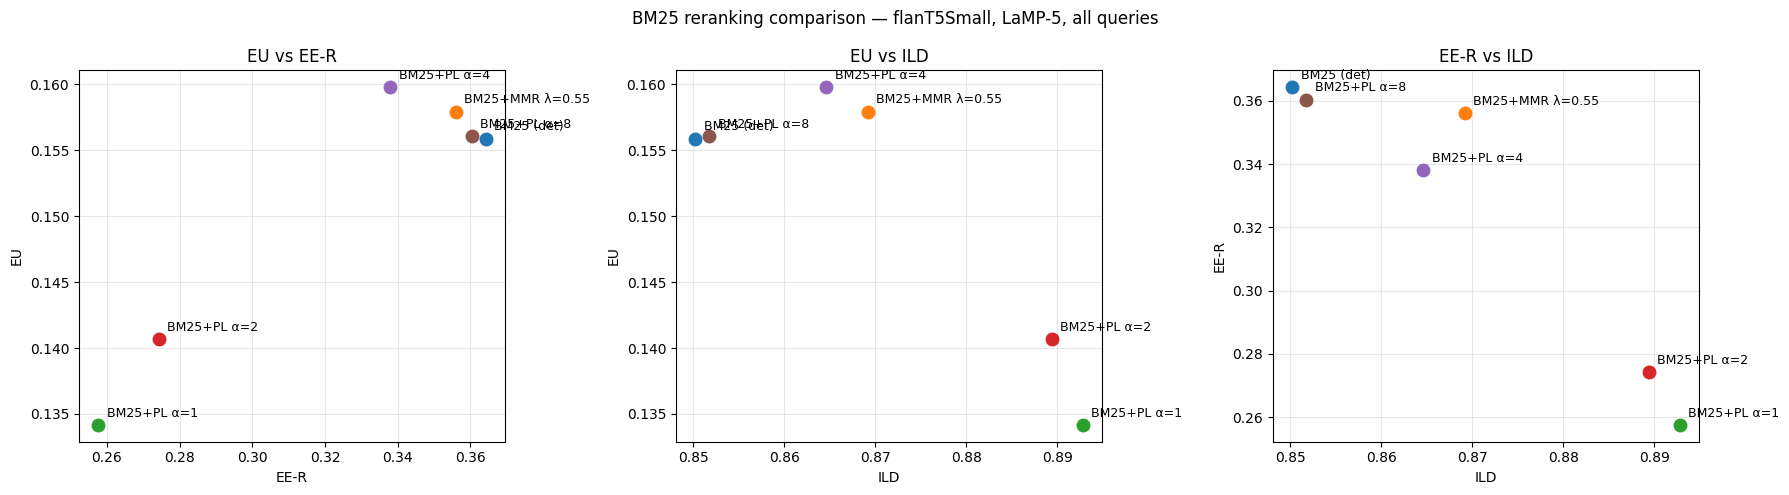

LaMP-5 macro rows:


,dataset,ranking model,LLM model,re-ranking method,EU,ILD,Jaccard,EE-D,EE-R
0,lamp:5:user,bm25,flanT5Small,deterministic,0.155879,0.850239,0.149761,1.000000,0.364268
1,lamp:5:user,bm25,flanT5Small,mmr(λ=0.55),0.157934,0.869202,0.130798,1.000000,0.355990
2,lamp:5:user,bm25,flanT5Small,"pl(a=1, s=10)",0.134171,0.892797,0.107203,0.156436,0.257602
3,lamp:5:user,bm25,flanT5Small,"pl(a=2, s=10)",0.140669,0.889382,0.110618,0.180387,0.274208
4,lamp:5:user,bm25,flanT5Small,"pl(a=4, s=10)",0.159783,0.864616,0.135384,0.581695,0.338014
5,lamp:5:user,bm25,flanT5Small,"pl(a=8, s=10)",0.156085,0.851782,0.148218,0.910794,0.360360



  Run-level rows: 6


In [22]:
import matplotlib.pyplot as plt
from framework import build_macro_comparison_rows, maybe_to_dataframe

lamp5_macro_rows = build_macro_comparison_rows(lamp5_run_dirs)
lamp5_macro_table = maybe_to_dataframe(lamp5_macro_rows)

fig6, axes6 = plt.subplots(1, 3, figsize=(18, 5))
fig6.suptitle("BM25 reranking comparison — flanT5Small, LaMP-5, all queries", fontsize=12)
for ax, (xk, yk, xl, yl) in zip(axes6, _p):
    for row in lamp5_macro_rows:
        x, y = row.get(xk), row.get(yk)
        if x is None or y is None: continue
        ax.plot(x, y, marker="o", linestyle="None", markersize=9)
        ax.annotate(_bm25_label(row), (x, y), textcoords="offset points", xytext=(6,6), fontsize=9)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(f"{yl} vs {xl}"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("LaMP-5 macro rows:"); display(format_macro_table_for_display(lamp5_macro_table))
print(f"\n  Run-level rows: {len(lamp5_macro_rows)}")

---
## LaMP-6 — BM25 Reranking Batch

BM25+det, BM25+MMR(λ=0.55), BM25+PL(α∈{1,2,4,8}) — flanT5Small, all queries

In [23]:
import copy
from framework import BatchExperimentRunner, RunConfig, DatasetConfig, RetrievalConfig, RerankConfig, GenerationConfig, MetricsConfig, CheckpointConfig, setting_id

_lamp6_base = RunConfig(
    dataset=DatasetConfig(dataset_type="lamp", lamp_num=6, lamp_split_type="user", num_queries=None),
    retrieval=RetrievalConfig(ranker="bm25", top_k=5),
    rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=42),
    generation=GenerationConfig(generator_name="flanT5Small", multi_gpu=False),
    metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
    checkpoint=CheckpointConfig(flush_every=1, report_every_queries=50),
    resume=False, run_id=None,
)
_lamp6_cfgs = [_apply_override(_lamp6_base, o) for o in _lamp2_overrides]
print("LaMP-6 settings:"); [print(" -", setting_id(c)) for c in _lamp6_cfgs]

_lamp6_batch = BatchExperimentRunner(_lamp6_cfgs, batch_id="lamp6_bm25_mmr_pl", reuse_policy="smart")
_lamp6_out = _lamp6_batch.run_all()
lamp6_run_dirs = _lamp6_out["run_dirs"]
print("LaMP-6 batch complete.")

LaMP-6 settings:
 - lamp6_user__flanT5Small__bm25__det__k5__nqall__seed42
 - lamp6_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
 - lamp6_user__flanT5Small__bm25__pl_a1_s10__k5__nqall__seed42
 - lamp6_user__flanT5Small__bm25__pl_a2_s10__k5__nqall__seed42
 - lamp6_user__flanT5Small__bm25__pl_a4_s10__k5__nqall__seed42
 - lamp6_user__flanT5Small__bm25__pl_a8_s10__k5__nqall__seed42
[Batch] Starting run 1/6: lamp6_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp6_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp6_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.4596, ILD=0.5634, EU=0.2219
Setting: lamp6_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 100 queries: EE-D=1.0000, EE-R=0.4229, ILD=0.6055, EU=0.1877
Setting: lamp6_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 150 queries: EE-D=1.0000, EE-R=0.4527, ILD=0.5318, EU=0.1879
Setting: lamp6_user__flanT5Small__bm25__det__k5__n

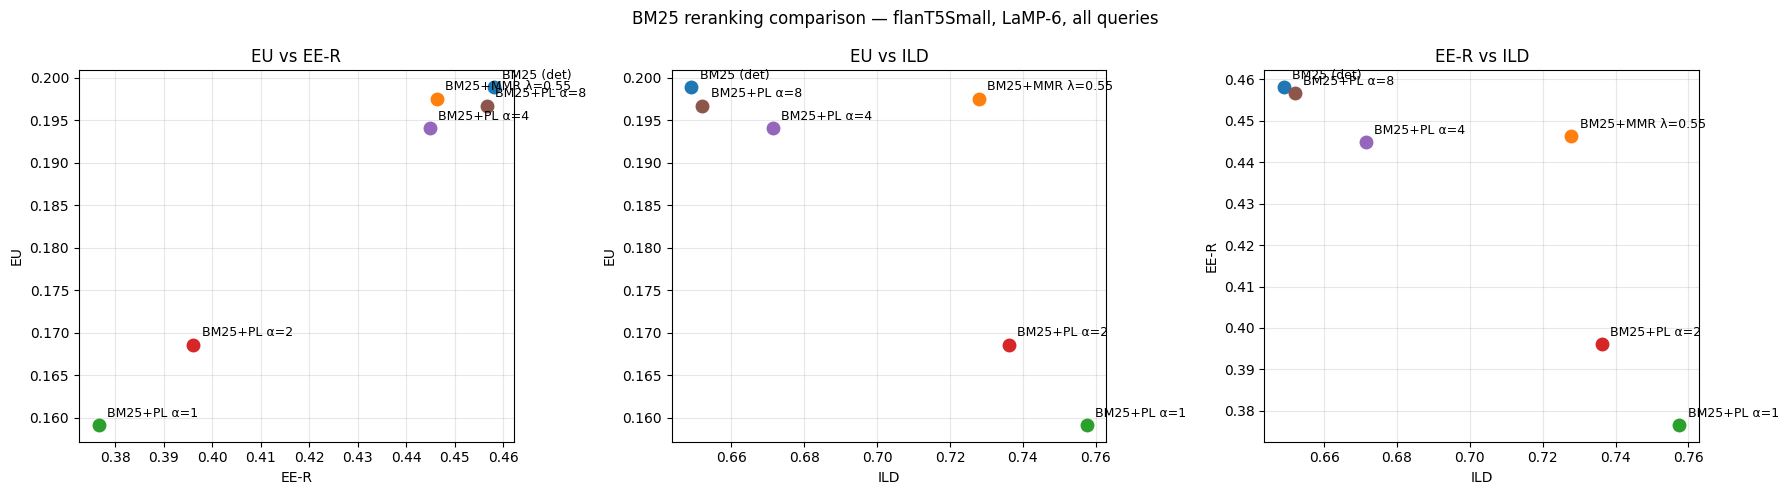

LaMP-6 macro rows:


,dataset,ranking model,LLM model,re-ranking method,EU,ILD,Jaccard,EE-D,EE-R
0,lamp:6:user,bm25,flanT5Small,deterministic,0.198872,0.649020,0.350980,1.000000,0.458115
1,lamp:6:user,bm25,flanT5Small,mmr(λ=0.55),0.197543,0.727858,0.272142,1.000000,0.446298
2,lamp:6:user,bm25,flanT5Small,"pl(a=1, s=10)",0.159182,0.757510,0.242490,0.198484,0.376614
3,lamp:6:user,bm25,flanT5Small,"pl(a=2, s=10)",0.168619,0.736223,0.263777,0.237463,0.396111
4,lamp:6:user,bm25,flanT5Small,"pl(a=4, s=10)",0.194071,0.671453,0.328547,0.614779,0.444837
5,lamp:6:user,bm25,flanT5Small,"pl(a=8, s=10)",0.196717,0.652045,0.347955,0.911758,0.456604



  Run-level rows: 6


In [24]:
import matplotlib.pyplot as plt
from framework import build_macro_comparison_rows, maybe_to_dataframe

lamp6_macro_rows = build_macro_comparison_rows(lamp6_run_dirs)
lamp6_macro_table = maybe_to_dataframe(lamp6_macro_rows)

fig7, axes7 = plt.subplots(1, 3, figsize=(18, 5))
fig7.suptitle("BM25 reranking comparison — flanT5Small, LaMP-6, all queries", fontsize=12)
for ax, (xk, yk, xl, yl) in zip(axes7, _p):
    for row in lamp6_macro_rows:
        x, y = row.get(xk), row.get(yk)
        if x is None or y is None: continue
        ax.plot(x, y, marker="o", linestyle="None", markersize=9)
        ax.annotate(_bm25_label(row), (x, y), textcoords="offset points", xytext=(6,6), fontsize=9)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(f"{yl} vs {xl}"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("LaMP-6 macro rows:"); display(format_macro_table_for_display(lamp6_macro_table))
print(f"\n  Run-level rows: {len(lamp6_macro_rows)}")

---
## LaMP-7 — BM25 Reranking Batch

BM25+det, BM25+MMR(λ=0.55), BM25+PL(α∈{1,2,4,8}) — flanT5Small, all queries

In [25]:
import copy
from framework import BatchExperimentRunner, RunConfig, DatasetConfig, RetrievalConfig, RerankConfig, GenerationConfig, MetricsConfig, CheckpointConfig, setting_id

_lamp7_base = RunConfig(
    dataset=DatasetConfig(dataset_type="lamp", lamp_num=7, lamp_split_type="user", num_queries=None),
    retrieval=RetrievalConfig(ranker="bm25", top_k=5),
    rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=42),
    generation=GenerationConfig(generator_name="flanT5Small", multi_gpu=False),
    metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
    checkpoint=CheckpointConfig(flush_every=1, report_every_queries=50),
    resume=False, run_id=None,
)
_lamp7_cfgs = [_apply_override(_lamp7_base, o) for o in _lamp2_overrides]
print("LaMP-7 settings:"); [print(" -", setting_id(c)) for c in _lamp7_cfgs]

_lamp7_batch = BatchExperimentRunner(_lamp7_cfgs, batch_id="lamp7_bm25_mmr_pl", reuse_policy="smart")
_lamp7_out = _lamp7_batch.run_all()
lamp7_run_dirs = _lamp7_out["run_dirs"]
print("LaMP-7 batch complete.")

LaMP-7 settings:
 - lamp7_user__flanT5Small__bm25__det__k5__nqall__seed42
 - lamp7_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
 - lamp7_user__flanT5Small__bm25__pl_a1_s10__k5__nqall__seed42
 - lamp7_user__flanT5Small__bm25__pl_a2_s10__k5__nqall__seed42
 - lamp7_user__flanT5Small__bm25__pl_a4_s10__k5__nqall__seed42
 - lamp7_user__flanT5Small__bm25__pl_a8_s10__k5__nqall__seed42
[Batch] Starting run 1/6: lamp7_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp7_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp7_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.5031, ILD=0.9418, EU=0.2183
Setting: lamp7_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 100 queries: EE-D=1.0000, EE-R=0.5222, ILD=0.9400, EU=0.1848
Setting: lamp7_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 150 queries: EE-D=1.0000, EE-R=0.5072, ILD=0.9420, EU=0.1844
Setting: lamp7_user__flanT5Small__bm25__det__k5__n

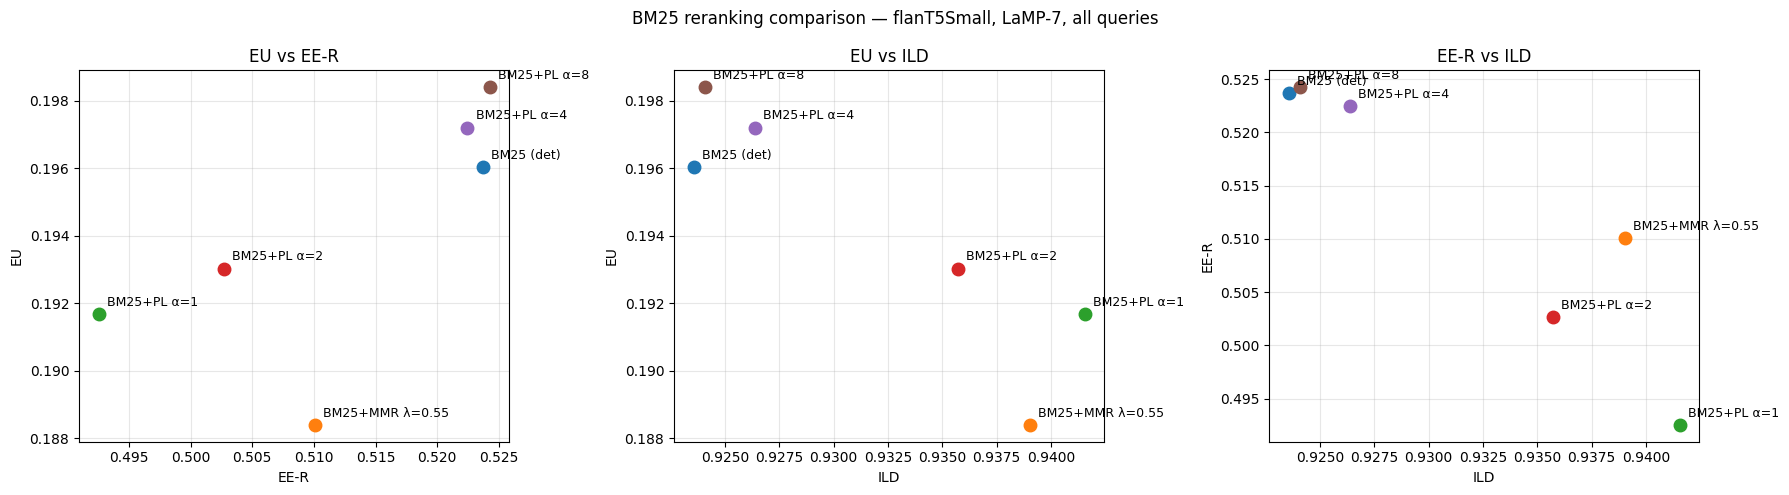

LaMP-7 macro rows:


,dataset,ranking model,LLM model,re-ranking method,EU,ILD,Jaccard,EE-D,EE-R
0,lamp:7:user,bm25,flanT5Small,deterministic,0.196020,0.923566,0.076434,1.000000,0.523675
1,lamp:7:user,bm25,flanT5Small,mmr(λ=0.55),0.188392,0.939024,0.060976,1.000000,0.510070
2,lamp:7:user,bm25,flanT5Small,"pl(a=1, s=10)",0.191665,0.941546,0.058454,0.441063,0.492541
3,lamp:7:user,bm25,flanT5Small,"pl(a=2, s=10)",0.193025,0.935719,0.064281,0.535134,0.502671
4,lamp:7:user,bm25,flanT5Small,"pl(a=4, s=10)",0.197194,0.926375,0.073625,0.770915,0.522432
5,lamp:7:user,bm25,flanT5Small,"pl(a=8, s=10)",0.198398,0.924077,0.075923,0.920384,0.524236



  Run-level rows: 6


In [26]:
import matplotlib.pyplot as plt
from framework import build_macro_comparison_rows, maybe_to_dataframe

lamp7_macro_rows = build_macro_comparison_rows(lamp7_run_dirs)
lamp7_macro_table = maybe_to_dataframe(lamp7_macro_rows)

fig8, axes8 = plt.subplots(1, 3, figsize=(18, 5))
fig8.suptitle("BM25 reranking comparison — flanT5Small, LaMP-7, all queries", fontsize=12)
for ax, (xk, yk, xl, yl) in zip(axes8, _p):
    for row in lamp7_macro_rows:
        x, y = row.get(xk), row.get(yk)
        if x is None or y is None: continue
        ax.plot(x, y, marker="o", linestyle="None", markersize=9)
        ax.annotate(_bm25_label(row), (x, y), textcoords="offset points", xytext=(6,6), fontsize=9)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(f"{yl} vs {xl}"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("LaMP-7 macro rows:"); display(format_macro_table_for_display(lamp7_macro_table))
print(f"\n  Run-level rows: {len(lamp7_macro_rows)}")

In [ ]:
# -----------------------------------------------------------------------------
# Normalized BM25 Graphs — LaMP 1 through 7
#
# Per-query normalization for plotting:
# - EE-R: starts from stored per-query EE-R (already normalized in expected_exposure).
# - EU: paper-style per-query normalization using query-level utility bounds.
# - ILD: normalized per query with the same max-based scheme.
# -----------------------------------------------------------------------------

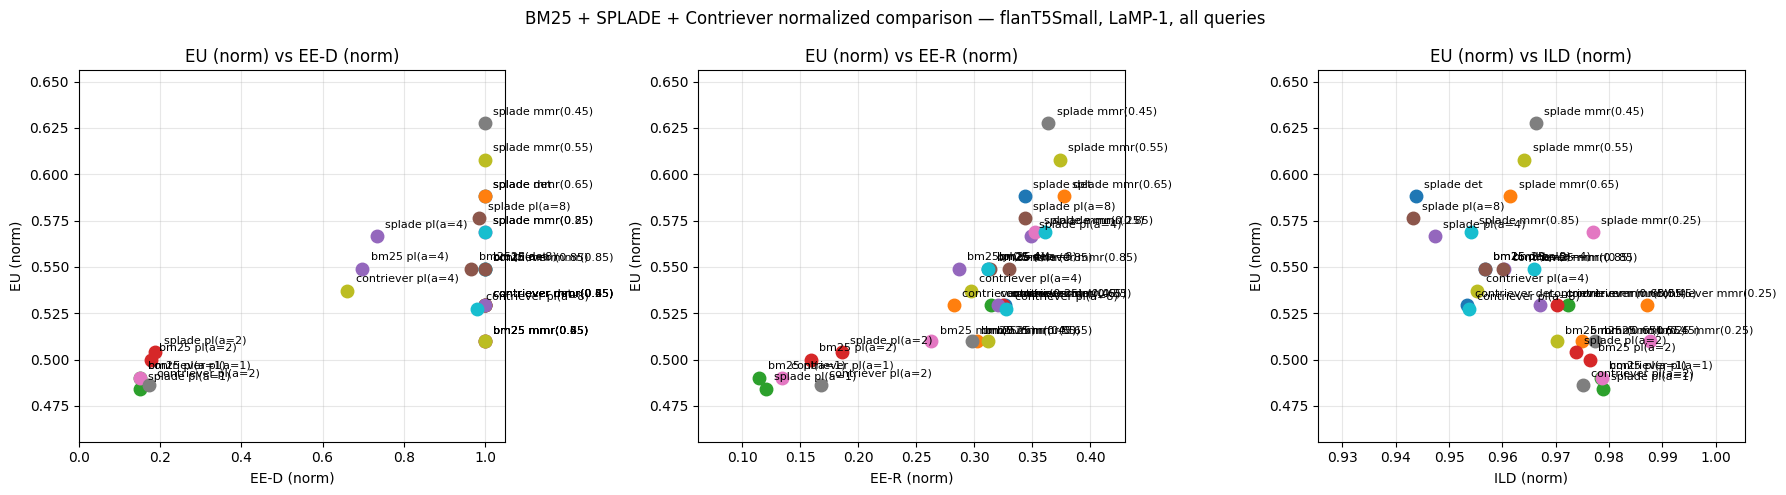

LaMP-1 normalized macro rows (BM25 + SPLADE + Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
17,1,flanT5Small,splade,mmr,4,0.45,0.363725,1.000000,0.627451,0.966285
18,1,flanT5Small,splade,mmr,4,0.55,0.373529,1.000000,0.607843,0.964118
10,1,flanT5Small,splade,deterministic,4,0.65,0.343464,1.000000,0.588235,0.943772
11,1,flanT5Small,splade,mmr,4,0.65,0.377451,1.000000,0.588235,0.961505
15,1,flanT5Small,splade,pl,8,0.65,0.343464,0.985961,0.576471,0.943286
16,1,flanT5Small,splade,mmr,4,0.25,0.352614,1.000000,0.568627,0.976914
19,1,flanT5Small,splade,mmr,4,0.85,0.361111,1.000000,0.568627,0.954125
14,1,flanT5Small,splade,pl,4,0.65,0.348660,0.734275,0.566667,0.947375
0,1,flanT5Small,bm25,deterministic,4,0.55,0.312092,1.000000,0.549020,0.956665
9,1,flanT5Small,bm25,mmr,4,0.85,0.312092,1.000000,0.549020,0.965950


  Run-level rows: 30



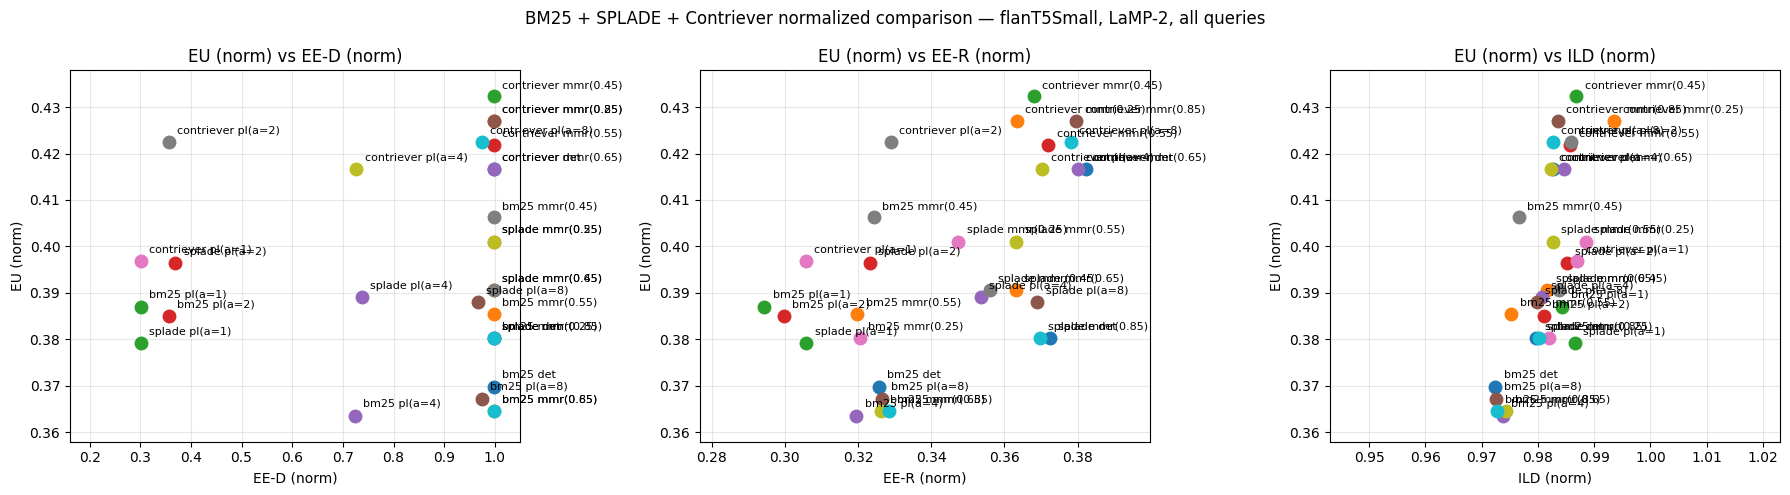

LaMP-2 normalized macro rows (BM25 + SPLADE + Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
22,2,flanT5Small,contriever,mmr,4,0.45,0.367969,0.997917,0.432292,0.986861
21,2,flanT5Small,contriever,mmr,4,0.25,0.363368,0.997917,0.427083,0.993619
25,2,flanT5Small,contriever,mmr,4,0.85,0.379601,0.997917,0.427083,0.983513
27,2,flanT5Small,contriever,pl,2,0.65,0.328976,0.356833,0.422396,0.985844
29,2,flanT5Small,contriever,pl,8,0.65,0.378203,0.974292,0.422396,0.982687
23,2,flanT5Small,contriever,mmr,4,0.55,0.371962,0.997917,0.421875,0.985784
20,2,flanT5Small,contriever,deterministic,4,0.65,0.382205,0.997917,0.416667,0.982644
24,2,flanT5Small,contriever,mmr,4,0.65,0.379948,0.997917,0.416667,0.984575
28,2,flanT5Small,contriever,pl,4,0.65,0.370347,0.726729,0.416667,0.982327
7,2,flanT5Small,bm25,mmr,4,0.45,0.324392,0.997917,0.406250,0.976593


  Run-level rows: 30



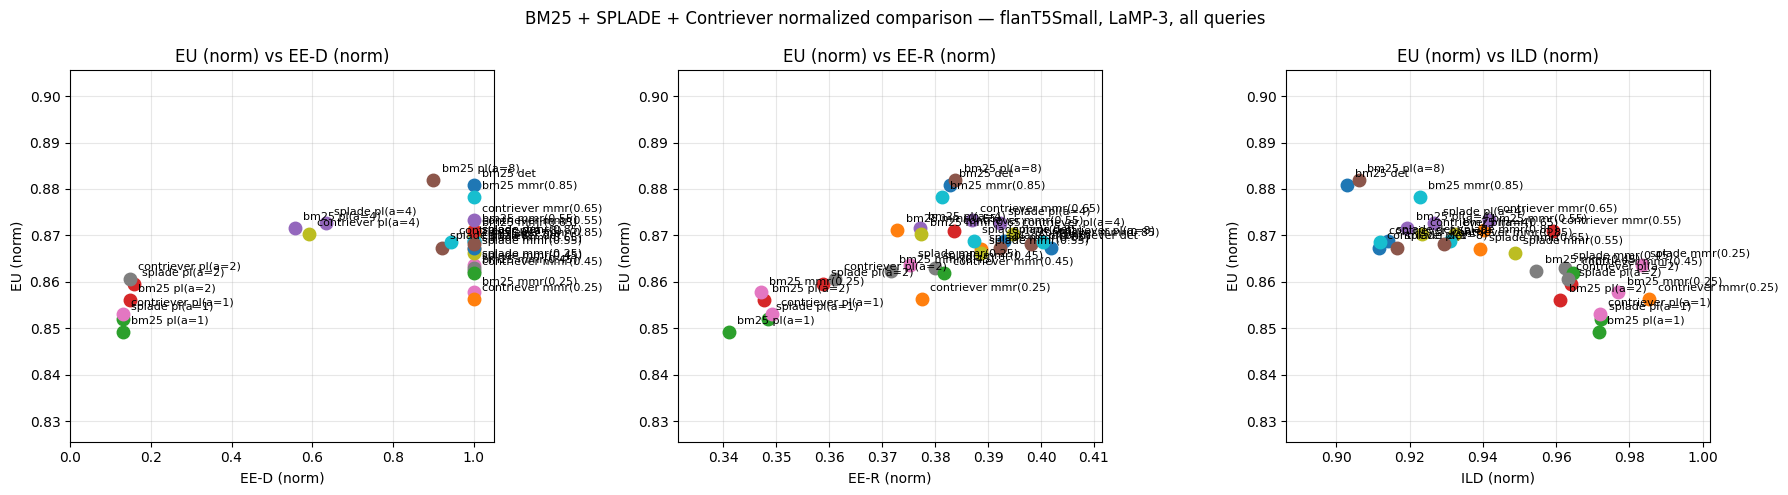

LaMP-3 normalized macro rows (BM25 + SPLADE + Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
5,3,flanT5Small,bm25,pl,8,0.55,0.383783,0.900502,0.881886,0.906117
0,3,flanT5Small,bm25,deterministic,4,0.55,0.382851,1.000000,0.880761,0.902833
9,3,flanT5Small,bm25,mmr,4,0.85,0.381243,1.000000,0.878349,0.922863
24,3,flanT5Small,contriever,mmr,4,0.65,0.386870,1.000000,0.873258,0.941620
14,3,flanT5Small,splade,pl,4,0.65,0.392245,0.632977,0.872669,0.926748
4,3,flanT5Small,bm25,pl,4,0.55,0.377138,0.557569,0.871543,0.919383
1,3,flanT5Small,bm25,mmr,4,0.55,0.372883,1.000000,0.871115,0.940239
23,3,flanT5Small,contriever,mmr,4,0.55,0.383655,1.000000,0.870847,0.959116
8,3,flanT5Small,bm25,mmr,4,0.65,0.377385,1.000000,0.870311,0.932378
28,3,flanT5Small,contriever,pl,4,0.65,0.394753,0.592424,0.870311,0.923405


  Run-level rows: 30



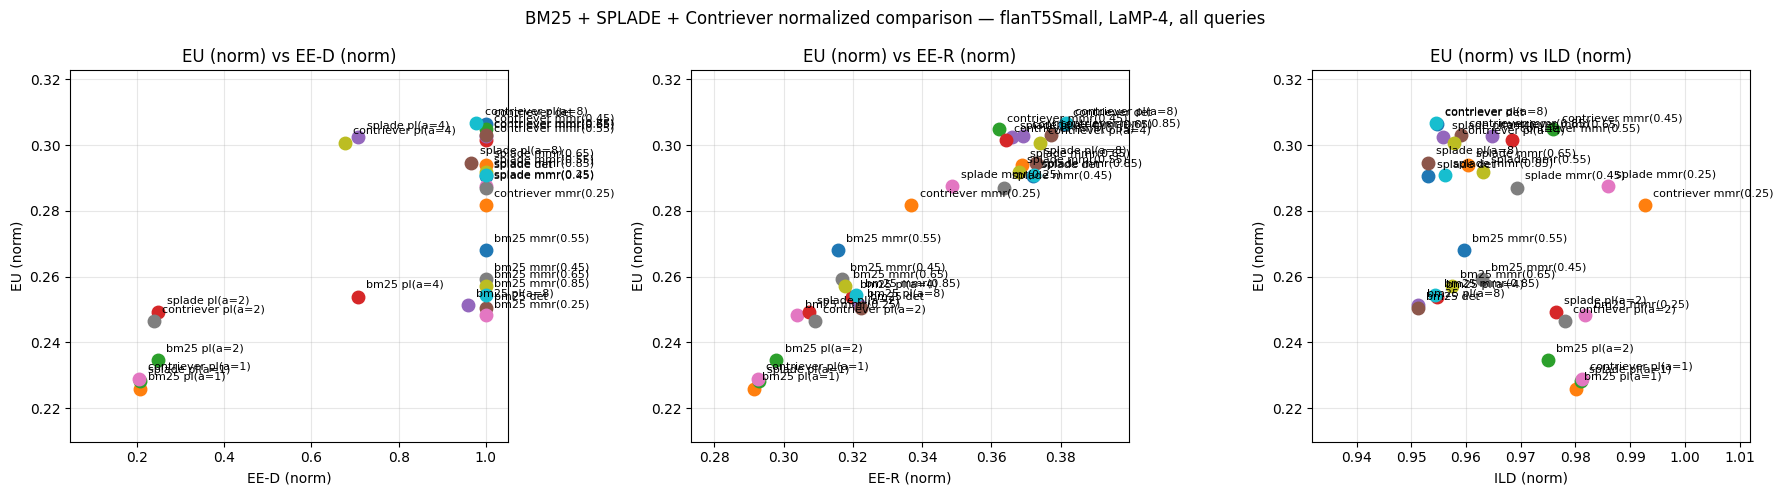

LaMP-4 normalized macro rows (BM25 + SPLADE + Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
29,4,flanT5Small,contriever,pl,8,0.65,0.381603,0.977945,0.306602,0.954565
20,4,flanT5Small,contriever,deterministic,4,0.65,0.381212,1.000000,0.306330,0.954699
22,4,flanT5Small,contriever,mmr,4,0.45,0.362185,1.000000,0.304787,0.975967
25,4,flanT5Small,contriever,mmr,4,0.85,0.377311,1.000000,0.303148,0.959028
24,4,flanT5Small,contriever,mmr,4,0.65,0.369148,1.000000,0.302806,0.964738
14,4,flanT5Small,splade,pl,4,0.65,0.365860,0.707621,0.302490,0.955877
23,4,flanT5Small,contriever,mmr,4,0.55,0.364106,1.000000,0.301607,0.968445
28,4,flanT5Small,contriever,pl,4,0.65,0.373918,0.676759,0.300707,0.957766
15,4,flanT5Small,splade,pl,8,0.65,0.372873,0.966267,0.294655,0.953037
11,4,flanT5Small,splade,mmr,4,0.65,0.368667,1.000000,0.293950,0.960328


  Run-level rows: 30



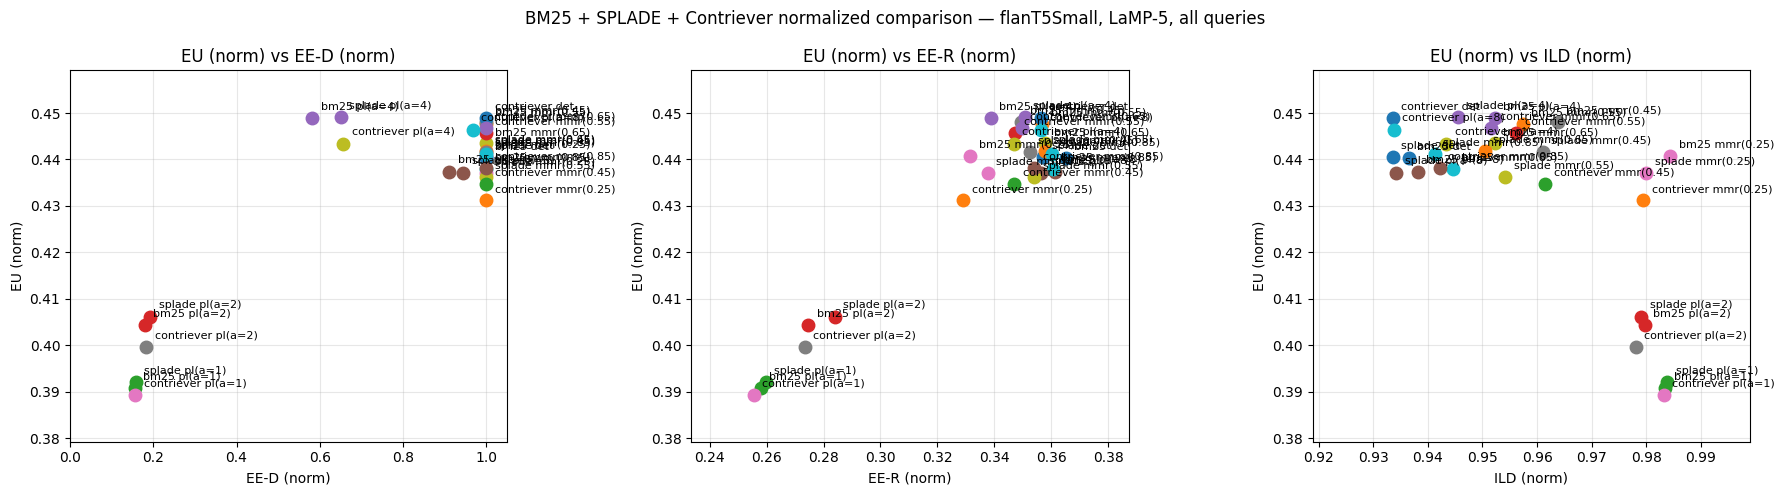

LaMP-5 normalized macro rows (BM25 + SPLADE + Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
14,5,flanT5Small,splade,pl,4,0.65,0.350831,0.650692,0.449185,0.945617
4,5,flanT5Small,bm25,pl,4,0.55,0.338864,0.581695,0.448939,0.952311
20,5,flanT5Small,contriever,deterministic,4,0.65,0.356295,1.000000,0.448882,0.933563
7,5,flanT5Small,bm25,mmr,4,0.45,0.349496,1.000000,0.448039,0.963780
1,5,flanT5Small,bm25,mmr,4,0.55,0.356921,1.000000,0.447683,0.957425
24,5,flanT5Small,contriever,mmr,4,0.65,0.349596,1.000000,0.446873,0.951638
29,5,flanT5Small,contriever,pl,8,0.65,0.356529,0.967119,0.446439,0.933840
23,5,flanT5Small,contriever,mmr,4,0.55,0.347337,1.000000,0.445803,0.956176
8,5,flanT5Small,bm25,mmr,4,0.65,0.357930,1.000000,0.443449,0.952306
28,5,flanT5Small,contriever,pl,4,0.65,0.346786,0.656354,0.443381,0.943388


  Run-level rows: 30



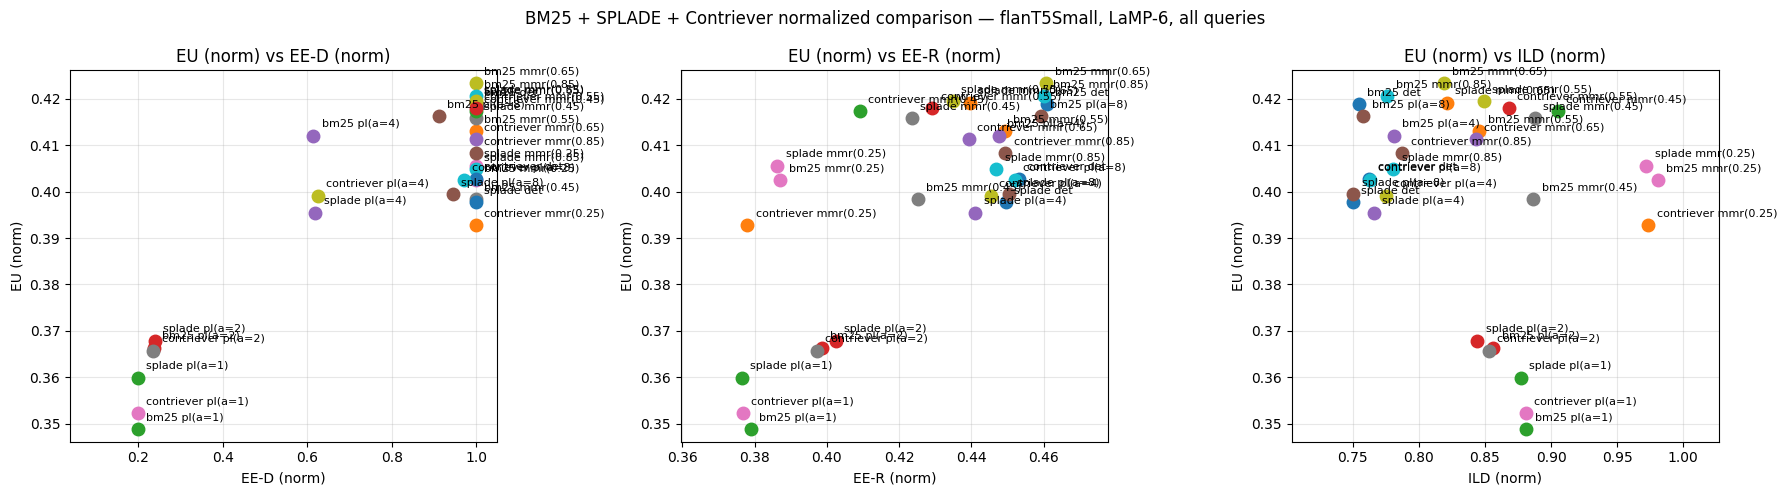

LaMP-6 normalized macro rows (BM25 + SPLADE + Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
8,6,flanT5Small,bm25,mmr,4,0.65,0.460746,1.000000,0.423411,0.819136
9,6,flanT5Small,bm25,mmr,4,0.85,0.460154,1.000000,0.420671,0.776320
18,6,flanT5Small,splade,mmr,4,0.55,0.434846,1.000000,0.419517,0.849343
11,6,flanT5Small,splade,mmr,4,0.65,0.439539,1.000000,0.419153,0.821330
0,6,flanT5Small,bm25,deterministic,4,0.55,0.460877,1.000000,0.418780,0.754820
23,6,flanT5Small,contriever,mmr,4,0.55,0.429167,1.000000,0.418004,0.868088
22,6,flanT5Small,contriever,mmr,4,0.45,0.409211,1.000000,0.417449,0.905030
5,6,flanT5Small,bm25,pl,8,0.55,0.459309,0.911758,0.416243,0.758219
17,6,flanT5Small,splade,mmr,4,0.45,0.423443,1.000000,0.415759,0.887679
1,6,flanT5Small,bm25,mmr,4,0.55,0.449232,1.000000,0.413064,0.845817


  Run-level rows: 30



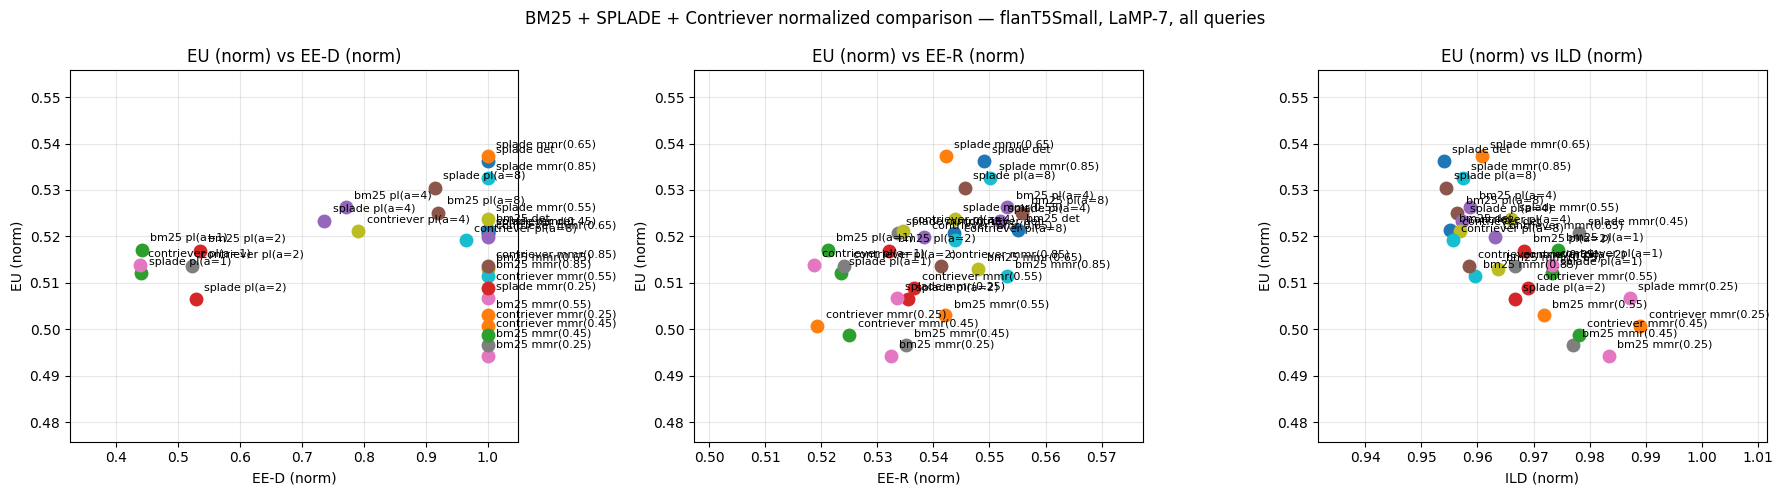

LaMP-7 normalized macro rows (BM25 + SPLADE + Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
11,7,flanT5Small,splade,mmr,4,0.65,0.542237,1.000000,0.537291,0.960755
10,7,flanT5Small,splade,deterministic,4,0.65,0.548995,1.000000,0.536139,0.954052
19,7,flanT5Small,splade,mmr,4,0.85,0.550137,1.000000,0.532538,0.957410
15,7,flanT5Small,splade,pl,8,0.65,0.545612,0.914312,0.530483,0.954328
4,7,flanT5Small,bm25,pl,4,0.55,0.553169,0.770915,0.526234,0.958719
5,7,flanT5Small,bm25,pl,8,0.55,0.555877,0.920384,0.525087,0.956429
18,7,flanT5Small,splade,mmr,4,0.55,0.543836,1.000000,0.523695,0.965972
14,7,flanT5Small,splade,pl,4,0.65,0.551813,0.736208,0.523423,0.957156
0,7,flanT5Small,bm25,deterministic,4,0.55,0.555068,1.000000,0.521314,0.955166
28,7,flanT5Small,contriever,pl,4,0.65,0.534635,0.790970,0.521101,0.956875


  Run-level rows: 30



In [13]:
import os
import glob
import matplotlib.pyplot as plt
from framework import build_query_metric_rows, maybe_to_dataframe


def _ranker_setting_label(row):
    ranker = row.get("ranker", "")
    method = row.get("rerank_method", "")
    if method == "deterministic":
        return f"{ranker} det"
    if method == "mmr":
        return f"{ranker} mmr({row.get('mmr_lambda')})"
    return f"{ranker} pl(a={row.get('pl_alpha')})"


def _normalized_table_for_display(rows):
    df = maybe_to_dataframe(rows)
    if df is None or getattr(df, "empty", True):
        return df

    display_df = df.copy()
    if "lamp_num" in display_df.columns:
        display_df = display_df.sort_values(
            by=["expected_utility_norm", "ranker", "rerank_method", "pl_alpha", "mmr_lambda"],
            ascending=[False, True, True, True, True],
            na_position="last",
        )

    keep_cols = [
        "lamp_num",
        "generator_name",
        "ranker",
        "rerank_method",
        "pl_alpha",
        "mmr_lambda",
        "ee_relevance_norm",
        "ee_disparity_norm",
        "expected_utility_norm",
        "avg_ild_jaccard_norm",
    ]
    return display_df[[c for c in keep_cols if c in display_df.columns]]


def _discover_run_dirs_for_ranker(
    ranker,
    lamp_num,
    generator_name="flanT5Small",
    split_type="user",
    top_k=5,
    seed=42,
    num_queries=None,
):
    runs_root = os.path.join(REPO_ROOT, "experiment_runs")
    nq_token = "nqall" if num_queries is None else f"nq{num_queries}"
    pattern = os.path.join(
        runs_root,
        f"*_lamp{lamp_num}_{split_type}__{generator_name}__{ranker}__*__k{top_k}__{nq_token}__seed{seed}",
    )
    candidates = sorted(glob.glob(pattern))
    keep = []
    for d in candidates:
        name = os.path.basename(d)
        if "__det__" in name or "__mmr_l" in name or "__pl_a" in name:
            keep.append(d)
    return keep


def _find_optional_gold_run_dir(lamp_num, generator_name="flanT5Small", split_type="user", top_k=5, seed=42):
    runs_root = os.path.join(REPO_ROOT, "experiment_runs")
    pattern = os.path.join(
        runs_root,
        f"*_lamp{lamp_num}_{split_type}__{generator_name}__gold__det__k{top_k}__nqall__seed{seed}",
    )
    matches = sorted(glob.glob(pattern))
    return matches[-1] if matches else None


def _safe_div(num, den):
    if num is None or den is None:
        return None
    if den == 0:
        return 1.0
    return num / den


def _normalize_query_rows_global_for_lamp(lamp_num, ranker_run_dirs, include_gold_reference=True):
    all_run_dirs = []
    for dirs in ranker_run_dirs.values():
        all_run_dirs.extend(dirs)

    query_rows = build_query_metric_rows(all_run_dirs)
    if not query_rows:
        return []

    gold_rows = []
    if include_gold_reference:
        gdir = _find_optional_gold_run_dir(lamp_num)
        if gdir is not None:
            gold_rows = build_query_metric_rows([gdir])

    by_qid = {}
    for r in query_rows:
        by_qid.setdefault(r.get("qid"), []).append(r)

    gold_by_qid = {}
    for r in gold_rows:
        gold_by_qid.setdefault(r.get("qid"), []).append(r)

    normalized_rows = []
    is_lower_better_eu = lamp_num == 3
    eu_upper_bound = 4.0

    for qid, rows in by_qid.items():
        ref_rows = rows + gold_by_qid.get(qid, [])

        ee_rel_candidates = [r.get("ee_relevance") for r in ref_rows if r.get("ee_relevance") is not None]
        ee_rel_denom = max(ee_rel_candidates) if ee_rel_candidates else None

        # Paper-aligned EE-D: use ee_disparity already normalized inside expeval (normalize=True).
        ee_disp_denom = 1.0

        ild_candidates = [r.get("avg_ild_jaccard") for r in ref_rows if r.get("avg_ild_jaccard") is not None]
        ild_denom = max(ild_candidates) if ild_candidates else None

        if is_lower_better_eu:
            eu_candidates = []
            for r in ref_rows:
                min_u = r.get("min_utility")
                if min_u is not None:
                    eu_candidates.append(eu_upper_bound - min_u)
            eu_denom = max(eu_candidates) if eu_candidates else None
        else:
            eu_candidates = [r.get("max_utility") for r in ref_rows if r.get("max_utility") is not None]
            eu_denom = max(eu_candidates) if eu_candidates else None

        for r in rows:
            eu_num = r.get("expected_utility")
            if is_lower_better_eu and eu_num is not None:
                eu_num = eu_upper_bound - eu_num

            normalized_rows.append(
                {
                    **r,
                    "ee_relevance_norm": _safe_div(r.get("ee_relevance"), ee_rel_denom),
                    "ee_disparity_norm": _safe_div(r.get("ee_disparity"), ee_disp_denom),
                    "expected_utility_norm": _safe_div(eu_num, eu_denom),
                    "avg_ild_jaccard_norm": _safe_div(r.get("avg_ild_jaccard"), ild_denom),
                }
            )

    return normalized_rows


def _macro_from_normalized_query_rows(norm_query_rows):
    if not norm_query_rows:
        return []

    grouped = {}
    for row in norm_query_rows:
        grouped.setdefault(row["run_dir"], []).append(row)

    out = []
    for run_dir, rows in grouped.items():
        meta = rows[0]

        def _mean(key):
            vals = [r.get(key) for r in rows if r.get(key) is not None]
            return (sum(vals) / len(vals)) if vals else None

        out.append(
            {
                "run_id": meta.get("run_id"),
                "setting_id": meta.get("setting_id"),
                "seed": meta.get("seed"),
                "dataset_type": meta.get("dataset_type"),
                "lamp_num": meta.get("lamp_num"),
                "lamp_split_type": meta.get("lamp_split_type"),
                "generator_name": meta.get("generator_name"),
                "ranker": meta.get("ranker"),
                "rerank_method": meta.get("rerank_method"),
                "pl_alpha": meta.get("pl_alpha"),
                "pl_samples": meta.get("pl_samples"),
                "mmr_lambda": meta.get("mmr_lambda"),
                "top_k": meta.get("top_k"),
                "run_dir": run_dir,
                "n_queries": len(rows),
                "ee_relevance_norm": _mean("ee_relevance_norm"),
                "ee_disparity_norm": _mean("ee_disparity_norm"),
                "expected_utility_norm": _mean("expected_utility_norm"),
                "avg_ild_jaccard_norm": _mean("avg_ild_jaccard_norm"),
            }
        )

    return out


def _zoom_limits(values, hard_min=0.0, hard_max=1.05, pad_ratio=0.2, min_window=0.08):
    if not values:
        return hard_min, hard_max
    vmin = min(values)
    vmax = max(values)
    span = vmax - vmin
    if span < min_window:
        center = (vmin + vmax) / 2.0
        half = min_window / 2.0
        lo = center - half
        hi = center + half
    else:
        pad = span * pad_ratio
        lo = vmin - pad
        hi = vmax + pad
    lo = max(hard_min, lo)
    hi = min(hard_max, hi)
    if lo >= hi:
        lo, hi = hard_min, hard_max
    return lo, hi


def _plot_normalized_lamp(macro_rows, lamp_num):
    pairs = [
        ("ee_disparity_norm", "expected_utility_norm", "EE-D (norm)", "EU (norm)"),
        ("ee_relevance_norm", "expected_utility_norm", "EE-R (norm)", "EU (norm)"),
        ("avg_ild_jaccard_norm", "expected_utility_norm", "ILD (norm)", "EU (norm)"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"BM25 + SPLADE + Contriever normalized comparison — flanT5Small, LaMP-{lamp_num}, all queries",
        fontsize=12,
    )

    for ax, (xk, yk, xl, yl) in zip(axes, pairs):
        xs = []
        ys = []
        for row in macro_rows:
            x = row.get(xk)
            y = row.get(yk)
            if x is None or y is None:
                continue
            xs.append(x)
            ys.append(y)
            ax.plot(x, y, marker="o", linestyle="None", markersize=9)
            ax.annotate(_ranker_setting_label(row), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)

        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.set_title(f"{yl} vs {xl}")
        x_lo, x_hi = _zoom_limits(xs)
        y_lo, y_hi = _zoom_limits(ys)
        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(y_lo, y_hi)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


GLOBAL_NORM_CACHE = {}
for lamp_num in range(1, 8):
    ranker_run_dirs = {
        "bm25": _discover_run_dirs_for_ranker("bm25", lamp_num),
        "splade": _discover_run_dirs_for_ranker("splade", lamp_num),
        "contriever": _discover_run_dirs_for_ranker("contriever", lamp_num),
    }

    if not any(ranker_run_dirs.values()):
        print(f"LaMP-{lamp_num}: skipped (no BM25/SPLADE/Contriever run directories found)")
        continue

    norm_q_rows = _normalize_query_rows_global_for_lamp(lamp_num, ranker_run_dirs, include_gold_reference=True)
    norm_macro_rows = _macro_from_normalized_query_rows(norm_q_rows)

    if not norm_macro_rows:
        print(f"LaMP-{lamp_num}: skipped (no normalized rows available)")
        continue

    GLOBAL_NORM_CACHE[lamp_num] = {
        "query_rows": norm_q_rows,
        "macro_rows": norm_macro_rows,
        "run_dirs_by_ranker": ranker_run_dirs,
    }

    _plot_normalized_lamp(norm_macro_rows, lamp_num)

    print(f"LaMP-{lamp_num} normalized macro rows (BM25 + SPLADE + Contriever):")
    display(_normalized_table_for_display(norm_macro_rows))
    print(f"  Run-level rows: {len(norm_macro_rows)}")
    print()

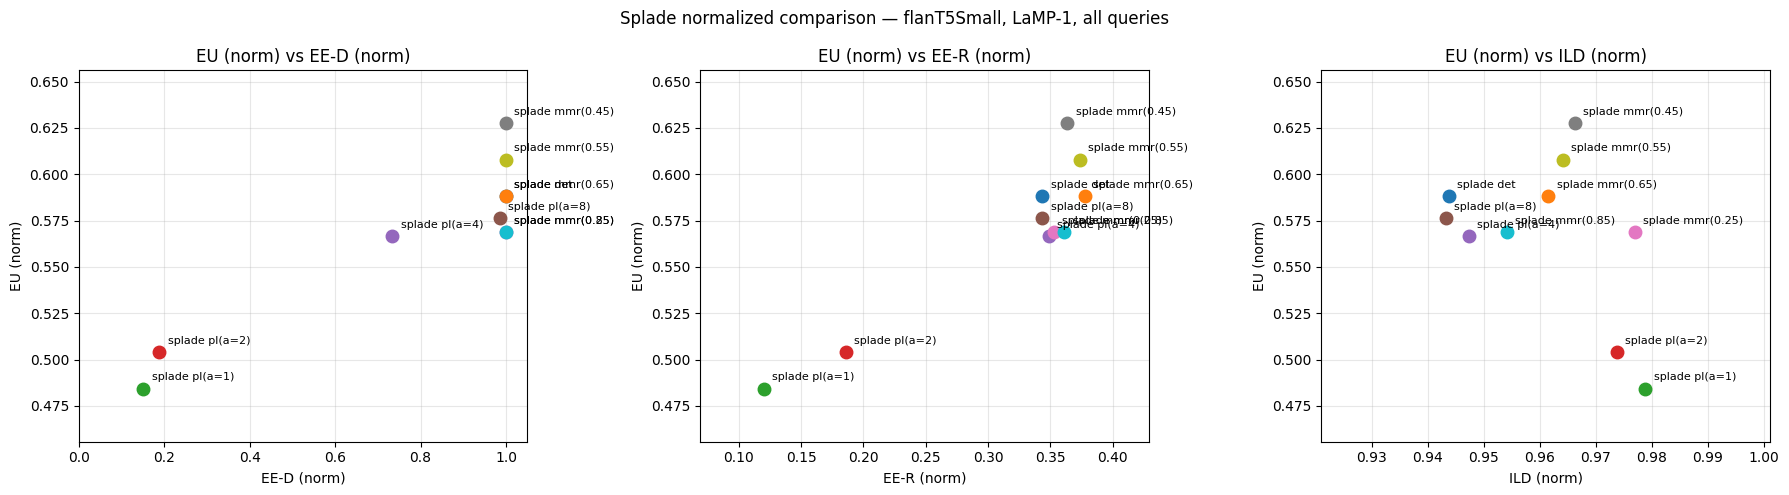

LaMP-1 normalized macro rows (SPLADE):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
7,1,flanT5Small,splade,mmr,4,0.45,0.363725,1.000000,0.627451,0.966285
8,1,flanT5Small,splade,mmr,4,0.55,0.373529,1.000000,0.607843,0.964118
0,1,flanT5Small,splade,deterministic,4,0.65,0.343464,1.000000,0.588235,0.943772
1,1,flanT5Small,splade,mmr,4,0.65,0.377451,1.000000,0.588235,0.961505
5,1,flanT5Small,splade,pl,8,0.65,0.343464,0.985961,0.576471,0.943286
6,1,flanT5Small,splade,mmr,4,0.25,0.352614,1.000000,0.568627,0.976914
9,1,flanT5Small,splade,mmr,4,0.85,0.361111,1.000000,0.568627,0.954125
4,1,flanT5Small,splade,pl,4,0.65,0.348660,0.734275,0.566667,0.947375
3,1,flanT5Small,splade,pl,2,0.65,0.186111,0.188784,0.503922,0.973735
2,1,flanT5Small,splade,pl,1,0.65,0.120359,0.150824,0.484314,0.978804


  Run-level rows: 10



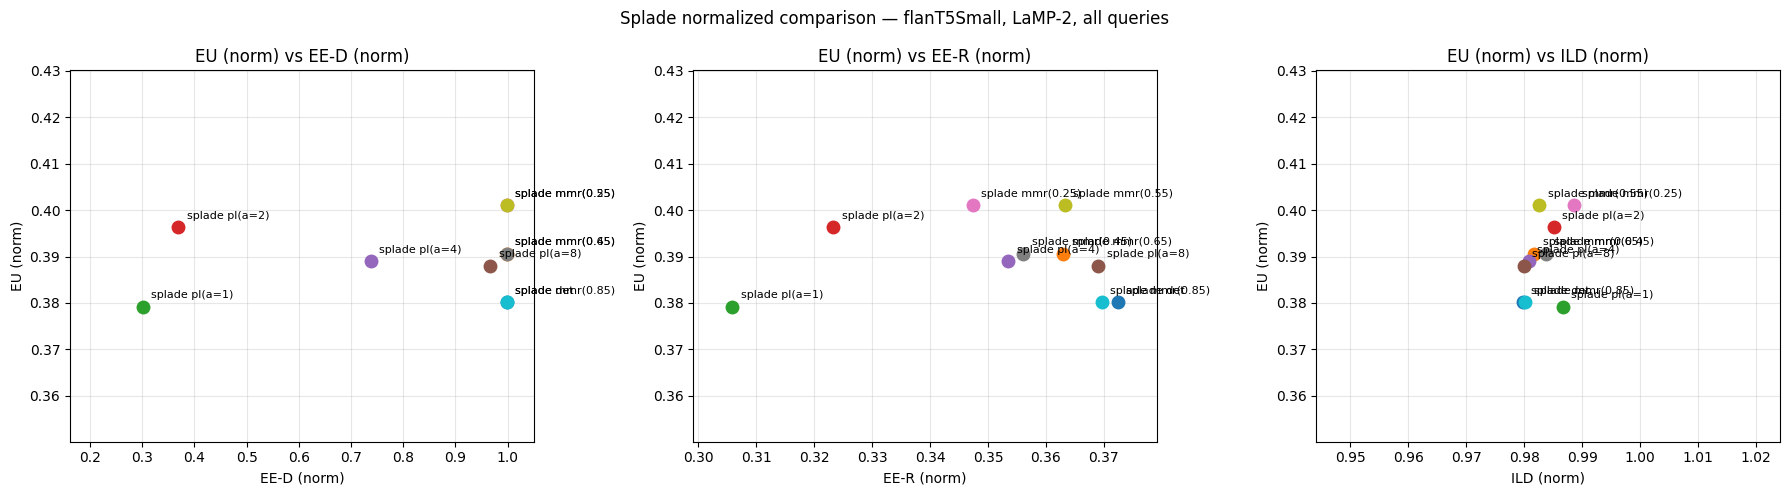

LaMP-2 normalized macro rows (SPLADE):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
6,2,flanT5Small,splade,mmr,4,0.25,0.347396,0.997917,0.401042,0.988514
8,2,flanT5Small,splade,mmr,4,0.55,0.363281,0.997917,0.401042,0.982618
3,2,flanT5Small,splade,pl,2,0.65,0.323299,0.369000,0.396354,0.985157
7,2,flanT5Small,splade,mmr,4,0.45,0.356076,0.997917,0.390625,0.983740
1,2,flanT5Small,splade,mmr,4,0.65,0.363021,0.997917,0.390625,0.981710
4,2,flanT5Small,splade,pl,4,0.65,0.353498,0.737375,0.389063,0.980778
5,2,flanT5Small,splade,pl,8,0.65,0.369019,0.966813,0.388021,0.979886
0,2,flanT5Small,splade,deterministic,4,0.65,0.372396,0.997917,0.380208,0.979730
9,2,flanT5Small,splade,mmr,4,0.85,0.369618,0.997917,0.380208,0.980202
2,2,flanT5Small,splade,pl,1,0.65,0.305885,0.300958,0.379167,0.986630


  Run-level rows: 10



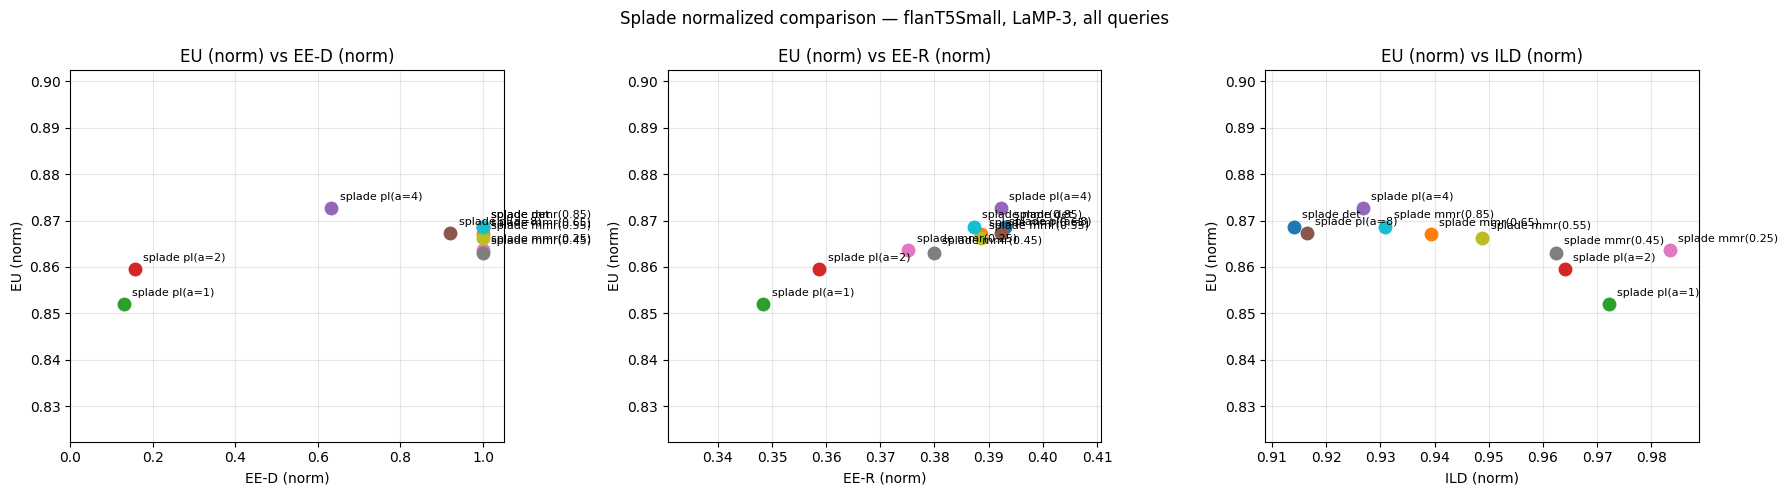

LaMP-3 normalized macro rows (SPLADE):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
4,3,flanT5Small,splade,pl,4,0.65,0.392245,0.632977,0.872669,0.926748
0,3,flanT5Small,splade,deterministic,4,0.65,0.393087,1.000000,0.868703,0.914040
9,3,flanT5Small,splade,mmr,4,0.85,0.387299,1.000000,0.868703,0.930917
5,3,flanT5Small,splade,pl,8,0.65,0.392251,0.920682,0.867337,0.916435
1,3,flanT5Small,splade,mmr,4,0.65,0.388585,1.000000,0.867095,0.939273
8,3,flanT5Small,splade,mmr,4,0.55,0.388585,1.000000,0.866292,0.948801
6,3,flanT5Small,splade,mmr,4,0.25,0.375188,1.000000,0.863612,0.983457
7,3,flanT5Small,splade,mmr,4,0.45,0.379904,1.000000,0.863076,0.962354
3,3,flanT5Small,splade,pl,2,0.65,0.358730,0.157183,0.859486,0.964033
2,3,flanT5Small,splade,pl,1,0.65,0.348430,0.130675,0.852036,0.972131


  Run-level rows: 10



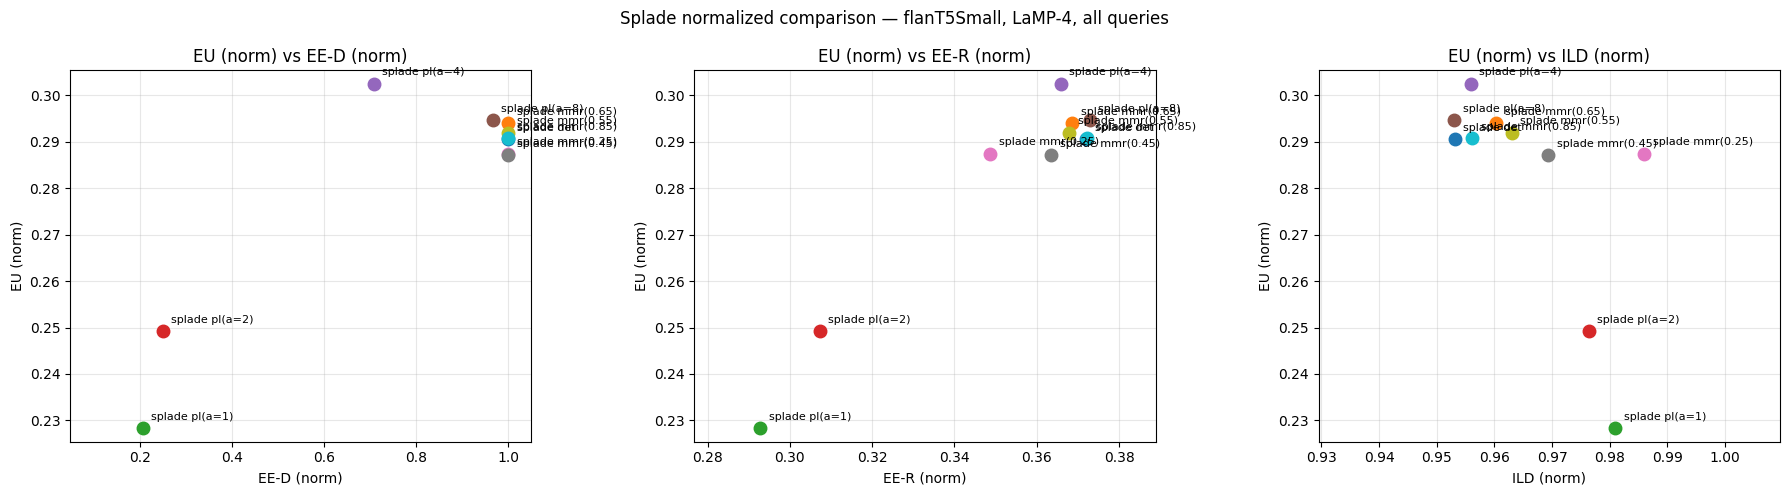

LaMP-4 normalized macro rows (SPLADE):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
4,4,flanT5Small,splade,pl,4,0.65,0.365860,0.707621,0.302490,0.955877
5,4,flanT5Small,splade,pl,8,0.65,0.372873,0.966267,0.294655,0.953037
1,4,flanT5Small,splade,mmr,4,0.65,0.368667,1.000000,0.293950,0.960328
8,4,flanT5Small,splade,mmr,4,0.55,0.367927,1.000000,0.291943,0.963043
9,4,flanT5Small,splade,mmr,4,0.85,0.372249,1.000000,0.290785,0.956186
0,4,flanT5Small,splade,deterministic,4,0.65,0.372009,1.000000,0.290575,0.953103
6,4,flanT5Small,splade,mmr,4,0.25,0.348739,1.000000,0.287452,0.985992
7,4,flanT5Small,splade,mmr,4,0.45,0.363505,1.000000,0.287113,0.969346
3,4,flanT5Small,splade,pl,2,0.65,0.307337,0.248850,0.249174,0.976414
2,4,flanT5Small,splade,pl,1,0.65,0.292803,0.206598,0.228306,0.980966


  Run-level rows: 10



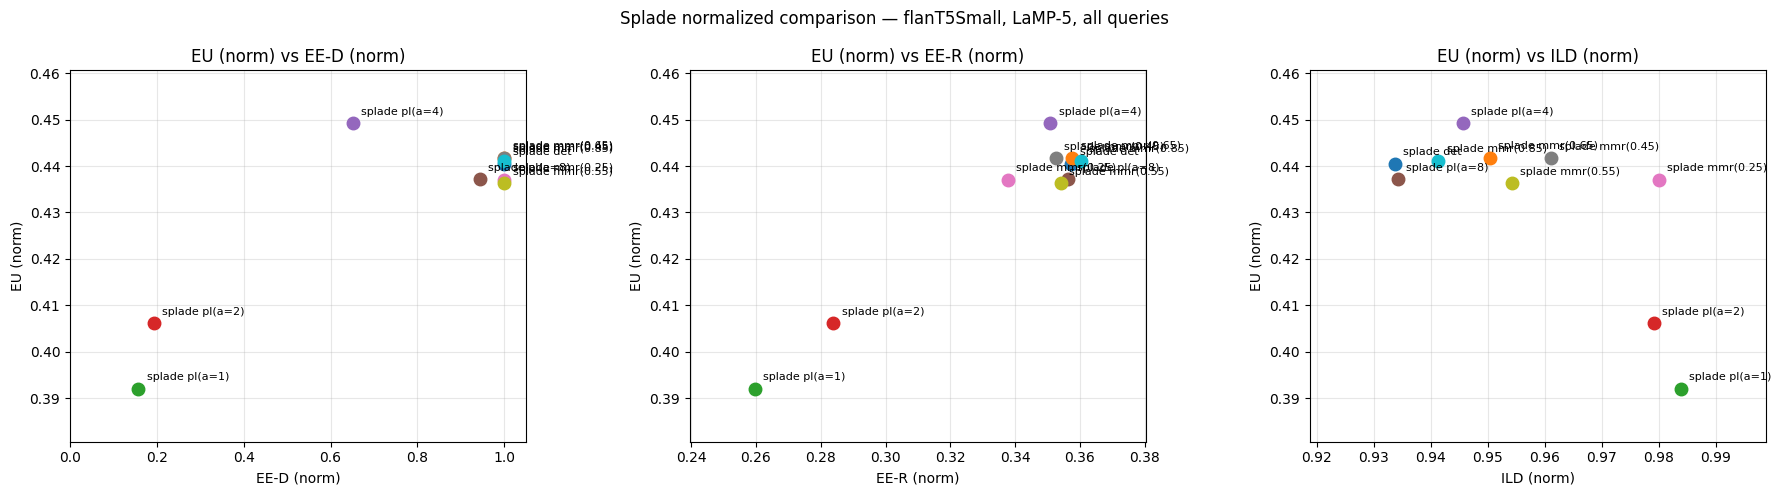

LaMP-5 normalized macro rows (SPLADE):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
4,5,flanT5Small,splade,pl,4,0.65,0.350831,0.650692,0.449185,0.945617
1,5,flanT5Small,splade,mmr,4,0.65,0.357688,1.000000,0.441827,0.950400
7,5,flanT5Small,splade,mmr,4,0.45,0.352603,1.000000,0.441642,0.961091
9,5,flanT5Small,splade,mmr,4,0.85,0.360210,1.000000,0.441131,0.941318
0,5,flanT5Small,splade,deterministic,4,0.65,0.357284,1.000000,0.440518,0.933643
5,5,flanT5Small,splade,pl,8,0.65,0.356414,0.944349,0.437156,0.934254
6,5,flanT5Small,splade,mmr,4,0.25,0.337752,1.000000,0.437038,0.980017
8,5,flanT5Small,splade,mmr,4,0.55,0.354056,1.000000,0.436261,0.954217
3,5,flanT5Small,splade,pl,2,0.65,0.283892,0.192567,0.406138,0.979073
2,5,flanT5Small,splade,pl,1,0.65,0.259734,0.157274,0.392047,0.983863


  Run-level rows: 10



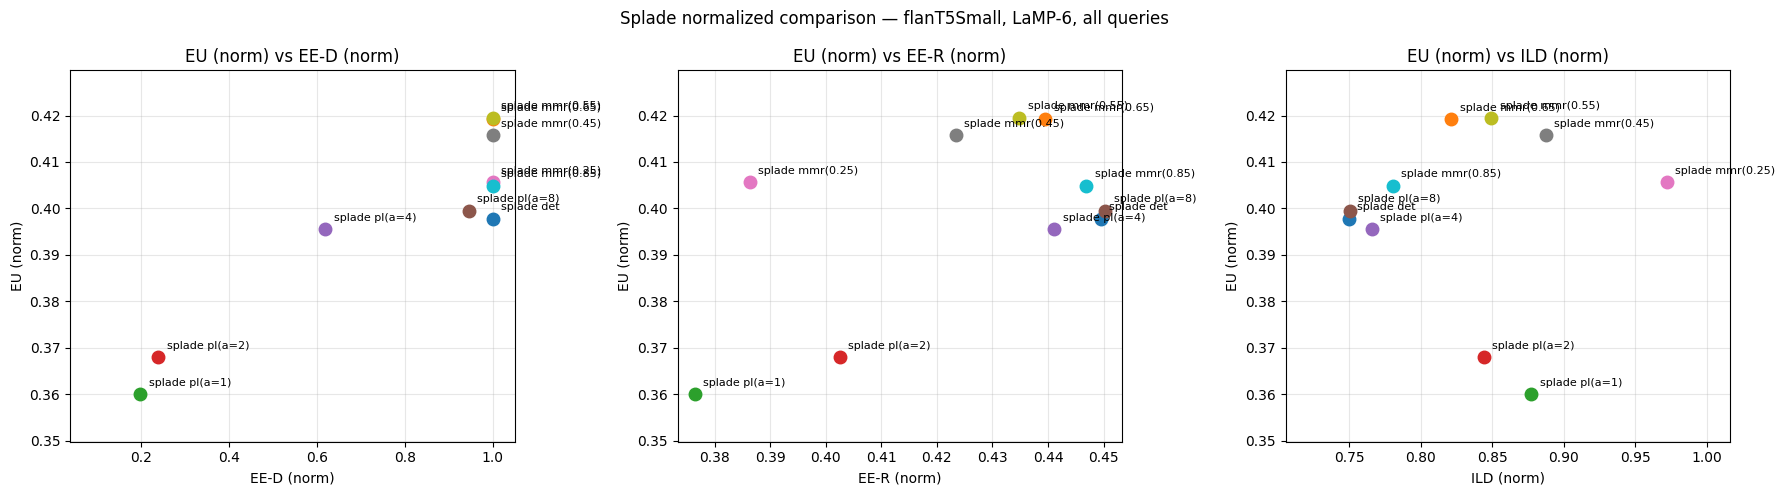

LaMP-6 normalized macro rows (SPLADE):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
8,6,flanT5Small,splade,mmr,4,0.55,0.434846,1.000000,0.419517,0.849343
1,6,flanT5Small,splade,mmr,4,0.65,0.439539,1.000000,0.419153,0.821330
7,6,flanT5Small,splade,mmr,4,0.45,0.423443,1.000000,0.415759,0.887679
6,6,flanT5Small,splade,mmr,4,0.25,0.386338,1.000000,0.405615,0.971972
9,6,flanT5Small,splade,mmr,4,0.85,0.446886,1.000000,0.404881,0.780737
5,6,flanT5Small,splade,pl,8,0.65,0.450296,0.945589,0.399486,0.750630
0,6,flanT5Small,splade,deterministic,4,0.65,0.449539,1.000000,0.397797,0.749939
4,6,flanT5Small,splade,pl,4,0.65,0.441114,0.619195,0.395486,0.765861
3,6,flanT5Small,splade,pl,2,0.65,0.402485,0.239321,0.367923,0.844360
2,6,flanT5Small,splade,pl,1,0.65,0.376478,0.199026,0.359963,0.877417


  Run-level rows: 10



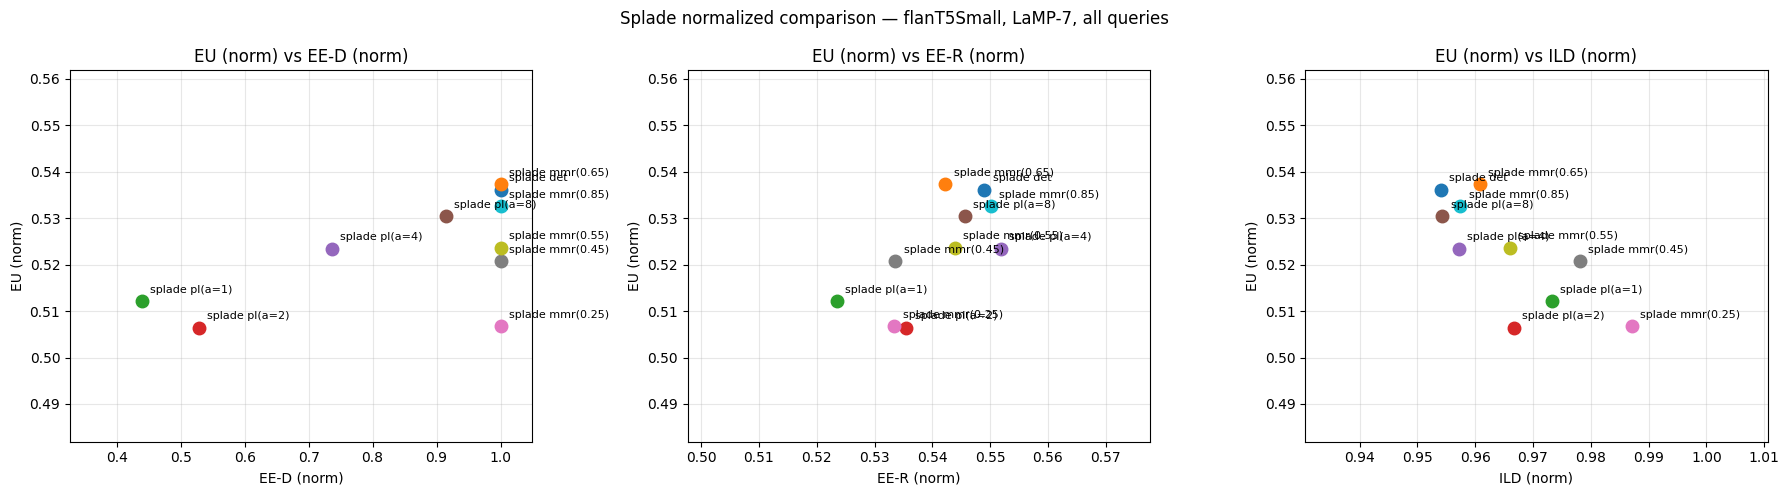

LaMP-7 normalized macro rows (SPLADE):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
1,7,flanT5Small,splade,mmr,4,0.65,0.542237,1.000000,0.537291,0.960755
0,7,flanT5Small,splade,deterministic,4,0.65,0.548995,1.000000,0.536139,0.954052
9,7,flanT5Small,splade,mmr,4,0.85,0.550137,1.000000,0.532538,0.957410
5,7,flanT5Small,splade,pl,8,0.65,0.545612,0.914312,0.530483,0.954328
8,7,flanT5Small,splade,mmr,4,0.55,0.543836,1.000000,0.523695,0.965972
4,7,flanT5Small,splade,pl,4,0.65,0.551813,0.736208,0.523423,0.957156
7,7,flanT5Small,splade,mmr,4,0.45,0.533607,1.000000,0.520754,0.978154
2,7,flanT5Small,splade,pl,1,0.65,0.523507,0.439101,0.512080,0.973211
6,7,flanT5Small,splade,mmr,4,0.25,0.533425,1.000000,0.506746,0.987140
3,7,flanT5Small,splade,pl,2,0.65,0.535479,0.528833,0.506438,0.966717


  Run-level rows: 10



In [14]:
# -----------------------------------------------------------------------------
# Normalized Single-Ranker Graphs — helper + SPLADE view
#
# Uses GLOBAL_NORM_CACHE produced by the normalized graph cell above and
# plots one ranker at a time with the same normalized metrics.
# -----------------------------------------------------------------------------

def _plot_normalized_lamp_for_ranker(macro_rows, lamp_num, ranker_name):
    ranker_rows = [r for r in macro_rows if r.get("ranker") == ranker_name]
    if not ranker_rows:
        print(f"LaMP-{lamp_num}: skipped ({ranker_name} rows not found)")
        return

    pairs = [
        ("ee_disparity_norm", "expected_utility_norm", "EE-D (norm)", "EU (norm)"),
        ("ee_relevance_norm", "expected_utility_norm", "EE-R (norm)", "EU (norm)"),
        ("avg_ild_jaccard_norm", "expected_utility_norm", "ILD (norm)", "EU (norm)"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"{ranker_name.capitalize()} normalized comparison — flanT5Small, LaMP-{lamp_num}, all queries",
        fontsize=12,
    )

    for ax, (xk, yk, xl, yl) in zip(axes, pairs):
        xs = []
        ys = []

        for row in ranker_rows:
            x = row.get(xk)
            y = row.get(yk)
            if x is None or y is None:
                continue

            xs.append(x)
            ys.append(y)
            ax.plot(x, y, marker="o", linestyle="None", markersize=9)
            ax.annotate(_ranker_setting_label(row), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)

        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.set_title(f"{yl} vs {xl}")
        x_lo, x_hi = _zoom_limits(xs)
        y_lo, y_hi = _zoom_limits(ys)
        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(y_lo, y_hi)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


for lamp_num in range(1, 8):
    cache = GLOBAL_NORM_CACHE.get(lamp_num)
    if not cache:
        print(f"LaMP-{lamp_num}: skipped (normalized cache missing)")
        continue

    macro_rows = cache["macro_rows"]
    _plot_normalized_lamp_for_ranker(macro_rows, lamp_num, "splade")

    splade_macro_rows = [r for r in macro_rows if r.get("ranker") == "splade"]
    if splade_macro_rows:
        print(f"LaMP-{lamp_num} normalized macro rows (SPLADE):")
        display(_normalized_table_for_display(splade_macro_rows))
        print(f"  Run-level rows: {len(splade_macro_rows)}")
        print()

## Contriever Normalized Graphs — LaMP 1 through 7

Contriever-only full-sweep normalized plots with compact tables sorted by normalized EU.

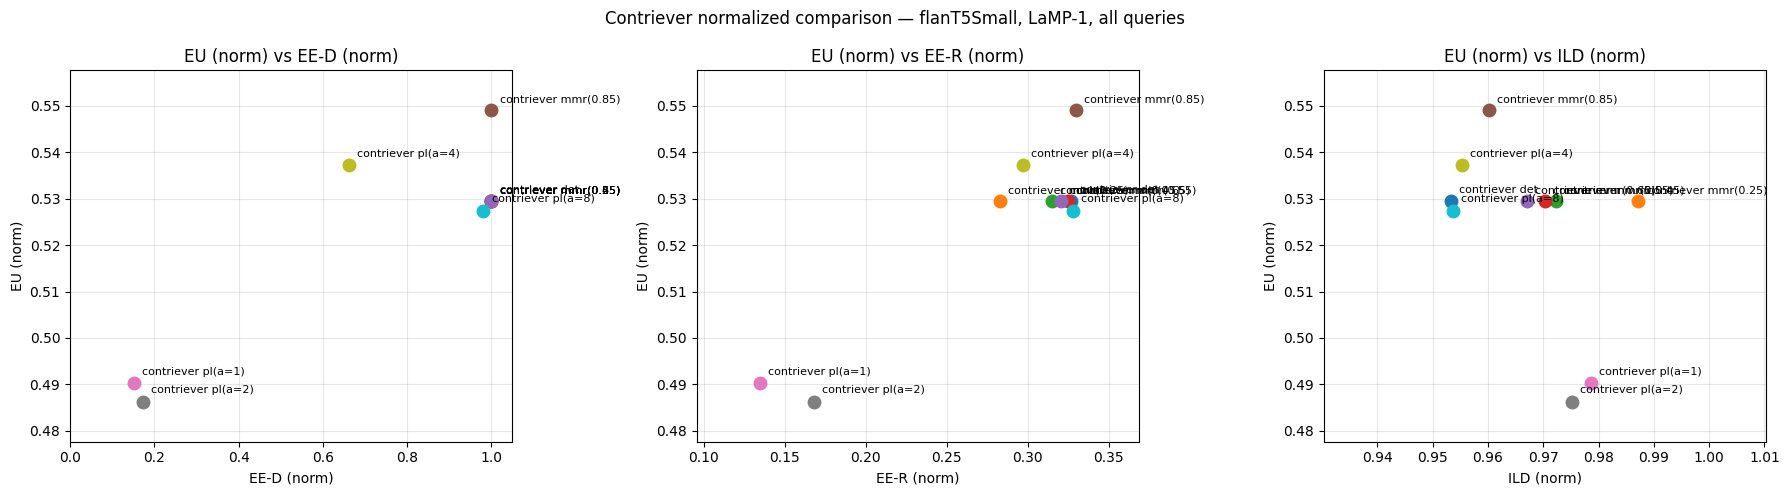

LaMP-1 normalized macro rows (Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
5,1,flanT5Small,contriever,mmr,4,0.85,0.329739,1.000000,0.549020,0.960179
8,1,flanT5Small,contriever,pl,4,0.65,0.296994,0.660941,0.537255,0.955286
0,1,flanT5Small,contriever,deterministic,4,0.65,0.326797,1.000000,0.529412,0.953331
1,1,flanT5Small,contriever,mmr,4,0.25,0.282680,1.000000,0.529412,0.987207
2,1,flanT5Small,contriever,mmr,4,0.45,0.314706,1.000000,0.529412,0.972280
3,1,flanT5Small,contriever,mmr,4,0.55,0.324510,1.000000,0.529412,0.970314
4,1,flanT5Small,contriever,mmr,4,0.65,0.320588,1.000000,0.529412,0.966991
9,1,flanT5Small,contriever,pl,8,0.65,0.327810,0.981020,0.527451,0.953680
6,1,flanT5Small,contriever,pl,1,0.65,0.134608,0.150902,0.490196,0.978628
7,1,flanT5Small,contriever,pl,2,0.65,0.167680,0.172235,0.486275,0.975131


  Run-level rows: 10



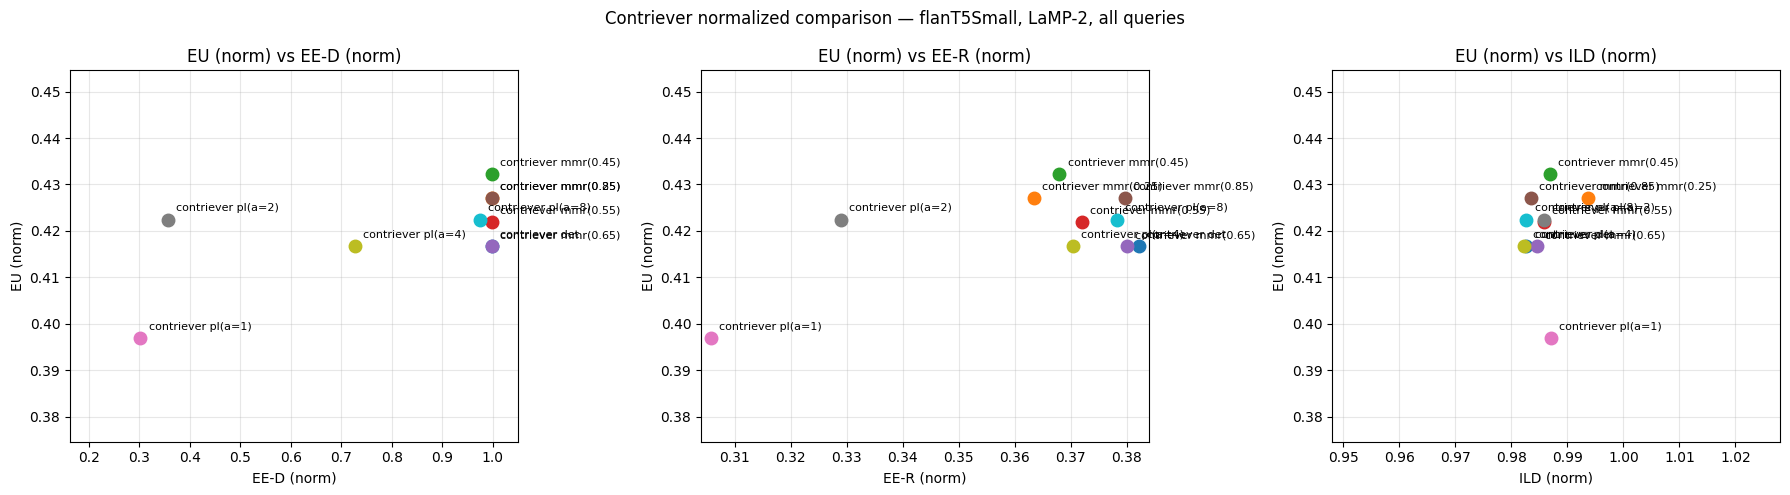

LaMP-2 normalized macro rows (Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
2,2,flanT5Small,contriever,mmr,4,0.45,0.367969,0.997917,0.432292,0.986861
1,2,flanT5Small,contriever,mmr,4,0.25,0.363368,0.997917,0.427083,0.993619
5,2,flanT5Small,contriever,mmr,4,0.85,0.379601,0.997917,0.427083,0.983513
7,2,flanT5Small,contriever,pl,2,0.65,0.328976,0.356833,0.422396,0.985844
9,2,flanT5Small,contriever,pl,8,0.65,0.378203,0.974292,0.422396,0.982687
3,2,flanT5Small,contriever,mmr,4,0.55,0.371962,0.997917,0.421875,0.985784
0,2,flanT5Small,contriever,deterministic,4,0.65,0.382205,0.997917,0.416667,0.982644
4,2,flanT5Small,contriever,mmr,4,0.65,0.379948,0.997917,0.416667,0.984575
8,2,flanT5Small,contriever,pl,4,0.65,0.370347,0.726729,0.416667,0.982327
6,2,flanT5Small,contriever,pl,1,0.65,0.305703,0.301729,0.396875,0.987010


  Run-level rows: 10



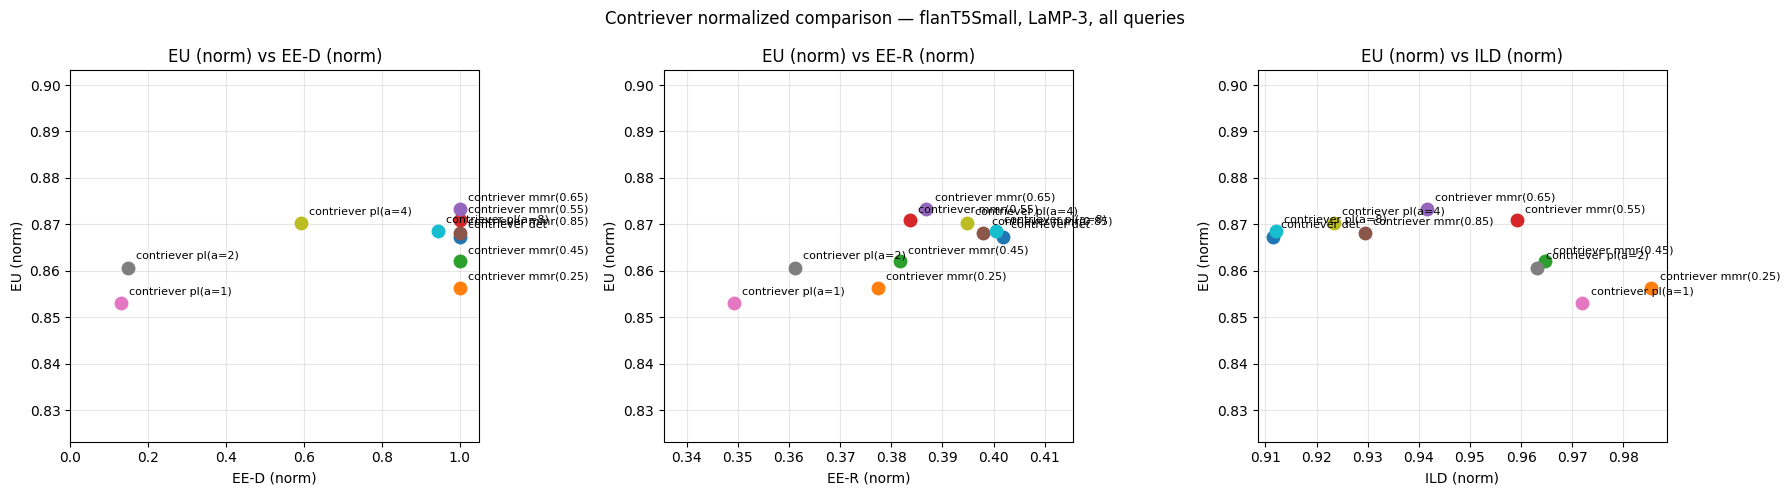

LaMP-3 normalized macro rows (Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
4,3,flanT5Small,contriever,mmr,4,0.65,0.386870,1.000000,0.873258,0.941620
3,3,flanT5Small,contriever,mmr,4,0.55,0.383655,1.000000,0.870847,0.959116
8,3,flanT5Small,contriever,pl,4,0.65,0.394753,0.592424,0.870311,0.923405
9,3,flanT5Small,contriever,pl,8,0.65,0.400461,0.944103,0.868542,0.911982
5,3,flanT5Small,contriever,mmr,4,0.85,0.398017,1.000000,0.868167,0.929382
0,3,flanT5Small,contriever,deterministic,4,0.65,0.401876,1.000000,0.867363,0.911510
2,3,flanT5Small,contriever,mmr,4,0.45,0.381726,1.000000,0.862004,0.964669
7,3,flanT5Small,contriever,pl,2,0.65,0.361174,0.148450,0.860691,0.963179
1,3,flanT5Small,contriever,mmr,4,0.25,0.377438,1.000000,0.856377,0.985424
6,3,flanT5Small,contriever,pl,1,0.65,0.349234,0.130752,0.853081,0.971953


  Run-level rows: 10



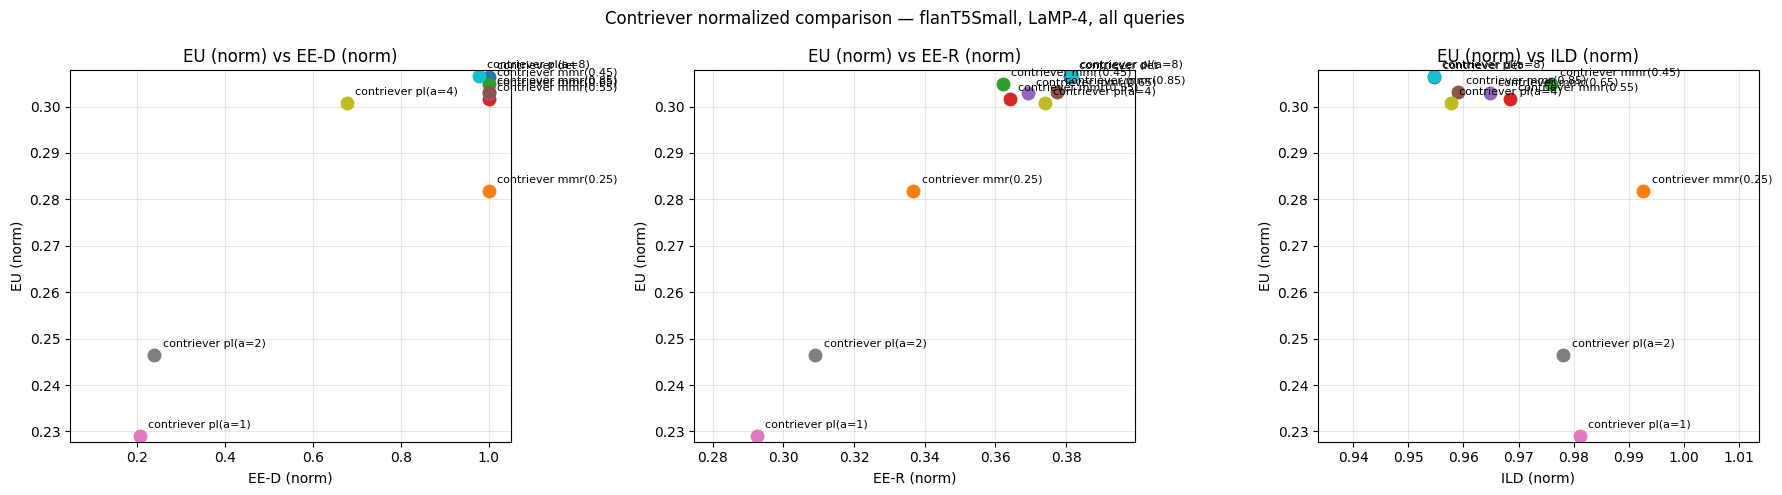

LaMP-4 normalized macro rows (Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
9,4,flanT5Small,contriever,pl,8,0.65,0.381603,0.977945,0.306602,0.954565
0,4,flanT5Small,contriever,deterministic,4,0.65,0.381212,1.000000,0.306330,0.954699
2,4,flanT5Small,contriever,mmr,4,0.45,0.362185,1.000000,0.304787,0.975967
5,4,flanT5Small,contriever,mmr,4,0.85,0.377311,1.000000,0.303148,0.959028
4,4,flanT5Small,contriever,mmr,4,0.65,0.369148,1.000000,0.302806,0.964738
3,4,flanT5Small,contriever,mmr,4,0.55,0.364106,1.000000,0.301607,0.968445
8,4,flanT5Small,contriever,pl,4,0.65,0.373918,0.676759,0.300707,0.957766
1,4,flanT5Small,contriever,mmr,4,0.25,0.336835,1.000000,0.281803,0.992644
7,4,flanT5Small,contriever,pl,2,0.65,0.309030,0.238511,0.246442,0.978118
6,4,flanT5Small,contriever,pl,1,0.65,0.292555,0.205604,0.228982,0.981180


  Run-level rows: 10



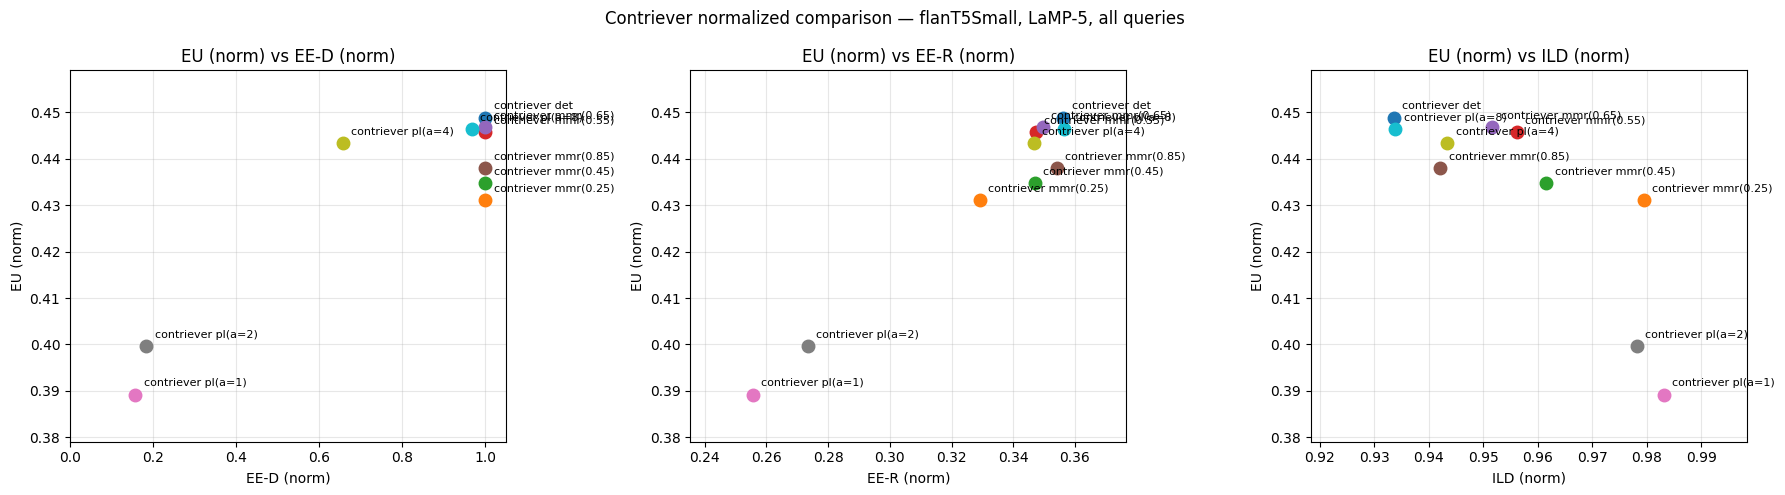

LaMP-5 normalized macro rows (Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
0,5,flanT5Small,contriever,deterministic,4,0.65,0.356295,1.000000,0.448882,0.933563
4,5,flanT5Small,contriever,mmr,4,0.65,0.349596,1.000000,0.446873,0.951638
9,5,flanT5Small,contriever,pl,8,0.65,0.356529,0.967119,0.446439,0.933840
3,5,flanT5Small,contriever,mmr,4,0.55,0.347337,1.000000,0.445803,0.956176
8,5,flanT5Small,contriever,pl,4,0.65,0.346786,0.656354,0.443381,0.943388
5,5,flanT5Small,contriever,mmr,4,0.85,0.354116,1.000000,0.438118,0.942142
2,5,flanT5Small,contriever,mmr,4,0.45,0.346994,1.000000,0.434794,0.961539
1,5,flanT5Small,contriever,mmr,4,0.25,0.329116,1.000000,0.431194,0.979422
7,5,flanT5Small,contriever,pl,2,0.65,0.273356,0.183646,0.399614,0.978122
6,5,flanT5Small,contriever,pl,1,0.65,0.255549,0.157027,0.389221,0.983156


  Run-level rows: 10



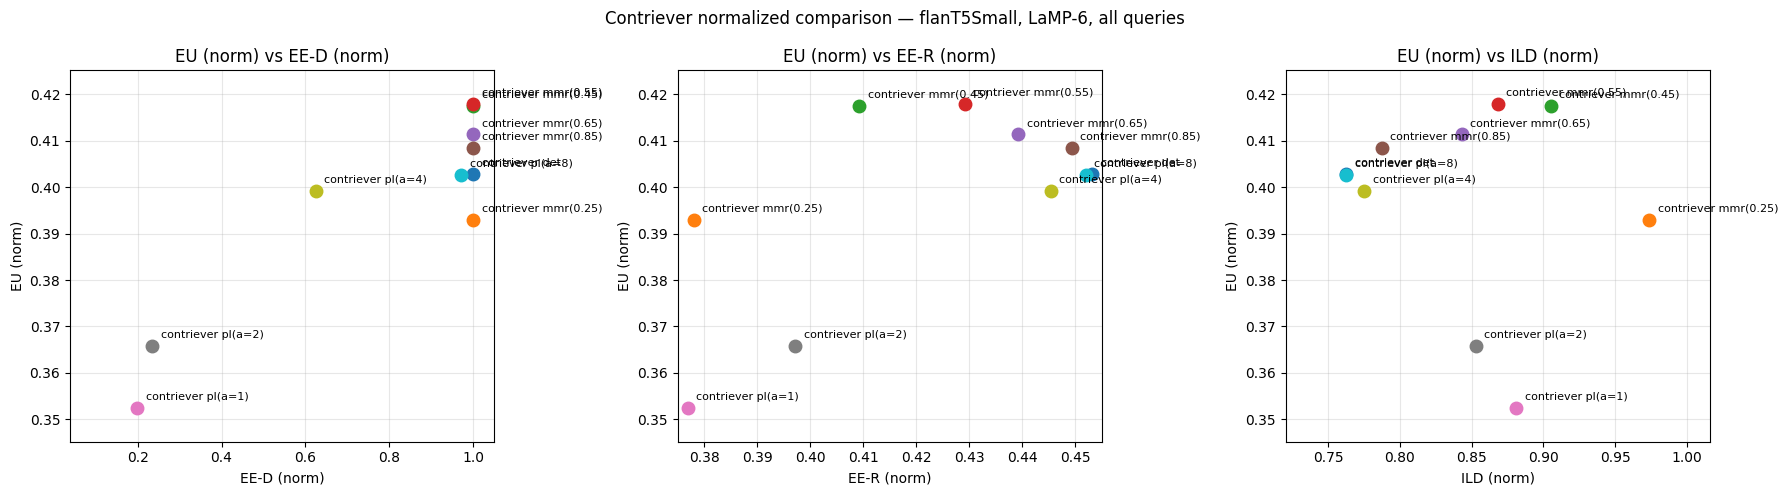

LaMP-6 normalized macro rows (Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
3,6,flanT5Small,contriever,mmr,4,0.55,0.429167,1.000000,0.418004,0.868088
2,6,flanT5Small,contriever,mmr,4,0.45,0.409211,1.000000,0.417449,0.905030
4,6,flanT5Small,contriever,mmr,4,0.65,0.439232,1.000000,0.411362,0.843310
5,6,flanT5Small,contriever,mmr,4,0.85,0.449364,1.000000,0.408378,0.787627
0,6,flanT5Small,contriever,deterministic,4,0.65,0.453158,1.000000,0.402812,0.762670
9,6,flanT5Small,contriever,pl,8,0.65,0.451943,0.971442,0.402566,0.762823
8,6,flanT5Small,contriever,pl,4,0.65,0.445414,0.625211,0.399129,0.775359
1,6,flanT5Small,contriever,mmr,4,0.25,0.378004,1.000000,0.392906,0.973640
7,6,flanT5Small,contriever,pl,2,0.65,0.397167,0.235147,0.365747,0.852767
6,6,flanT5Small,contriever,pl,1,0.65,0.376853,0.199016,0.352328,0.881201


  Run-level rows: 10



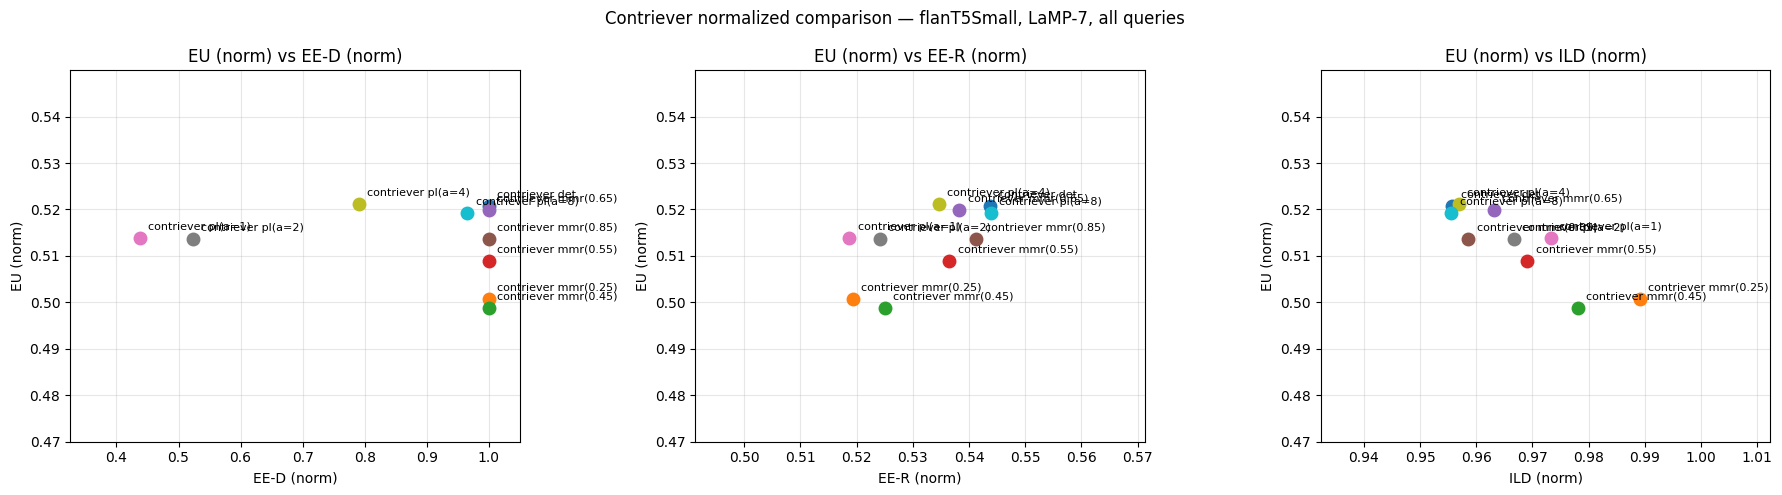

LaMP-7 normalized macro rows (Contriever):


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
8,7,flanT5Small,contriever,pl,4,0.65,0.534635,0.790970,0.521101,0.956875
0,7,flanT5Small,contriever,deterministic,4,0.65,0.543744,1.000000,0.520640,0.955741
4,7,flanT5Small,contriever,mmr,4,0.65,0.538265,1.000000,0.519948,0.963134
9,7,flanT5Small,contriever,pl,8,0.65,0.543913,0.965425,0.519235,0.955559
6,7,flanT5Small,contriever,pl,1,0.65,0.518717,0.437600,0.513771,0.973283
5,7,flanT5Small,contriever,mmr,4,0.85,0.541279,1.000000,0.513563,0.958568
7,7,flanT5Small,contriever,pl,2,0.65,0.524078,0.522795,0.513542,0.966651
3,7,flanT5Small,contriever,mmr,4,0.55,0.536484,1.000000,0.508941,0.969060
1,7,flanT5Small,contriever,mmr,4,0.25,0.519315,1.000000,0.500654,0.989069
2,7,flanT5Small,contriever,mmr,4,0.45,0.525023,1.000000,0.498821,0.978038


  Run-level rows: 10



In [15]:
for lamp_num in range(1, 8):
    cache = GLOBAL_NORM_CACHE.get(lamp_num)
    if not cache:
        print(f"LaMP-{lamp_num}: skipped (normalized cache missing)")
        continue

    macro_rows = cache["macro_rows"]
    _plot_normalized_lamp_for_ranker(macro_rows, lamp_num, "contriever")

    contriever_macro_rows = [r for r in macro_rows if r.get("ranker") == "contriever"]
    if contriever_macro_rows:
        print(f"LaMP-{lamp_num} normalized macro rows (Contriever):")
        display(_normalized_table_for_display(contriever_macro_rows))
        print(f"  Run-level rows: {len(contriever_macro_rows)}")
        print()

## Additional Runs: MMR Sweep + Missing Gold-Det

This cell runs only missing settings for each LaMP task:
- BM25 + MMR with λ in {0.25, 0.45, 0.65, 0.85}
- Gold + deterministic (only if not already present)

Existing runs are detected by `setting_id` and skipped.

In [10]:
import copy
import os
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

MMR_LAMBDAS_EXTRA = [0.25, 0.45, 0.65, 0.85]
GEN = "flanT5Small"
SPLIT = "user"
TOP_K = 5
SEED = 42

all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

print(f"Existing run dirs scanned: {len(all_run_dirs)}")
print(f"Existing setting IDs found: {len(existing_sids)}")


def _base_cfg_for_lamp(lamp_num):
    return RunConfig(
        dataset=DatasetConfig(dataset_type="lamp", lamp_num=lamp_num, lamp_split_type=SPLIT, num_queries=None),
        retrieval=RetrievalConfig(ranker="bm25", top_k=TOP_K),
        rerank=RerankConfig(method="mmr", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=SEED),
        generation=GenerationConfig(generator_name=GEN, multi_gpu=False),
        metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
        checkpoint=CheckpointConfig(flush_every=1, report_every_queries=50),
        resume=False,
        run_id=None,
    )


missing_total = 0
for lamp_num in range(1, 8):
    base = _base_cfg_for_lamp(lamp_num)
    missing_cfgs = []

    # Extra MMR lambdas
    for lam in MMR_LAMBDAS_EXTRA:
        cfg = copy.deepcopy(base)
        cfg.retrieval.ranker = "bm25"
        cfg.rerank.method = "mmr"
        cfg.rerank.mmr_lambda = lam
        cfg.rerank.seed = SEED
        cfg.resume = False
        cfg.run_id = None

        sid = setting_id(cfg)
        if sid not in existing_sids:
            missing_cfgs.append(cfg)

    # Gold deterministic only if missing
    gold_cfg = copy.deepcopy(base)
    gold_cfg.retrieval.ranker = "gold"
    gold_cfg.rerank.method = "deterministic"
    gold_cfg.rerank.seed = SEED
    gold_cfg.resume = False
    gold_cfg.run_id = None

    gold_sid = setting_id(gold_cfg)
    if gold_sid not in existing_sids:
        missing_cfgs.append(gold_cfg)

    if not missing_cfgs:
        print(f"LaMP-{lamp_num}: nothing missing (skipped)")
        continue

    print(f"LaMP-{lamp_num}: running {len(missing_cfgs)} missing setting(s)")
    for cfg in missing_cfgs:
        print(f"  - {setting_id(cfg)}")

    batch = BatchExperimentRunner(
        missing_cfgs,
        batch_id=f"lamp{lamp_num}_mmr_sweep_plus_gold_det",
        reuse_policy="smart",
    )
    out = batch.run_all()
    run_dirs = out.get("run_dirs", [])
    print(f"LaMP-{lamp_num}: complete, produced/confirmed {len(run_dirs)} run dir(s)")

    for cfg in missing_cfgs:
        existing_sids.add(setting_id(cfg))
    missing_total += len(missing_cfgs)

print(f"Done. Total missing settings executed: {missing_total}")

Existing run dirs scanned: 63
Existing setting IDs found: 56
LaMP-1: running 1 missing setting(s)
  - lamp1_user__flanT5Small__gold__det__k5__nqall__seed42
[Batch] Starting run 1/1: lamp1_user__flanT5Small__gold__det__k5__nqall__seed42
Setting: lamp1_user__flanT5Small__gold__det__k5__nqall__seed42
Setting: lamp1_user__flanT5Small__gold__det__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.9864, ILD=0.8867, EU=0.3000
Setting: lamp1_user__flanT5Small__gold__det__k5__nqall__seed42 | Average after 51 queries: EE-D=1.0000, EE-R=0.9856, ILD=0.8865, EU=0.2941
Completed setting: lamp1_user__flanT5Small__gold__det__k5__nqall__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260419_113735_lamp1_user__flanT5Small__gold__det__k5__nqall__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260419_113735_lamp1_user__flanT5Small__gold__det__k5__nqall__seed42/macro_summary.json
[Batch] Summary written to /Users/asimk/Code/Fair-RAG/experiment_run

In [9]:
import os
import json
import pandas as pd

for lamp_num in range(1, 8):
    gold_fp = os.path.join(
        REPO_ROOT,
        "retrieval",
        "retrieval_results",
        "flanT5Small",
        "gold",
        f"{lamp_num}.json",
    )
    if os.path.exists(gold_fp):
        print(f"Gold retrieval exists for LaMP-{lamp_num}: {gold_fp}")
        continue

    rel_fp = os.path.join(
        REPO_ROOT,
        "data",
        "lamp_utility_labels_flanT5Small",
        f"{lamp_num}_relevance_mapping.tsv",
    )
    out_fp = os.path.join(
        REPO_ROOT,
        "data",
        "lamp_utility_labels_flanT5Small",
        f"{lamp_num}_user_dev_outputs.json",
    )

    if not os.path.exists(rel_fp):
        raise FileNotFoundError(f"Missing relevance mapping: {rel_fp}")
    if not os.path.exists(out_fp):
        raise FileNotFoundError(f"Missing utility-label outputs: {out_fp}")

    with open(out_fp, "r", encoding="utf-8") as f:
        out_json = json.load(f)
    final_qids = [entry["id"] for entry in out_json.get("golds", [])]

    rel_df = pd.read_csv(rel_fp, sep="\t", dtype={"qid": str, "pid": str})
    rel_df = rel_df[rel_df["qid"].isin(final_qids)][["qid", "pid", "relevance_label"]]

    rank_dict = {}
    for qid in final_qids:
        qdf = rel_df[rel_df["qid"] == qid].copy()
        qdf = qdf.sort_values(by=["relevance_label", "pid"], ascending=[False, False])
        rank_dict[qid] = [(pid, int(lbl)) for pid, lbl in zip(qdf["pid"].tolist(), qdf["relevance_label"].tolist())]

    os.makedirs(os.path.dirname(gold_fp), exist_ok=True)
    with open(gold_fp, "w", encoding="utf-8") as f:
        json.dump(rank_dict, f)

    print(f"Generated gold retrieval for LaMP-{lamp_num}: {gold_fp}")

print("Gold retrieval precompute check complete.")

Generated gold retrieval for LaMP-1: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/1.json
Gold retrieval exists for LaMP-2: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/2.json
Generated gold retrieval for LaMP-3: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/3.json
Gold retrieval exists for LaMP-4: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/4.json
Generated gold retrieval for LaMP-5: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/5.json
Generated gold retrieval for LaMP-6: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/6.json
Generated gold retrieval for LaMP-7: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/7.json
Gold retrieval precompute check complete.


## SPLADE Feasibility Check (additive, no overwrite)

This block checks whether the same experiment pattern runs with SPLADE:
- Settings: deterministic, MMR(lambda=0.65), PL(alpha in 1,2,4,8)
- Reuse policy: smart (skip existing)
- Uses a smoke-test query budget by default (`SPLADE_NUM_QUERIES = 50`) so we can validate the pipeline quickly.

In [4]:
import copy
import os
import subprocess
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

# SPLADE run with verbose progress (every 40 queries)
SPLADE_LAMPS = [2, 3, 4, 5, 6, 7]
SPLADE_NUM_QUERIES = None
SPLADE_GEN = "flanT5Small"
SPLADE_SPLIT = "user"
SPLADE_TOP_K = 5
SPLADE_SEED = 42
SPLADE_REUSE_POLICY = "smart"
SPLADE_MMR_LAMBDAS = [0.25, 0.45, 0.55, 0.65, 0.85]

SPLADE_OVERRIDES = [{"rerank_method": "deterministic"}]
for lam in SPLADE_MMR_LAMBDAS:
    SPLADE_OVERRIDES.append({"rerank_method": "mmr", "mmr_lambda": lam})
SPLADE_OVERRIDES.extend(
    [
        {"rerank_method": "pl", "pl_alpha": 1, "pl_samples": 10},
        {"rerank_method": "pl", "pl_alpha": 2, "pl_samples": 10},
        {"rerank_method": "pl", "pl_alpha": 4, "pl_samples": 10},
        {"rerank_method": "pl", "pl_alpha": 8, "pl_samples": 10},
    ]
)


def _ensure_splade_retrieval(lamp_num):
    fp = os.path.join(
        REPO_ROOT,
        "retrieval",
        "retrieval_results",
        SPLADE_GEN,
        "splade",
        f"{lamp_num}.json",
    )
    if os.path.exists(fp):
        return fp, "exists"

    cmd = [
        "python",
        "retrieval/rank_profiles.py",
        "--ranker",
        "splade",
        "--generator_name",
        SPLADE_GEN,
        "--lamp_num",
        str(lamp_num),
    ]

    try:
        subprocess.run(cmd, cwd=REPO_ROOT, check=True)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            f"SPLADE retrieval generation failed for LaMP-{lamp_num}."
        ) from exc

    return fp, "generated"


all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

print(
    f"SPLADE run stage: lamps={SPLADE_LAMPS}, num_queries={SPLADE_NUM_QUERIES}, "
    f"reuse_policy={SPLADE_REUSE_POLICY}, verbose=True (progress every 40 queries)"
)
print(f"MMR lambdas: {SPLADE_MMR_LAMBDAS}")
print(f"Existing setting IDs loaded: {len(existing_sids)}")
print()

for lamp_num in SPLADE_LAMPS:
    fp, retrieval_status = _ensure_splade_retrieval(lamp_num)

    base = RunConfig(
        dataset=DatasetConfig(
            dataset_type="lamp",
            lamp_num=lamp_num,
            lamp_split_type=SPLADE_SPLIT,
            num_queries=SPLADE_NUM_QUERIES,
        ),
        retrieval=RetrievalConfig(ranker="splade", top_k=SPLADE_TOP_K),
        rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.65, seed=SPLADE_SEED),
        generation=GenerationConfig(generator_name=SPLADE_GEN, multi_gpu=False),
        metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
        checkpoint=CheckpointConfig(flush_every=1, report_every_queries=40),
        resume=False,
        run_id=None,
    )

    cfgs = []
    for ov in SPLADE_OVERRIDES:
        cfg = copy.deepcopy(base)
        cfg.rerank.method = ov["rerank_method"]
        if "mmr_lambda" in ov:
            cfg.rerank.mmr_lambda = ov["mmr_lambda"]
        if "pl_alpha" in ov:
            cfg.rerank.pl_alpha = ov["pl_alpha"]
        if "pl_samples" in ov:
            cfg.rerank.pl_samples = ov["pl_samples"]
        sid = setting_id(cfg)
        if sid not in existing_sids:
            cfgs.append(cfg)

    if not cfgs:
        print(f"LaMP-{lamp_num}: retrieval={retrieval_status}, settings=0 (all already present)")
        continue

    print(f"LaMP-{lamp_num}: retrieval={retrieval_status}, running {len(cfgs)} missing setting(s)")
    for cfg in cfgs:
        print(f"  - {setting_id(cfg)}")
    print()

    batch = BatchExperimentRunner(
        cfgs,
        batch_id=f"lamp{lamp_num}_splade_allq_mmr_sweep_pl",
        reuse_policy=SPLADE_REUSE_POLICY,
    )
    out = batch.run_all()
    run_dirs = out.get("run_dirs", [])

    for cfg in cfgs:
        existing_sids.add(setting_id(cfg))

    print(f"LaMP-{lamp_num}: complete, produced {len(run_dirs)} run dir(s)")
    print("-" * 80)
    print()

print("=" * 80)
print("SPLADE run stage complete.")
print("=" * 80)

SPLADE run stage: lamps=[2, 3, 4, 5, 6, 7], num_queries=None, reuse_policy=smart, verbose=True (progress every 40 queries)
MMR lambdas: [0.25, 0.45, 0.55, 0.65, 0.85]
Existing setting IDs loaded: 128

LaMP-2: retrieval=exists, running 4 missing setting(s)
  - lamp2_user__flanT5Small__splade__mmr_l025__k5__nqall__seed42
  - lamp2_user__flanT5Small__splade__mmr_l045__k5__nqall__seed42
  - lamp2_user__flanT5Small__splade__mmr_l055__k5__nqall__seed42
  - lamp2_user__flanT5Small__splade__mmr_l085__k5__nqall__seed42

[Batch] Starting run 1/4: lamp2_user__flanT5Small__splade__mmr_l025__k5__nqall__seed42
Setting: lamp2_user__flanT5Small__splade__mmr_l025__k5__nqall__seed42
Setting: lamp2_user__flanT5Small__splade__mmr_l025__k5__nqall__seed42 | Average after 40 queries: EE-D=1.0000, EE-R=0.2892, ILD=0.9282, EU=0.0750
Setting: lamp2_user__flanT5Small__splade__mmr_l025__k5__nqall__seed42 | Average after 80 queries: EE-D=1.0000, EE-R=0.2807, ILD=0.9283, EU=0.1125
Setting: lamp2_user__flanT5Small__

## Contriever Full Sweep (LaMP 1-7)

Runs only missing Contriever settings for each LaMP task:
- deterministic
- MMR with lambda in {0.25, 0.45, 0.55, 0.65, 0.85}
- PL with alpha in {1, 2, 4, 8}

Uses smart reuse via setting ID checks so completed settings are skipped.

In [ ]:
import copy
import os
import subprocess
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

CONTRIEVER_LAMPS = [1, 2, 3, 4, 5, 6, 7]
CONTRIEVER_NUM_QUERIES = None
CONTRIEVER_GEN = "flanT5Small"
CONTRIEVER_SPLIT = "user"
CONTRIEVER_TOP_K = 5
CONTRIEVER_SEED = 42
CONTRIEVER_REUSE_POLICY = "smart"
CONTRIEVER_MMR_LAMBDAS = [0.25, 0.45, 0.55, 0.65, 0.85]

CONTRIEVER_OVERRIDES = [{"rerank_method": "deterministic"}]
for lam in CONTRIEVER_MMR_LAMBDAS:
    CONTRIEVER_OVERRIDES.append({"rerank_method": "mmr", "mmr_lambda": lam})
CONTRIEVER_OVERRIDES.extend(
    [
        {"rerank_method": "pl", "pl_alpha": 1, "pl_samples": 10},
        {"rerank_method": "pl", "pl_alpha": 2, "pl_samples": 10},
        {"rerank_method": "pl", "pl_alpha": 4, "pl_samples": 10},
        {"rerank_method": "pl", "pl_alpha": 8, "pl_samples": 10},
    ]
)


def _ensure_contriever_retrieval(lamp_num):
    fp = os.path.join(
        REPO_ROOT,
        "retrieval",
        "retrieval_results",
        CONTRIEVER_GEN,
        "contriever",
        f"{lamp_num}.json",
    )
    if os.path.exists(fp):
        return fp, "exists"

    cmd = [
        "python",
        "retrieval/rank_profiles.py",
        "--ranker",
        "contriever",
        "--generator_name",
        CONTRIEVER_GEN,
        "--lamp_num",
        str(lamp_num),
    ]

    try:
        subprocess.run(cmd, cwd=REPO_ROOT, check=True)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            f"Contriever retrieval generation failed for LaMP-{lamp_num}."
        ) from exc

    return fp, "generated"


all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

print(
    f"Contriever run stage: lamps={CONTRIEVER_LAMPS}, num_queries={CONTRIEVER_NUM_QUERIES}, "
    f"reuse_policy={CONTRIEVER_REUSE_POLICY}, progress every 40 queries"
)
print(f"MMR lambdas: {CONTRIEVER_MMR_LAMBDAS}")
print(f"Existing setting IDs loaded: {len(existing_sids)}")
print()

for lamp_num in CONTRIEVER_LAMPS:
    fp, retrieval_status = _ensure_contriever_retrieval(lamp_num)

    base = RunConfig(
        dataset=DatasetConfig(
            dataset_type="lamp",
            lamp_num=lamp_num,
            lamp_split_type=CONTRIEVER_SPLIT,
            num_queries=CONTRIEVER_NUM_QUERIES,
        ),
        retrieval=RetrievalConfig(ranker="contriever", top_k=CONTRIEVER_TOP_K),
        rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.65, seed=CONTRIEVER_SEED),
        generation=GenerationConfig(generator_name=CONTRIEVER_GEN, multi_gpu=False),
        metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
        checkpoint=CheckpointConfig(flush_every=1, report_every_queries=40),
        resume=False,
        run_id=None,
    )

    cfgs = []
    for ov in CONTRIEVER_OVERRIDES:
        cfg = copy.deepcopy(base)
        cfg.rerank.method = ov["rerank_method"]
        if "mmr_lambda" in ov:
            cfg.rerank.mmr_lambda = ov["mmr_lambda"]
        if "pl_alpha" in ov:
            cfg.rerank.pl_alpha = ov["pl_alpha"]
        if "pl_samples" in ov:
            cfg.rerank.pl_samples = ov["pl_samples"]
        sid = setting_id(cfg)
        if sid not in existing_sids:
            cfgs.append(cfg)

    if not cfgs:
        print(f"LaMP-{lamp_num}: retrieval={retrieval_status}, settings=0 (all already present)")
        continue

    print(f"LaMP-{lamp_num}: retrieval={retrieval_status}, running {len(cfgs)} missing setting(s)")
    for cfg in cfgs:
        print(f"  - {setting_id(cfg)}")
    print()

    batch = BatchExperimentRunner(
        cfgs,
        batch_id=f"lamp{lamp_num}_contriever_allq_mmr_sweep_pl",
        reuse_policy=CONTRIEVER_REUSE_POLICY,
    )
    out = batch.run_all()
    run_dirs = out.get("run_dirs", [])

    for cfg in cfgs:
        existing_sids.add(setting_id(cfg))

    print(f"LaMP-{lamp_num}: complete, produced {len(run_dirs)} run dir(s)")
    print("-" * 80)
    print()

print("=" * 80)
print("Contriever run stage complete.")
print("=" * 80)

Contriever run stage: lamps=[1, 2, 3, 4, 5, 6, 7], num_queries=None, reuse_policy=smart, progress every 40 queries
MMR lambdas: [0.25, 0.45, 0.55, 0.65, 0.85]
Existing setting IDs loaded: 195

LaMP-1: retrieval=exists, settings=0 (all already present)
LaMP-2: retrieval=exists, settings=0 (all already present)
LaMP-3: retrieval=exists, settings=0 (all already present)
LaMP-4: retrieval=exists, running 1 missing setting(s)
  - lamp4_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42

[Batch] Starting run 1/1: lamp4_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42
Setting: lamp4_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 7244.90it/s]


Setting: lamp4_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42 | Average after 40 queries: EE-D=0.9824, EE-R=0.2890, ILD=0.9390, EU=0.0508
Setting: lamp4_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42 | Average after 80 queries: EE-D=0.9824, EE-R=0.3220, ILD=0.9263, EU=0.0581
Setting: lamp4_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42 | Average after 120 queries: EE-D=0.9769, EE-R=0.3936, ILD=0.9089, EU=0.0681
Setting: lamp4_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42 | Average after 160 queries: EE-D=0.9775, EE-R=0.3995, ILD=0.8850, EU=0.0703
Setting: lamp4_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42 | Average after 200 queries: EE-D=0.9749, EE-R=0.3997, ILD=0.8768, EU=0.0744
Setting: lamp4_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42 | Average after 240 queries: EE-D=0.9758, EE-R=0.3902, ILD=0.8792, EU=0.0705
Setting: lamp4_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42 | Average after

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 53377.66it/s]
BertModel LOAD REPORT from: facebook/contriever
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 826/826 [57:37<00:00,  4.19s/it]  


LaMP-5: retrieval=generated, running 10 missing setting(s)
  - lamp5_user__flanT5Small__contriever__det__k5__nqall__seed42
  - lamp5_user__flanT5Small__contriever__mmr_l025__k5__nqall__seed42
  - lamp5_user__flanT5Small__contriever__mmr_l045__k5__nqall__seed42
  - lamp5_user__flanT5Small__contriever__mmr_l055__k5__nqall__seed42
  - lamp5_user__flanT5Small__contriever__mmr_l065__k5__nqall__seed42
  - lamp5_user__flanT5Small__contriever__mmr_l085__k5__nqall__seed42
  - lamp5_user__flanT5Small__contriever__pl_a1_s10__k5__nqall__seed42
  - lamp5_user__flanT5Small__contriever__pl_a2_s10__k5__nqall__seed42
  - lamp5_user__flanT5Small__contriever__pl_a4_s10__k5__nqall__seed42
  - lamp5_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42

[Batch] Starting run 1/10: lamp5_user__flanT5Small__contriever__det__k5__nqall__seed42
Setting: lamp5_user__flanT5Small__contriever__det__k5__nqall__seed42
Setting: lamp5_user__flanT5Small__contriever__det__k5__nqall__seed42 | Average after 40 queries

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 63496.88it/s]
BertModel LOAD REPORT from: facebook/contriever
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 760/760 [1:03:46<00:00,  5.03s/it]


LaMP-6: retrieval=generated, running 10 missing setting(s)
  - lamp6_user__flanT5Small__contriever__det__k5__nqall__seed42
  - lamp6_user__flanT5Small__contriever__mmr_l025__k5__nqall__seed42
  - lamp6_user__flanT5Small__contriever__mmr_l045__k5__nqall__seed42
  - lamp6_user__flanT5Small__contriever__mmr_l055__k5__nqall__seed42
  - lamp6_user__flanT5Small__contriever__mmr_l065__k5__nqall__seed42
  - lamp6_user__flanT5Small__contriever__mmr_l085__k5__nqall__seed42
  - lamp6_user__flanT5Small__contriever__pl_a1_s10__k5__nqall__seed42
  - lamp6_user__flanT5Small__contriever__pl_a2_s10__k5__nqall__seed42
  - lamp6_user__flanT5Small__contriever__pl_a4_s10__k5__nqall__seed42
  - lamp6_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42

[Batch] Starting run 1/10: lamp6_user__flanT5Small__contriever__det__k5__nqall__seed42
Setting: lamp6_user__flanT5Small__contriever__det__k5__nqall__seed42
Setting: lamp6_user__flanT5Small__contriever__det__k5__nqall__seed42 | Average after 40 queries

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 43506.20it/s]
BertModel LOAD REPORT from: facebook/contriever
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 365/365 [00:28<00:00, 12.95it/s]


LaMP-7: retrieval=generated, running 10 missing setting(s)
  - lamp7_user__flanT5Small__contriever__det__k5__nqall__seed42
  - lamp7_user__flanT5Small__contriever__mmr_l025__k5__nqall__seed42
  - lamp7_user__flanT5Small__contriever__mmr_l045__k5__nqall__seed42
  - lamp7_user__flanT5Small__contriever__mmr_l055__k5__nqall__seed42
  - lamp7_user__flanT5Small__contriever__mmr_l065__k5__nqall__seed42
  - lamp7_user__flanT5Small__contriever__mmr_l085__k5__nqall__seed42
  - lamp7_user__flanT5Small__contriever__pl_a1_s10__k5__nqall__seed42
  - lamp7_user__flanT5Small__contriever__pl_a2_s10__k5__nqall__seed42
  - lamp7_user__flanT5Small__contriever__pl_a4_s10__k5__nqall__seed42
  - lamp7_user__flanT5Small__contriever__pl_a8_s10__k5__nqall__seed42

[Batch] Starting run 1/10: lamp7_user__flanT5Small__contriever__det__k5__nqall__seed42
Setting: lamp7_user__flanT5Small__contriever__det__k5__nqall__seed42
Setting: lamp7_user__flanT5Small__contriever__det__k5__nqall__seed42 | Average after 40 queries

: 

In [12]:
import math
import pandas as pd

DISPARITY_BINS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
DISPARITY_LABELS = ["[0.0, 0.2)", "[0.2, 0.4)", "[0.4, 0.6)", "[0.6, 0.8)", "[0.8, 1.0)"]
RANKERS = ["bm25", "splade", "contriever"]
BASELINES = [("det", "det"), ("mmr065", "mmr(0.65)")]


def _fmt_signed(v):
    if v is None:
        return "NA"
    if abs(v) < 5e-4:
        return "0.00"
    return f"{v:+.2f}"


def _is_ranker_det(row, ranker_name):
    return row.get("ranker") == ranker_name and row.get("rerank_method") == "deterministic"


def _is_ranker_mmr(row, ranker_name, target_lambda=0.65, eps=1e-9):
    if row.get("ranker") != ranker_name or row.get("rerank_method") != "mmr":
        return False
    lam = row.get("mmr_lambda")
    return lam is not None and abs(float(lam) - float(target_lambda)) <= eps


def _is_ranker_pl(row, ranker_name):
    return row.get("ranker") == ranker_name and row.get("rerank_method") == "pl"


def _build_unified_row(lamp_num, ranker_name, baseline_mode, baseline_label):
    base_row = {
        "LaMP": lamp_num,
        "Baseline": baseline_label,
        "Ranker": ranker_name,
        "Model (baseline utility)": "NA",
        "PL runs": 0,
        "Status": "ok",
    }

    for label in DISPARITY_LABELS:
        base_row[label] = "NA"
        base_row[f"{label} (n)"] = 0

    cache = GLOBAL_NORM_CACHE.get(lamp_num)
    if not cache:
        base_row["Status"] = "missing normalized cache"
        return base_row

    norm_q_rows = cache["query_rows"]
    norm_macro_rows = cache["macro_rows"]

    if baseline_mode == "det":
        baseline_macro = next((r for r in norm_macro_rows if _is_ranker_det(r, ranker_name)), None)
    else:
        baseline_macro = next((r for r in norm_macro_rows if _is_ranker_mmr(r, ranker_name, target_lambda=0.65)), None)

    if baseline_macro is None:
        base_row["Status"] = "missing baseline"
        return base_row

    pl_macros = [r for r in norm_macro_rows if _is_ranker_pl(r, ranker_name)]
    if not pl_macros:
        base_row["Status"] = "missing PL runs"
        return base_row

    base_util = baseline_macro.get("expected_utility_norm")
    base_util_str = f"{base_util:.3f}" if base_util is not None else "NA"
    base_row["Model (baseline utility)"] = f"{ranker_name}+{baseline_macro.get('generator_name', 'LLM')} ({base_util_str})"
    base_row["PL runs"] = len(pl_macros)

    baseline_run_dir = baseline_macro.get("run_dir")
    baseline_by_qid = {
        r.get("qid"): r
        for r in norm_q_rows
        if r.get("run_dir") == baseline_run_dir and r.get("qid") is not None
    }

    pl_run_dirs = [r.get("run_dir") for r in pl_macros if r.get("run_dir")]
    pl_by_qid_maps = [
        {
            r.get("qid"): r
            for r in norm_q_rows
            if r.get("run_dir") == run_dir and r.get("qid") is not None
        }
        for run_dir in pl_run_dirs
    ]

    baseline_eu_by_bin = {label: [] for label in DISPARITY_LABELS}
    pl_eu_by_bin = {label: [] for label in DISPARITY_LABELS}

    # Pool all alpha-specific query instances into bins directly.
    for qid, b in baseline_by_qid.items():
        eu_b = b.get("expected_utility_norm")
        if eu_b is None:
            continue

        for pl_map in pl_by_qid_maps:
            rr = pl_map.get(qid)
            if rr is None:
                continue

            eu_c = rr.get("expected_utility_norm")
            d_c = rr.get("ee_disparity_norm")
            if eu_c is None or d_c is None:
                continue

            d = min(max(float(d_c), 0.0), 0.999999)
            idx = min(int(math.floor(d / 0.2)), 4)
            bin_label = DISPARITY_LABELS[idx]

            # Repeat baseline EU per alpha-instance for matched comparison mass.
            baseline_eu_by_bin[bin_label].append(eu_b)
            pl_eu_by_bin[bin_label].append(eu_c)

    for label in DISPARITY_LABELS:
        b_vals = baseline_eu_by_bin[label]
        p_vals = pl_eu_by_bin[label]
        if b_vals and p_vals:
            delta = (sum(p_vals) / len(p_vals)) - (sum(b_vals) / len(b_vals))
        else:
            delta = None
        base_row[label] = _fmt_signed(delta)
        base_row[f"{label} (n)"] = len(p_vals)

    return base_row


def _sanity_check_bins(df):
    n_cols = [f"{label} (n)" for label in DISPARITY_LABELS]
    issues = []
    for _, row in df.iterrows():
        counts = [int(row[c]) for c in n_cols]
        total = sum(counts)
        if total == 0:
            continue
        max_share = max(counts) / total
        if max_share >= 0.95:
            issues.append((row["Baseline"], row["Ranker"], max_share))
    return issues


for lamp_num in range(1, 8):
    rows = []
    for baseline_mode, baseline_label in BASELINES:
        for ranker_name in RANKERS:
            rows.append(_build_unified_row(lamp_num, ranker_name, baseline_mode, baseline_label))

    out_df = pd.DataFrame(rows)

    display_cols = [
        "LaMP",
        "Baseline",
        "Ranker",
        "Model (baseline utility)",
        "PL runs",
        *DISPARITY_LABELS,
        *[f"{label} (n)" for label in DISPARITY_LABELS],
        "Status",
    ]

    print(f"\nLaMP-{lamp_num}: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)")
    issues = _sanity_check_bins(out_df)
    if issues:
        print("  Sanity warning: highly concentrated bins detected")
        for baseline, ranker, share in issues:
            print(f"   - baseline={baseline}, ranker={ranker}, max-bin-share={share:.2%}")
    display(out_df[display_cols])


LaMP-1: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)


,LaMP,Baseline,Ranker,Model (baseline utility),PL runs,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,1,det,bm25,bm25+flanT5Small (0.549),4,-0.05,-0.09,-0.04,+0.02,0.00,87,16,12,24,65,ok
1,1,det,splade,splade+flanT5Small (0.588),4,-0.12,0.00,-0.30,-0.01,-0.01,81,21,3,37,62,ok
2,1,det,contriever,contriever+flanT5Small (0.529),4,-0.05,0.00,+0.03,-0.01,0.00,91,11,15,30,57,ok
3,1,mmr(0.65),bm25,bm25+flanT5Small (0.510),4,-0.01,-0.03,+0.04,+0.06,+0.03,87,16,12,24,65,ok
4,1,mmr(0.65),splade,splade+flanT5Small (0.588),4,-0.12,0.00,+0.03,-0.04,-0.01,81,21,3,37,62,ok
5,1,mmr(0.65),contriever,contriever+flanT5Small (0.529),4,-0.04,-0.09,+0.03,-0.01,0.00,91,11,15,30,57,ok



LaMP-2: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)


,LaMP,Baseline,Ranker,Model (baseline utility),PL runs,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,2,det,bm25,bm25+flanT5Small (0.370),4,-0.01,+0.03,+0.06,-0.02,-0.01,139,130,104,130,265,ok
1,2,det,splade,splade+flanT5Small (0.380),4,-0.02,+0.05,-0.01,+0.01,+0.00,136,131,94,143,264,ok
2,2,det,contriever,contriever+flanT5Small (0.417),4,-0.00,-0.01,-0.01,-0.01,+0.01,138,131,98,141,260,ok
3,2,mmr(0.65),bm25,bm25+flanT5Small (0.365),4,+0.02,+0.03,+0.05,-0.02,0.00,139,130,104,130,265,ok
4,2,mmr(0.65),splade,splade+flanT5Small (0.391),4,-0.01,+0.04,-0.01,-0.02,-0.00,136,131,94,143,264,ok
5,2,mmr(0.65),contriever,contriever+flanT5Small (0.417),4,+0.03,-0.01,+0.02,-0.05,-0.00,138,131,98,141,260,ok



LaMP-3: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)


...

,LaMP,Baseline,Ranker,Model (baseline utility),PL runs,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,5,det,bm25,bm25+flanT5Small (0.440),4,-0.04,-0.02,+0.01,+0.00,-0.00,1359,466,319,381,779,ok
1,5,det,splade,splade+flanT5Small (0.441),4,-0.05,-0.02,+0.01,+0.01,-0.00,1241,508,211,407,937,ok
2,5,det,contriever,contriever+flanT5Small (0.449),4,-0.05,-0.06,-0.02,-0.01,+0.00,1325,376,229,411,963,ok
3,5,mmr(0.65),bm25,bm25+flanT5Small (0.443),4,-0.05,-0.02,+0.01,-0.00,-0.01,1359,466,319,381,779,ok
4,5,mmr(0.65),splade,splade+flanT5Small (0.442),4,-0.05,-0.03,-0.01,+0.01,-0.00,1241,508,211,407,937,ok
5,5,mmr(0.65),contriever,contriever+flanT5Small (0.447),4,-0.05,-0.05,+0.00,-0.02,+0.00,1325,376,229,411,963,ok



LaMP-6: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)


,LaMP,Baseline,Ranker,Model (baseline utility),PL runs,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,6,det,bm25,bm25+flanT5Small (0.419),4,-0.07,-0.05,-0.02,+0.00,+0.00,925,581,394,346,794,ok
1,6,det,splade,splade+flanT5Small (0.398),4,-0.03,-0.04,-0.00,-0.01,+0.00,913,572,360,339,856,ok
2,6,det,contriever,contriever+flanT5Small (0.403),4,-0.04,-0.04,-0.01,-0.01,+0.00,968,493,367,319,893,ok
3,6,mmr(0.65),bm25,bm25+flanT5Small (0.423),4,-0.08,-0.05,-0.03,-0.01,-0.00,925,581,394,346,794,ok
4,6,mmr(0.65),splade,splade+flanT5Small (0.419),4,-0.06,-0.06,-0.02,-0.02,-0.01,913,572,360,339,856,ok
5,6,mmr(0.65),contriever,contriever+flanT5Small (0.411),4,-0.06,-0.05,-0.03,0.00,-0.01,968,493,367,319,893,ok



LaMP-7: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)


,LaMP,Baseline,Ranker,Model (baseline utility),PL runs,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,7,det,bm25,bm25+flanT5Small (0.521),4,-0.02,-0.05,+0.01,+0.00,+0.00,32,176,381,382,489,ok
1,7,det,splade,splade+flanT5Small (0.536),4,+0.02,-0.05,-0.02,-0.02,-0.01,26,190,388,413,443,ok
2,7,det,contriever,contriever+flanT5Small (0.521),4,-0.05,+0.01,-0.01,-0.01,+0.01,30,196,347,341,546,ok
3,7,mmr(0.65),bm25,bm25+flanT5Small (0.513),4,-0.02,-0.04,+0.02,+0.02,+0.01,32,176,381,382,489,ok
4,7,mmr(0.65),splade,splade+flanT5Small (0.537),4,+0.03,-0.04,-0.02,-0.02,-0.01,26,190,388,413,443,ok
5,7,mmr(0.65),contriever,contriever+flanT5Small (0.520),4,-0.06,0.00,-0.01,-0.01,+0.00,30,196,347,341,546,ok


## Gold Retrieval k=3 Sweep (LaMP 1-7)

Runs missing gold+deterministic settings with top_k=3 across datasets, using smart reuse so existing runs are skipped.

In [3]:
import os
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

GOLD_K3_LAMPS = [1, 2, 3, 4, 5, 6, 7]
GOLD_K3_GEN = "flanT5Small"
GOLD_K3_SPLIT = "user"
GOLD_K3_TOP_K = 3
GOLD_K3_SEED = 42
GOLD_K3_REUSE_POLICY = "smart"
GOLD_K3_NUM_QUERIES = None

all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

print(
    f"Gold k=3 stage: lamps={GOLD_K3_LAMPS}, generator={GOLD_K3_GEN}, split={GOLD_K3_SPLIT}, "
    f"top_k={GOLD_K3_TOP_K}, reuse_policy={GOLD_K3_REUSE_POLICY}"
)
print(f"Existing setting IDs loaded: {len(existing_sids)}")
print()

executed_cfgs = 0
executed_run_dirs = []

for lamp_num in GOLD_K3_LAMPS:
    cfg = RunConfig(
        dataset=DatasetConfig(
            dataset_type="lamp",
            lamp_num=lamp_num,
            lamp_split_type=GOLD_K3_SPLIT,
            num_queries=GOLD_K3_NUM_QUERIES,
        ),
        retrieval=RetrievalConfig(ranker="gold", top_k=GOLD_K3_TOP_K),
        rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=GOLD_K3_SEED),
        generation=GenerationConfig(generator_name=GOLD_K3_GEN, multi_gpu=False),
        metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
        checkpoint=CheckpointConfig(flush_every=1, report_every_queries=50),
        resume=False,
        run_id=None,
    )

    sid = setting_id(cfg)
    if sid in existing_sids:
        print(f"LaMP-{lamp_num}: already present, skipped")
        continue

    print(f"LaMP-{lamp_num}: running {sid}")
    batch = BatchExperimentRunner(
        [cfg],
        batch_id=f"lamp{lamp_num}_gold_det_k3",
        reuse_policy=GOLD_K3_REUSE_POLICY,
    )
    out = batch.run_all()
    produced = out.get("run_dirs", [])
    executed_run_dirs.extend(produced)
    existing_sids.add(sid)
    executed_cfgs += 1
    print(f"LaMP-{lamp_num}: complete, produced/confirmed {len(produced)} run dir(s)")
    print()

print("=" * 80)
print(f"Gold k=3 stage complete. New settings executed: {executed_cfgs}")
if executed_run_dirs:
    print("Run directories:")
    for path in executed_run_dirs:
        print(f"  - {path}")
print("=" * 80)

Gold k=3 stage: lamps=[1, 2, 3, 4, 5, 6, 7], generator=flanT5Small, split=user, top_k=3, reuse_policy=smart
Existing setting IDs loaded: 226

LaMP-1: running lamp1_user__flanT5Small__gold__det__k3__nqall__seed42
[Batch] Starting run 1/1: lamp1_user__flanT5Small__gold__det__k3__nqall__seed42
Setting: lamp1_user__flanT5Small__gold__det__k3__nqall__seed42


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 24007.89it/s]


Setting: lamp1_user__flanT5Small__gold__det__k3__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.9986, ILD=0.8787, EU=0.4800
Setting: lamp1_user__flanT5Small__gold__det__k3__nqall__seed42 | Average after 51 queries: EE-D=1.0000, EE-R=0.9985, ILD=0.8773, EU=0.4706
Completed setting: lamp1_user__flanT5Small__gold__det__k3__nqall__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260504_104957_lamp1_user__flanT5Small__gold__det__k3__nqall__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260504_104957_lamp1_user__flanT5Small__gold__det__k3__nqall__seed42/macro_summary.json
[Batch] Summary written to /Users/asimk/Code/Fair-RAG/experiment_runs/batches/lamp1_gold_det_k3/batch_summary.json
LaMP-1: complete, produced/confirmed 1 run dir(s)

LaMP-2: running lamp2_user__flanT5Small__gold__det__k3__nqall__seed42
[Batch] Starting run 1/1: lamp2_user__flanT5Small__gold__det__k3__nqall__seed42
Setting: lamp2_user__flanT5Small__gold__det__k3__nq

## SPLADE k=3 Sweep + EE-D/EU Tables

Runs missing SPLADE settings at k=3 (deterministic, MMR sweep, PL sweep) and then builds EE-D vs EU summary tables from completed runs.

In [7]:
import copy
import os
import subprocess
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

SPLADE_K3_LAMPS = [1, 2, 3, 4, 5, 6, 7]
SPLADE_K3_GEN = "flanT5Small"
SPLADE_K3_SPLIT = "user"
SPLADE_K3_TOP_K = 3
SPLADE_K3_SEED = 42
SPLADE_K3_REUSE_POLICY = "smart"
SPLADE_K3_NUM_QUERIES = None
SPLADE_K3_MMR_LAMBDAS = [0.25, 0.45, 0.55, 0.65, 0.85]
SPLADE_K3_PL_ALPHAS = [1, 2, 4, 8]
SPLADE_K3_PL_SAMPLES = 10

def _ensure_splade_retrieval_file(lamp_num: int):
    fp = os.path.join(
        REPO_ROOT,
        "retrieval",
        "retrieval_results",
        SPLADE_K3_GEN,
        "splade",
        f"{lamp_num}.json",
    )
    if os.path.exists(fp):
        return fp, "exists"

    cmd = [
        "python",
        "retrieval/rank_profiles.py",
        "--ranker",
        "splade",
        "--generator_name",
        SPLADE_K3_GEN,
        "--lamp_num",
        str(lamp_num),
    ]
    subprocess.run(cmd, cwd=REPO_ROOT, check=True)
    return fp, "generated"


all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

print(
    f"SPLADE k=3 stage: lamps={SPLADE_K3_LAMPS}, top_k={SPLADE_K3_TOP_K}, "
    f"num_queries={SPLADE_K3_NUM_QUERIES}, reuse_policy={SPLADE_K3_REUSE_POLICY}"
)
print(f"Existing setting IDs loaded: {len(existing_sids)}")
print()

splade_k3_new_run_dirs = []
splade_k3_executed_cfgs = 0

for lamp_num in SPLADE_K3_LAMPS:
    _, retrieval_status = _ensure_splade_retrieval_file(lamp_num)

    base = RunConfig(
        dataset=DatasetConfig(
            dataset_type="lamp",
            lamp_num=lamp_num,
            lamp_split_type=SPLADE_K3_SPLIT,
            num_queries=SPLADE_K3_NUM_QUERIES,
        ),
        retrieval=RetrievalConfig(ranker="splade", top_k=SPLADE_K3_TOP_K),
        rerank=RerankConfig(
            method="deterministic",
            pl_alpha=4,
            pl_samples=SPLADE_K3_PL_SAMPLES,
            mmr_lambda=0.55,
            seed=SPLADE_K3_SEED,
        ),
        generation=GenerationConfig(generator_name=SPLADE_K3_GEN, multi_gpu=False),
        metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
        checkpoint=CheckpointConfig(flush_every=1, report_every_queries=40),
        resume=False,
        run_id=None,
    )

    overrides = [{"rerank_method": "deterministic"}]
    overrides.extend({"rerank_method": "mmr", "mmr_lambda": lam} for lam in SPLADE_K3_MMR_LAMBDAS)
    overrides.extend(
        {"rerank_method": "pl", "pl_alpha": a, "pl_samples": SPLADE_K3_PL_SAMPLES}
        for a in SPLADE_K3_PL_ALPHAS
    )

    cfgs = []
    for ov in overrides:
        cfg = copy.deepcopy(base)
        cfg.rerank.method = ov["rerank_method"]
        if "mmr_lambda" in ov:
            cfg.rerank.mmr_lambda = ov["mmr_lambda"]
        if "pl_alpha" in ov:
            cfg.rerank.pl_alpha = ov["pl_alpha"]
        if "pl_samples" in ov:
            cfg.rerank.pl_samples = ov["pl_samples"]

        sid = setting_id(cfg)
        if sid not in existing_sids:
            cfgs.append(cfg)

    if not cfgs:
        print(f"LaMP-{lamp_num}: retrieval={retrieval_status}, settings=0 (all already present)")
        continue

    print(f"LaMP-{lamp_num}: retrieval={retrieval_status}, running {len(cfgs)} missing setting(s)")
    for cfg in cfgs:
        print(f"  - {setting_id(cfg)}")
    print()

    batch = BatchExperimentRunner(
        cfgs,
        batch_id=f"lamp{lamp_num}_splade_k3_mmr_sweep_pl",
        reuse_policy=SPLADE_K3_REUSE_POLICY,
    )
    out = batch.run_all()
    run_dirs = out.get("run_dirs", [])
    splade_k3_new_run_dirs.extend(run_dirs)

    for cfg in cfgs:
        existing_sids.add(setting_id(cfg))
    splade_k3_executed_cfgs += len(cfgs)

    print(f"LaMP-{lamp_num}: complete, produced/confirmed {len(run_dirs)} run dir(s)")
    print("-" * 80)
    print()

print("=" * 80)
print(f"SPLADE k=3 stage complete. New settings executed: {splade_k3_executed_cfgs}")
if splade_k3_new_run_dirs:
    print("Run directories:")
    for d in splade_k3_new_run_dirs:
        print(f"  - {d}")
print("=" * 80)

SPLADE k=3 stage: lamps=[1, 2, 3, 4, 5, 6, 7], top_k=3, num_queries=None, reuse_policy=smart
Existing setting IDs loaded: 303

LaMP-1: retrieval=exists, settings=0 (all already present)
LaMP-2: retrieval=exists, settings=0 (all already present)
LaMP-3: retrieval=exists, settings=0 (all already present)
LaMP-4: retrieval=exists, settings=0 (all already present)
LaMP-5: retrieval=exists, settings=0 (all already present)
LaMP-6: retrieval=exists, settings=0 (all already present)
LaMP-7: retrieval=exists, settings=0 (all already present)
SPLADE k=3 stage complete. New settings executed: 0


In [11]:
import json
import math
import os
import pandas as pd
from framework import build_query_metric_rows, list_run_dirs

SPLADE_K3_DISPARITY_LABELS = ["[0.0, 0.2)", "[0.2, 0.4)", "[0.4, 0.6)", "[0.6, 0.8)", "[0.8, 1.0)"]
SPLADE_K3_BASELINES = [("det", "det"), ("mmr065", "mmr(0.65)")]


def _fmt_signed(v):
    if v is None:
        return "NA"
    if abs(v) < 5e-4:
        return "0.00"
    return f"{v:+.2f}"


def _setting_label(row):
    method = row.get("rerank_method")
    if method == "deterministic":
        return "det"
    if method == "mmr":
        lam = row.get("mmr_lambda")
        return f"mmr({float(lam):.2f})" if lam is not None else "mmr"
    if method == "pl":
        alpha = row.get("pl_alpha")
        return f"pl(a={int(alpha)})" if alpha is not None else "pl"
    return str(method)


def _bin_label_from_disparity(val):
    if val is None or pd.isna(val):
        return None
    d = min(max(float(val), 0.0), 0.999999)
    idx = min(int(math.floor(d / 0.2)), 4)
    return SPLADE_K3_DISPARITY_LABELS[idx]


def _collect_splade_k3_rows() -> pd.DataFrame:
    rows = []
    valid_lams = {float(x) for x in SPLADE_K3_MMR_LAMBDAS}
    valid_alphas = {int(x) for x in SPLADE_K3_PL_ALPHAS}

    for run_dir in list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs")):
        manifest_path = os.path.join(run_dir, "manifest.json")
        if not os.path.exists(manifest_path):
            continue

        with open(manifest_path, "r", encoding="utf-8") as f:
            manifest = json.load(f)

        config = manifest.get("config", {})
        dataset = config.get("dataset", {})
        generation = config.get("generation", {})
        retrieval = config.get("retrieval", {})
        rerank = config.get("rerank", {})

        status = str(manifest.get("status") or "").lower()
        completed = status in {"completed", "complete", "finished"}
        expected = manifest.get("expected_queries")
        done = manifest.get("n_queries_completed")
        if not completed and not (expected is not None and done is not None and done >= expected):
            continue

        if dataset.get("dataset_type") != "lamp":
            continue
        if dataset.get("lamp_split_type") != SPLADE_K3_SPLIT:
            continue
        if generation.get("generator_name") != SPLADE_K3_GEN:
            continue
        if retrieval.get("ranker") != "splade":
            continue
        if retrieval.get("top_k") != SPLADE_K3_TOP_K:
            continue

        method = rerank.get("method")
        if method == "deterministic":
            pass
        elif method == "mmr":
            lam = rerank.get("mmr_lambda")
            if lam is None or float(lam) not in valid_lams:
                continue
        elif method == "pl":
            alpha = rerank.get("pl_alpha")
            if alpha is None or int(alpha) not in valid_alphas:
                continue
        else:
            continue

        run_rows = build_query_metric_rows([run_dir])
        for r in run_rows:
            rr = dict(r)
            rr["run_dir"] = run_dir
            rr["setting"] = _setting_label(rr)
            rows.append(rr)

    return pd.DataFrame(rows)


def _normalize_lamp_rows(lamp_df: pd.DataFrame, lamp_num: int) -> pd.DataFrame:
    if lamp_df.empty:
        return lamp_df

    out_rows = []
    is_lower_better_eu = lamp_num == 3
    eu_upper_bound = 4.0

    for qid, qdf in lamp_df.groupby("qid", dropna=False):
        ee_rel_candidates = [v for v in qdf.get("ee_relevance", []) if pd.notna(v)]
        ee_rel_denom = max(ee_rel_candidates) if ee_rel_candidates else None

        ild_candidates = [v for v in qdf.get("avg_ild_jaccard", []) if pd.notna(v)]
        ild_denom = max(ild_candidates) if ild_candidates else None

        if is_lower_better_eu:
            eu_candidates = []
            for _, row in qdf.iterrows():
                min_u = row.get("min_utility")
                if pd.notna(min_u):
                    eu_candidates.append(eu_upper_bound - float(min_u))
            eu_denom = max(eu_candidates) if eu_candidates else None
        else:
            eu_candidates = [float(v) for v in qdf.get("max_utility", []) if pd.notna(v)]
            eu_denom = max(eu_candidates) if eu_candidates else None

        for _, row in qdf.iterrows():
            row = row.copy()

            eu_num = row.get("expected_utility")
            if pd.notna(eu_num):
                eu_num = float(eu_num)
                if is_lower_better_eu:
                    eu_num = eu_upper_bound - eu_num
            else:
                eu_num = None

            row["ee_relevance_norm"] = (float(row.get("ee_relevance")) / ee_rel_denom) if (pd.notna(row.get("ee_relevance")) and ee_rel_denom not in [None, 0]) else None
            row["ee_disparity_norm"] = float(row.get("ee_disparity")) if pd.notna(row.get("ee_disparity")) else None
            row["avg_ild_jaccard_norm"] = (float(row.get("avg_ild_jaccard")) / ild_denom) if (pd.notna(row.get("avg_ild_jaccard")) and ild_denom not in [None, 0]) else None
            row["expected_utility_norm"] = (eu_num / eu_denom) if (eu_num is not None and eu_denom not in [None, 0]) else None
            row["ee_d_bin"] = _bin_label_from_disparity(row["ee_disparity_norm"])
            out_rows.append(row)

    return pd.DataFrame(out_rows)


def _build_unified_row_for_lamp(method_df: pd.DataFrame, lamp_num: int, baseline_mode: str, baseline_label: str) -> dict:
    base_row = {
        "LaMP": lamp_num,
        "Baseline": baseline_label,
        "Ranker": "splade",
        "Model (baseline utility)": "NA",
        "PL runs": 0,
        "Expected PL instances": 0,
        "Observed PL instances": 0,
        "Status": "ok",
    }

    for label in SPLADE_K3_DISPARITY_LABELS:
        base_row[label] = "NA"
        base_row[f"{label} (n)"] = 0

    lamp_df = method_df[method_df["lamp_num"] == lamp_num].copy()
    if lamp_df.empty:
        base_row["Status"] = "missing runs"
        return base_row

    if baseline_mode == "det":
        base_df = lamp_df[lamp_df["setting"] == "det"].copy()
    else:
        base_df = lamp_df[lamp_df["setting"] == "mmr(0.65)"].copy()

    if base_df.empty:
        base_row["Status"] = "missing baseline"
        return base_row

    pl_df = lamp_df[lamp_df["setting"].str.startswith("pl(")].copy()
    if pl_df.empty:
        base_row["Status"] = "missing PL runs"
        return base_row

    pl_run_ids = sorted(pl_df["run_dir"].dropna().unique().tolist())

    baseline_utility = base_df["expected_utility_norm"].dropna().mean()
    if pd.notna(baseline_utility):
        base_row["Model (baseline utility)"] = f"splade+{SPLADE_K3_GEN} ({float(baseline_utility):.3f})"

    base_row["PL runs"] = int(len(pl_run_ids))

    baseline_by_qid = (
        base_df.dropna(subset=["qid", "expected_utility_norm"])
        .groupby("qid", dropna=False)["expected_utility_norm"]
        .mean()
        .rename("base_eu")
        .reset_index()
    )

    expected_instances = int(len(baseline_by_qid) * len(pl_run_ids))

    baseline_eu_by_bin = {label: [] for label in SPLADE_K3_DISPARITY_LABELS}
    pl_eu_by_bin = {label: [] for label in SPLADE_K3_DISPARITY_LABELS}

    for run_id in pl_run_ids:
        run_df = pl_df[pl_df["run_dir"] == run_id].copy()
        run_q = (
            run_df.dropna(subset=["qid", "ee_d_bin", "expected_utility_norm"])
            [["qid", "ee_d_bin", "expected_utility_norm"]]
            .rename(columns={"expected_utility_norm": "pl_eu"})
        )

        merged = run_q.merge(baseline_by_qid, on="qid", how="inner")
        for _, row in merged.iterrows():
            b = row.get("ee_d_bin")
            if b not in baseline_eu_by_bin:
                continue
            baseline_eu_by_bin[b].append(float(row["base_eu"]))
            pl_eu_by_bin[b].append(float(row["pl_eu"]))

    observed_instances = int(sum(len(v) for v in pl_eu_by_bin.values()))

    for label in SPLADE_K3_DISPARITY_LABELS:
        b_vals = baseline_eu_by_bin[label]
        p_vals = pl_eu_by_bin[label]
        delta = ((sum(p_vals) / len(p_vals)) - (sum(b_vals) / len(b_vals))) if (b_vals and p_vals) else None
        base_row[label] = _fmt_signed(delta)
        base_row[f"{label} (n)"] = len(p_vals)

    base_row["Expected PL instances"] = expected_instances
    base_row["Observed PL instances"] = observed_instances

    if observed_instances < expected_instances:
        base_row["Status"] = "partial PL coverage"

    return base_row


splade_k3_query_df = _collect_splade_k3_rows()
if splade_k3_query_df.empty:
    print("No completed SPLADE k=3 runs found for pooled-delta tables.")
else:
    norm_parts = []
    for lamp_num in SPLADE_K3_LAMPS:
        lamp_df = splade_k3_query_df[splade_k3_query_df["lamp_num"] == lamp_num].copy()
        if lamp_df.empty:
            continue
        norm_parts.append(_normalize_lamp_rows(lamp_df, lamp_num))

    method_df = pd.concat(norm_parts, ignore_index=True) if norm_parts else pd.DataFrame()

    if method_df.empty:
        print("No normalized SPLADE k=3 rows available.")
    else:
        for lamp_num in SPLADE_K3_LAMPS:
            rows = []
            for baseline_mode, baseline_label in SPLADE_K3_BASELINES:
                rows.append(_build_unified_row_for_lamp(method_df, lamp_num, baseline_mode, baseline_label))

            out_df = pd.DataFrame(rows)

            display_cols = [
                "LaMP",
                "Baseline",
                "Ranker",
                "Model (baseline utility)",
                "PL runs",
                "Expected PL instances",
                "Observed PL instances",
                *SPLADE_K3_DISPARITY_LABELS,
                *[f"{label} (n)" for label in SPLADE_K3_DISPARITY_LABELS],
                "Status",
            ]

            print(f"\nLaMP-{lamp_num}: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)")
            display(out_df[display_cols])


LaMP-1: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)


,LaMP,Baseline,Ranker,Model (baseline utility),PL runs,Expected PL instances,Observed PL instances,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,1,det,splade,splade+flanT5Small (0.300),4,120,120,-0.19,+0.08,+0.10,+0.03,+0.01,56,4,4,17,39,ok
1,1,mmr(0.65),splade,splade+flanT5Small (0.300),4,120,120,-0.19,+0.08,+0.10,+0.03,+0.01,56,4,4,17,39,ok



LaMP-2: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)


,LaMP,Baseline,Ranker,Model (baseline utility),PL runs,Expected PL instances,Observed PL instances,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,2,det,splade,splade+flanT5Small (0.322),4,596,596,-0.05,-0.03,-0.02,-0.01,+0.01,138,105,70,79,204,ok
1,2,mmr(0.65),splade,splade+flanT5Small (0.322),4,596,596,-0.04,-0.02,-0.05,-0.01,+0.01,138,105,70,79,204,ok



LaMP-3: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)


...

,LaMP,Baseline,Ranker,Model (baseline utility),PL runs,Expected PL instances,Observed PL instances,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,5,det,splade,splade+flanT5Small (0.509),4,3224,3224,-0.08,-0.11,-0.03,-0.01,0.00,1464,149,252,369,990,ok
1,5,mmr(0.65),splade,splade+flanT5Small (0.506),4,3224,3224,-0.08,-0.11,-0.02,-0.01,+0.00,1464,149,252,369,990,ok



LaMP-6: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)


,LaMP,Baseline,Ranker,Model (baseline utility),PL runs,Expected PL instances,Observed PL instances,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,6,det,splade,splade+flanT5Small (0.422),4,2908,2908,-0.03,-0.03,+0.02,+0.02,+0.01,1162,364,276,319,787,ok
1,6,mmr(0.65),splade,splade+flanT5Small (0.437),4,2908,2908,-0.05,-0.05,+0.01,-0.00,-0.00,1162,364,276,319,787,ok



LaMP-7: PL pooled EU(norm) delta by EE-D bin (all alphas, all retrievers)


,LaMP,Baseline,Ranker,Model (baseline utility),PL runs,Expected PL instances,Observed PL instances,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,7,det,splade,splade+flanT5Small (0.560),4,1460,1460,-0.08,-0.01,-0.01,+0.00,0.00,77,362,365,190,466,ok
1,7,mmr(0.65),splade,splade+flanT5Small (0.557),4,1460,1460,-0.04,-0.01,-0.02,+0.01,+0.00,77,362,365,190,466,ok


In [8]:
# Resume incomplete SPLADE k=3 deterministic run for LaMP-6
from framework import (
    CheckpointConfig,
    DatasetConfig,
    ExperimentRunner,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
)

LAMP6_DET_K3_RUN_ID = "20260505_070342_lamp6_user__flanT5Small__splade__det__k3__nqall__seed42"

lamp6_det_resume_cfg = RunConfig(
    dataset=DatasetConfig(
        dataset_type="lamp",
        lamp_num=6,
        lamp_split_type="user",
        num_queries=None,
    ),
    retrieval=RetrievalConfig(ranker="splade", top_k=3),
    rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=42),
    generation=GenerationConfig(generator_name="flanT5Small", multi_gpu=False),
    metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
    checkpoint=CheckpointConfig(flush_every=1, report_every_queries=40),
    resume=True,
    run_id=LAMP6_DET_K3_RUN_ID,
)

print(f"Resuming run: {LAMP6_DET_K3_RUN_ID}")
_resume_runner = ExperimentRunner(lamp6_det_resume_cfg)
_resume_out = _resume_runner.run()
print("Resume complete:", _resume_out.run_dir)

Resuming run: 20260505_070342_lamp6_user__flanT5Small__splade__det__k3__nqall__seed42
Setting: lamp6_user__flanT5Small__splade__det__k3__nqall__seed42
Resuming run: 625 summarized queries already completed
Setting: lamp6_user__flanT5Small__splade__det__k3__nqall__seed42 | Average after 665 queries: EE-D=1.0000, EE-R=0.4449, ILD=0.6414, EU=0.1850
Setting: lamp6_user__flanT5Small__splade__det__k3__nqall__seed42 | Average after 705 queries: EE-D=1.0000, EE-R=0.4470, ILD=0.6332, EU=0.1857
Setting: lamp6_user__flanT5Small__splade__det__k3__nqall__seed42 | Average after 745 queries: EE-D=1.0000, EE-R=0.4485, ILD=0.6279, EU=0.1831
Setting: lamp6_user__flanT5Small__splade__det__k3__nqall__seed42 | Average after 760 queries: EE-D=1.0000, EE-R=0.4465, ILD=0.6284, EU=0.1825
Completed setting: lamp6_user__flanT5Small__splade__det__k3__nqall__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260505_070342_lamp6_user__flanT5Small__splade__det__k3__nqall__seed42/summary.json
Macro summary:

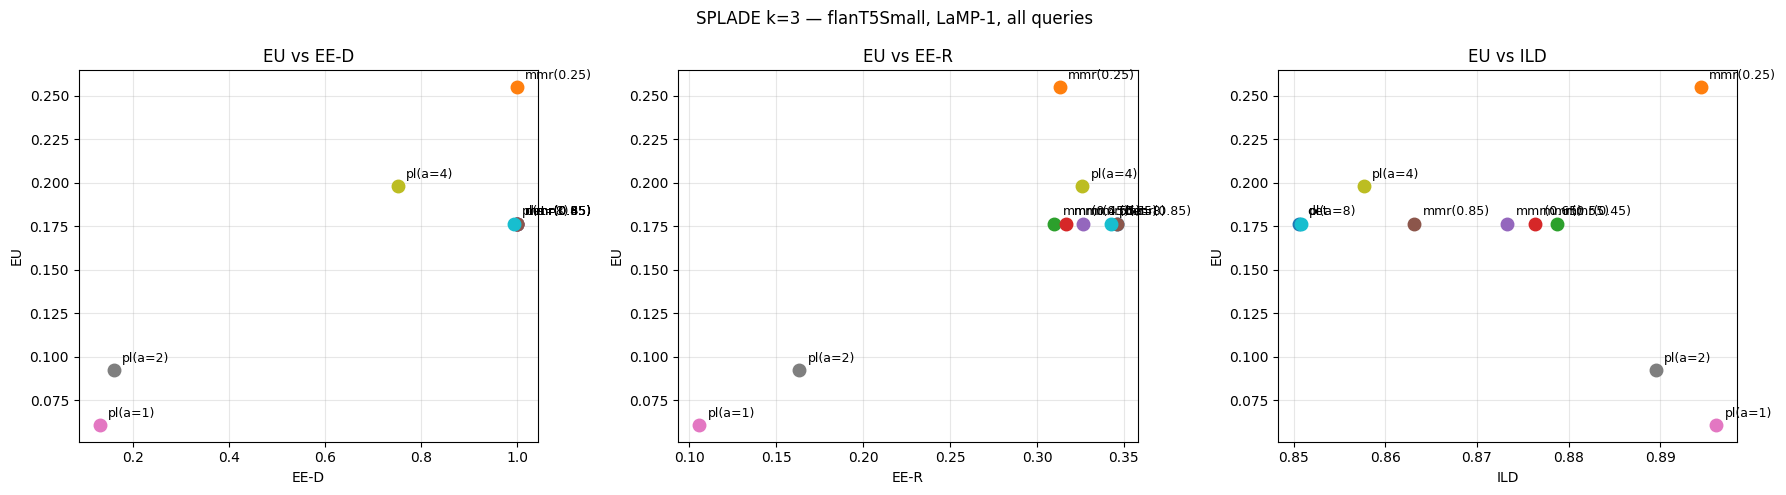

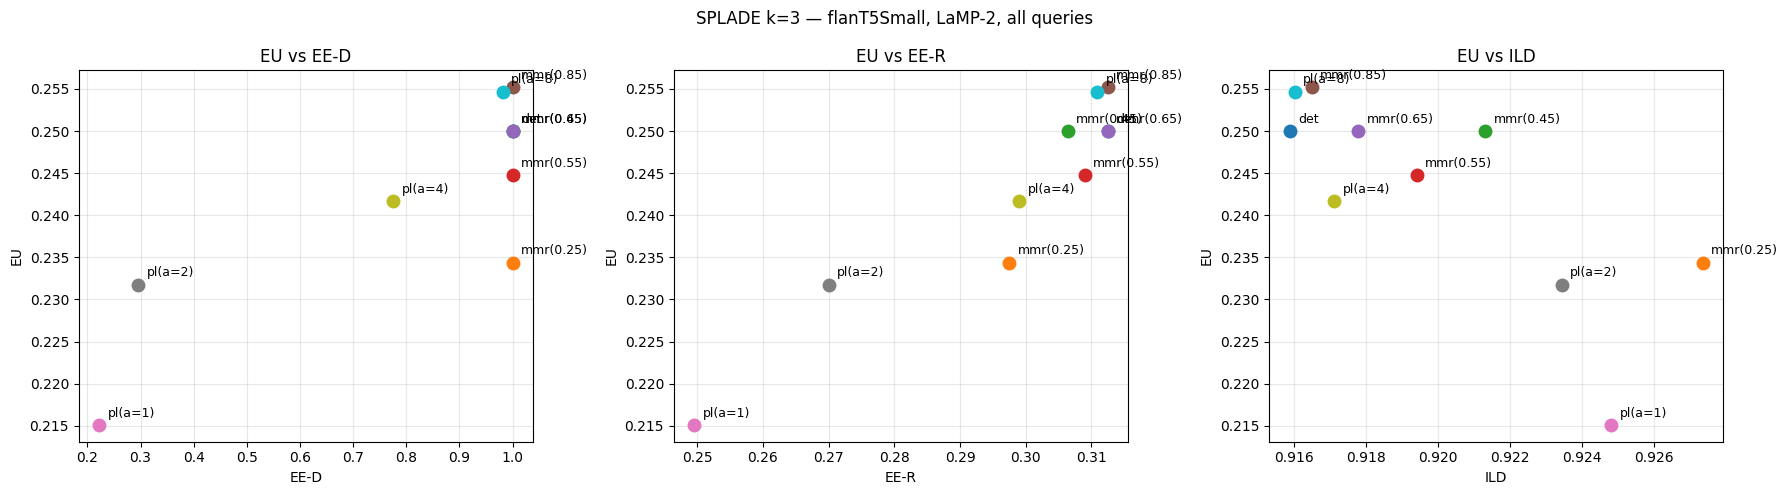

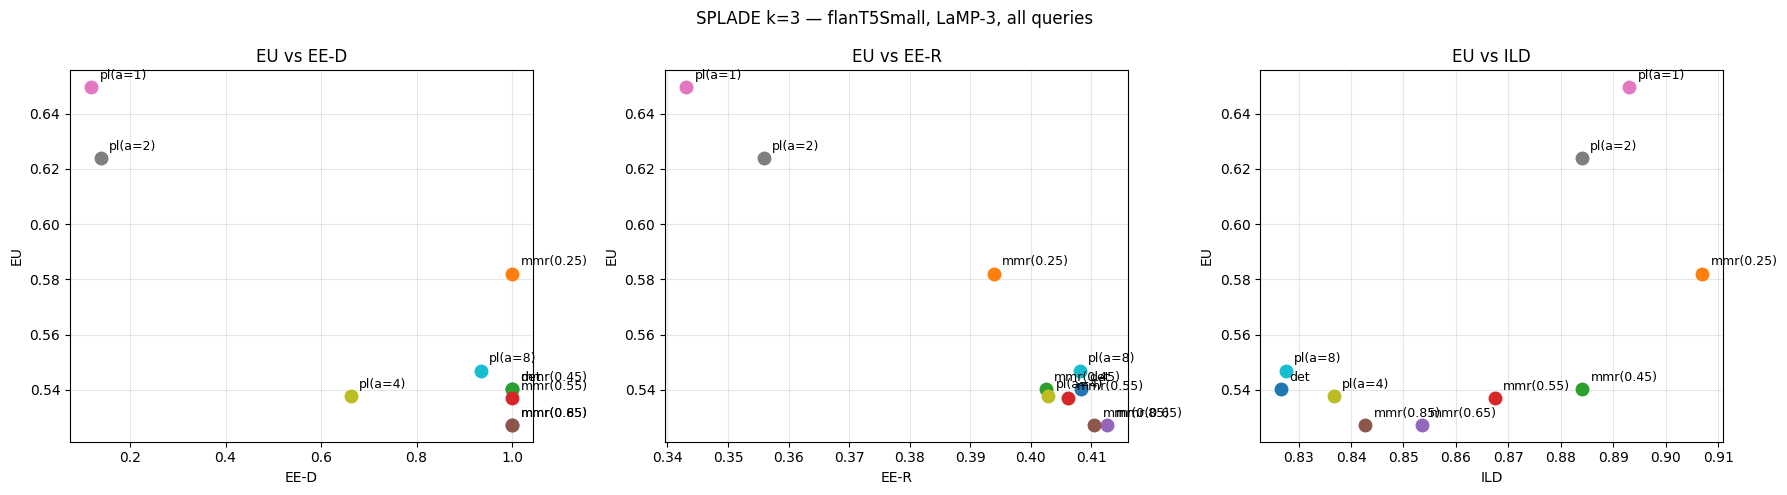

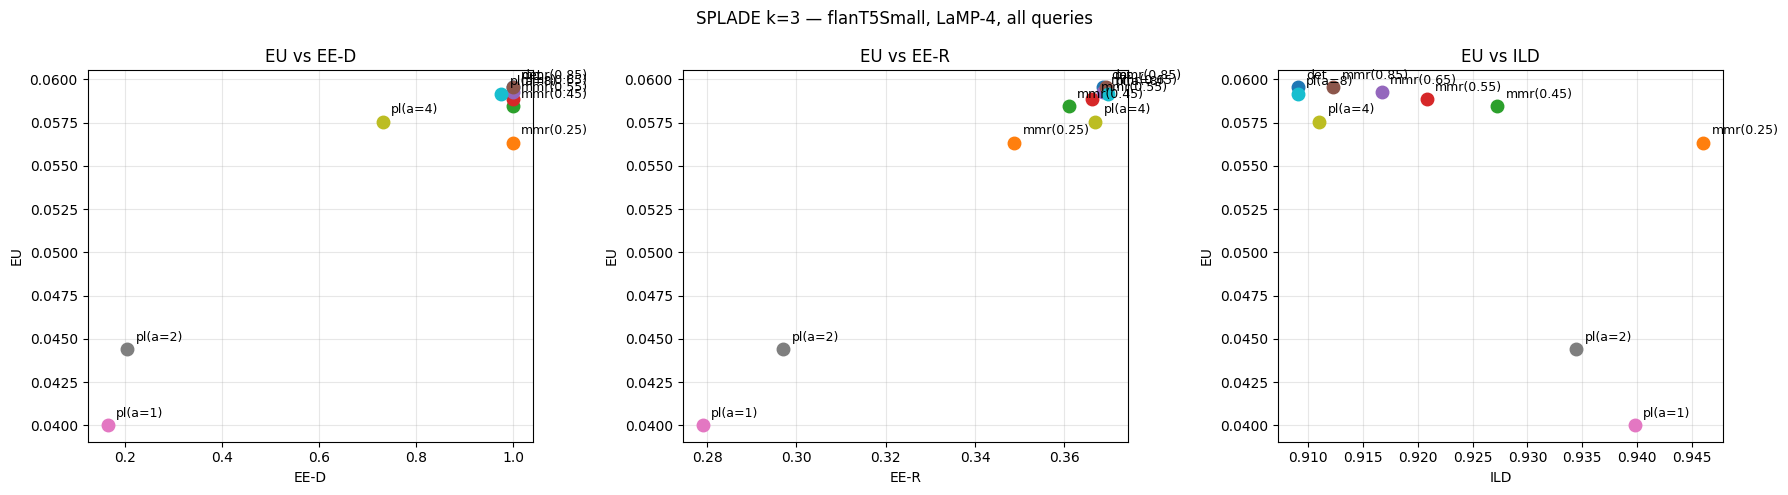

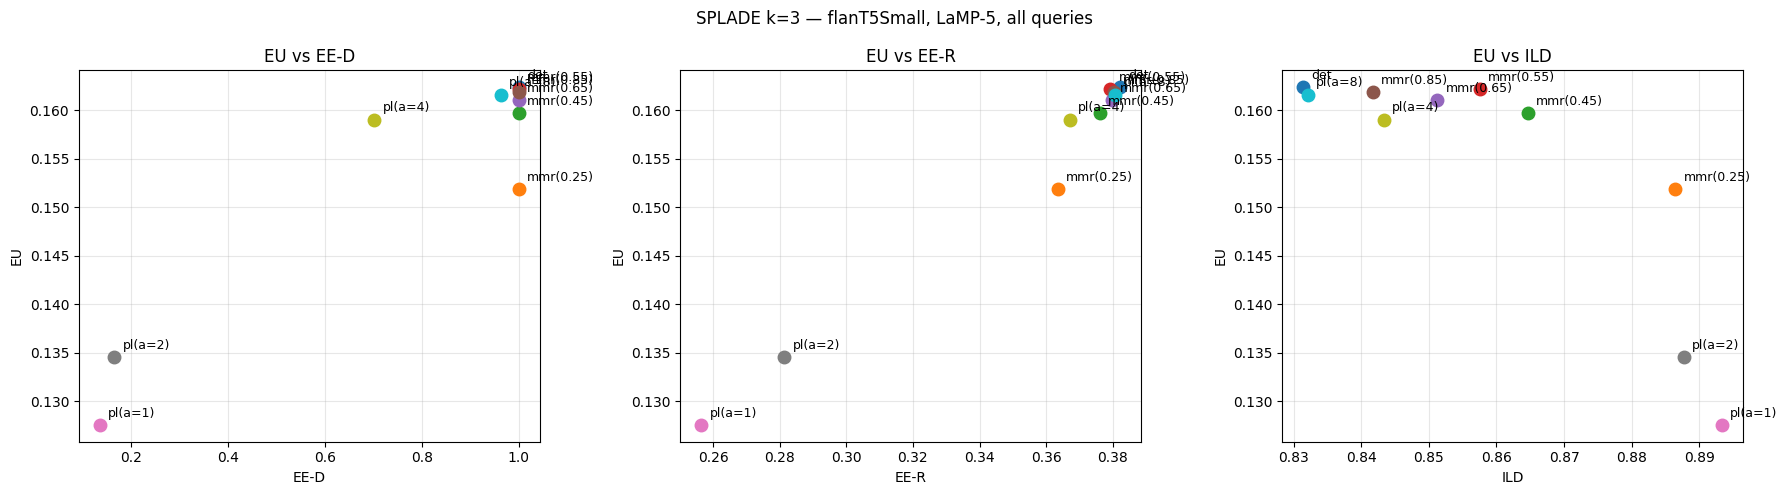

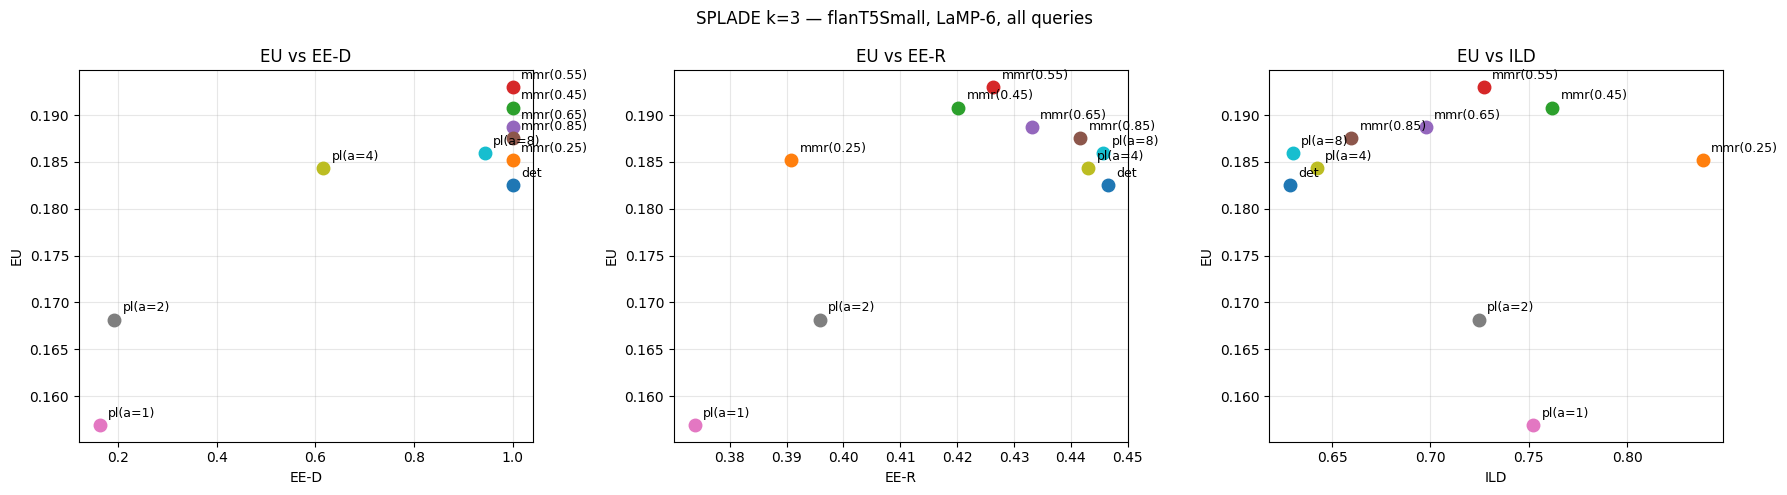

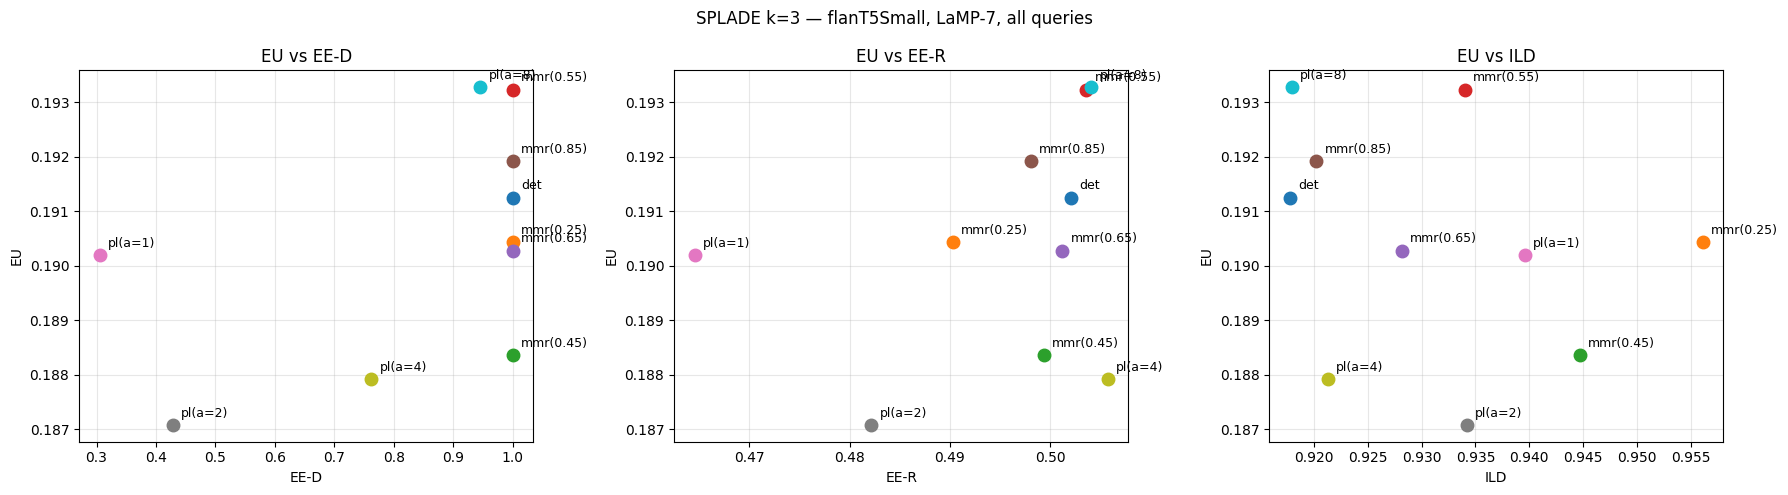

In [10]:
# SPLADE k=3 graphs: EU vs EE-D, EU vs EE-R, EU vs ILD
import matplotlib.pyplot as plt
from framework import build_macro_comparison_rows, list_run_dirs


def _splade_k3_label(row):
    method = row.get("rerank_method")
    if method == "deterministic":
        return "det"
    if method == "mmr":
        return f"mmr({row.get('mmr_lambda')})"
    if method == "pl":
        return f"pl(a={row.get('pl_alpha')})"
    return str(method)


all_macro_rows = build_macro_comparison_rows(list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs")))

splade_k3_macro_rows = [
    r
    for r in all_macro_rows
    if r.get("dataset_type") == "lamp"
    and r.get("lamp_split_type") == SPLADE_K3_SPLIT
    and r.get("generator_name") == SPLADE_K3_GEN
    and r.get("ranker") == "splade"
    and r.get("top_k") == SPLADE_K3_TOP_K
]

if not splade_k3_macro_rows:
    print("No SPLADE k=3 macro rows found.")
else:
    for lamp_num in SPLADE_K3_LAMPS:
        lamp_rows = [r for r in splade_k3_macro_rows if r.get("lamp_num") == lamp_num]
        if not lamp_rows:
            print(f"LaMP-{lamp_num}: no SPLADE k=3 rows")
            continue

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"SPLADE k=3 — flanT5Small, LaMP-{lamp_num}, all queries", fontsize=12)

        pairs = [
            ("ee_disparity", "expected_utility", "EE-D", "EU"),
            ("ee_relevance", "expected_utility", "EE-R", "EU"),
            ("avg_ild_jaccard", "expected_utility", "ILD", "EU"),
        ]

        for ax, (xk, yk, xl, yl) in zip(axes, pairs):
            for row in lamp_rows:
                x = row.get(xk)
                y = row.get(yk)
                if x is None or y is None:
                    continue
                label = _splade_k3_label(row)
                ax.plot(x, y, marker="o", linestyle="None", markersize=9)
                ax.annotate(label, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
            ax.set_xlabel(xl)
            ax.set_ylabel(yl)
            ax.set_title(f"{yl} vs {xl}")
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

## PL-MMR Hybrid: SPLADE k=5, LaMP 4

In [1]:
import copy
import os
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

PLMMR_LAMP = 4
PLMMR_GEN = "flanT5Small"
PLMMR_SPLIT = "user"
PLMMR_TOP_K = 5
PLMMR_SEED = 42
PLMMR_REUSE_POLICY = "smart"
PLMMR_NUM_QUERIES = None
PLMMR_ALPHAS = [4, 8]
PLMMR_LAMBDA = 0.55
PLMMR_SAMPLES = 10

print(
    f"PL-MMR hybrid stage: LaMP-{PLMMR_LAMP}, ranker=splade, top_k={PLMMR_TOP_K}, "
    f"generator={PLMMR_GEN}, alphas={PLMMR_ALPHAS}, lambda={PLMMR_LAMBDA}, "
    f"num_queries={PLMMR_NUM_QUERIES}"
)
print()

# Check for existing incomplete run to resume
incomplete_run = "experiment_runs/20260511_114929_lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42"
if os.path.exists(incomplete_run):
    print(f"Found incomplete run at: {incomplete_run}")
    print("Resuming from checkpoint...")
    print()
    
    # Read manifest to get the config
    import json
    manifest_path = os.path.join(incomplete_run, "manifest.json")
    with open(manifest_path, "r") as f:
        manifest = json.load(f)
    
    # Recreate config from manifest
    cfg_dict = manifest.get("config", {})
    resume_cfg = RunConfig(
        dataset=DatasetConfig(
            dataset_type=cfg_dict["dataset"]["dataset_type"],
            lamp_num=cfg_dict["dataset"]["lamp_num"],
            lamp_split_type=cfg_dict["dataset"]["lamp_split_type"],
            num_queries=cfg_dict["dataset"]["num_queries"],
        ),
        retrieval=RetrievalConfig(
            ranker=cfg_dict["retrieval"]["ranker"],
            top_k=cfg_dict["retrieval"]["top_k"],
        ),
        rerank=RerankConfig(
            method=cfg_dict["rerank"]["method"],
            pl_alpha=cfg_dict["rerank"]["pl_alpha"],
            pl_samples=cfg_dict["rerank"]["pl_samples"],
            mmr_lambda=cfg_dict["rerank"]["mmr_lambda"],
            seed=cfg_dict["rerank"]["seed"],
        ),
        generation=GenerationConfig(
            generator_name=cfg_dict["generation"]["generator_name"],
            multi_gpu=cfg_dict["generation"]["multi_gpu"],
        ),
        metrics=MetricsConfig(
            compute_ee=cfg_dict["metrics"]["compute_ee"],
            compute_eu=cfg_dict["metrics"]["compute_eu"],
            compute_diversity=cfg_dict["metrics"]["compute_diversity"],
        ),
        checkpoint=CheckpointConfig(
            flush_every=cfg_dict["checkpoint"]["flush_every"],
            report_every_queries=cfg_dict["checkpoint"]["report_every_queries"],
        ),
        resume=True,
        run_id=None,
        run_dir=incomplete_run,
    )
    
    batch = BatchExperimentRunner(
        [resume_cfg],
        batch_id="lamp4_splade_k5_pl_mmr_resume",
        reuse_policy=PLMMR_REUSE_POLICY,
    )
    out = batch.run_all()
    plmmr_run_dirs = out.get("run_dirs", [])
    
    print(f"\nResume complete. Run dir:")
    for d in plmmr_run_dirs:
        print(f"  - {d}")
else:
    print(f"No incomplete run found. Run fresh PL-MMR configs...")


/Users/asimk/Code/Fair-RAG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0511 15:34:57.740000 7091 .venv/lib/python3.11/site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


PL-MMR hybrid stage: LaMP-4, ranker=splade, top_k=5, generator=flanT5Small, alphas=[4, 8], lambda=0.55, num_queries=None

Found incomplete run at: experiment_runs/20260511_114929_lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42
Resuming from checkpoint...

[Batch] Resuming run 1/1: lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 10230.40it/s]


Resuming run: 732 summarized queries already completed
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42 | Average after 772 queries: EE-D=0.2486, EE-R=0.3045, ILD=0.9360, EU=0.0442
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42 | Average after 812 queries: EE-D=0.2438, EE-R=0.3000, ILD=0.9365, EU=0.0440
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42 | Average after 833 queries: EE-D=0.2462, EE-R=0.3035, ILD=0.9363, EU=0.0445
Completed setting: lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260511_114929_lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260511_114929_lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42/macro_summary.json
[Batch] Summary written to /Users/asimk/Code/Fair-RAG/experiment_run

In [4]:
# Run additional PL-MMR configurations (alpha=1,2)
import copy
import os
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

# Be robust to kernel restarts.
REPO_ROOT = globals().get("REPO_ROOT", os.path.abspath(os.getcwd()))
PLMMR_LAMP = globals().get("PLMMR_LAMP", 4)
PLMMR_GEN = globals().get("PLMMR_GEN", "flanT5Small")
PLMMR_SPLIT = globals().get("PLMMR_SPLIT", "user")
PLMMR_TOP_K = globals().get("PLMMR_TOP_K", 5)
PLMMR_SEED = globals().get("PLMMR_SEED", 42)
PLMMR_REUSE_POLICY = globals().get("PLMMR_REUSE_POLICY", "smart")
PLMMR_NUM_QUERIES = globals().get("PLMMR_NUM_QUERIES", None)
PLMMR_LAMBDA = globals().get("PLMMR_LAMBDA", 0.55)
PLMMR_SAMPLES = globals().get("PLMMR_SAMPLES", 10)

additional_alphas = [1, 2]

all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

base = RunConfig(
    dataset=DatasetConfig(
        dataset_type="lamp",
        lamp_num=PLMMR_LAMP,
        lamp_split_type=PLMMR_SPLIT,
        num_queries=PLMMR_NUM_QUERIES,
    ),
    retrieval=RetrievalConfig(ranker="splade", top_k=PLMMR_TOP_K),
    rerank=RerankConfig(
        method="pl_mmr",
        pl_alpha=1,
        pl_samples=PLMMR_SAMPLES,
        mmr_lambda=PLMMR_LAMBDA,
        seed=PLMMR_SEED,
    ),
    generation=GenerationConfig(generator_name=PLMMR_GEN, multi_gpu=False),
    metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
    checkpoint=CheckpointConfig(flush_every=1, report_every_queries=40),
    resume=False,
    run_id=None,
)

cfgs = []
for alpha in additional_alphas:
    cfg = copy.deepcopy(base)
    cfg.rerank.pl_alpha = alpha
    sid = setting_id(cfg)
    if sid not in existing_sids:
        cfgs.append(cfg)
    else:
        print(f"alpha={alpha}: already present ({sid}), skipping")

if not cfgs:
    print("No missing alpha settings among [1, 2].")
else:
    print(f"Running {len(cfgs)} missing PL-MMR setting(s) for LaMP-{PLMMR_LAMP}:")
    for cfg in cfgs:
        print(f"  - {setting_id(cfg)}")
    print()

    batch = BatchExperimentRunner(
        cfgs,
        batch_id=f"lamp{PLMMR_LAMP}_splade_k{PLMMR_TOP_K}_pl_mmr_a1_a2",
        reuse_policy=PLMMR_REUSE_POLICY,
    )
    out = batch.run_all()
    run_dirs = out.get("run_dirs", [])

    print("\nAlpha=1/2 stage complete. Run dir(s):")
    for d in run_dirs:
        print(f"  - {d}")


Running 2 missing PL-MMR setting(s) for LaMP-4:
  - lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42
  - lamp4_user__flanT5Small__splade__pl_mmr_a2_l055_s10__k5__nqall__seed42

[Batch] Starting run 1/2: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42 | Average after 40 queries: EE-D=0.1483, EE-R=0.1945, ILD=0.9486, EU=0.0285
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42 | Average after 80 queries: EE-D=0.1664, EE-R=0.2690, ILD=0.9411, EU=0.0336
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42 | Average after 120 queries: EE-D=0.2155, EE-R=0.3281, ILD=0.9367, EU=0.0404
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42 | Average after 160 queries: EE-D=0.1896, EE-R=0.3085, ILD=0.9388, EU=0.040

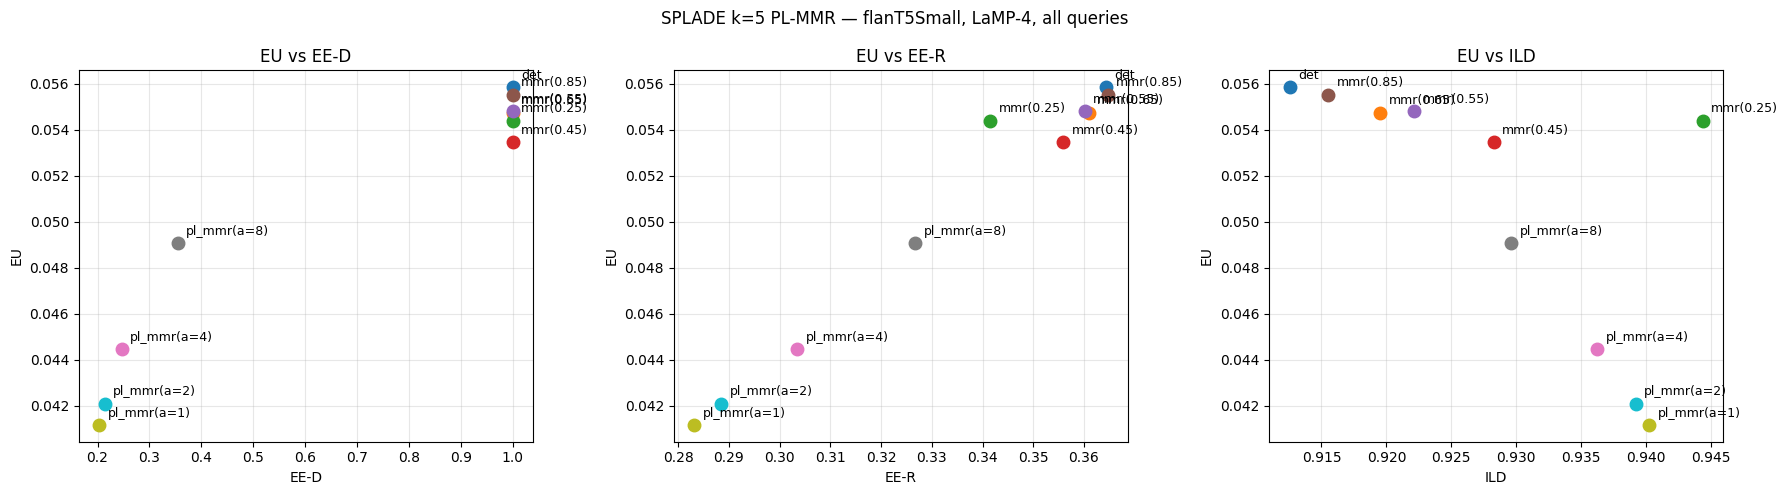

In [5]:
# SPLADE k=5 PL-MMR (LaMP-4) graphs: EU vs EE-D, EU vs EE-R, EU vs ILD
import os
import matplotlib.pyplot as plt
from framework import build_macro_comparison_rows, list_run_dirs


all_macro_rows = build_macro_comparison_rows(list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs")))

splade_k5_lamp4_rows = [
    r
    for r in all_macro_rows
    if r.get("dataset_type") == "lamp"
    and r.get("lamp_num") == PLMMR_LAMP
    and r.get("lamp_split_type") == PLMMR_SPLIT
    and r.get("generator_name") == PLMMR_GEN
    and r.get("ranker") == "splade"
    and r.get("top_k") == PLMMR_TOP_K
    and (
        r.get("rerank_method") in {"deterministic", "mmr"}
        or (r.get("rerank_method") == "pl_mmr" and float(r.get("mmr_lambda", -1)) == float(PLMMR_LAMBDA))
    )
]


def _splade_k5_lamp4_label(row):
    method = row.get("rerank_method")
    if method == "deterministic":
        return "det"
    if method == "mmr":
        return f"mmr({row.get('mmr_lambda')})"
    if method == "pl_mmr":
        return f"pl_mmr(a={row.get('pl_alpha')})"
    return str(method)


if not splade_k5_lamp4_rows:
    print("No SPLADE k=5 LaMP-4 rows found.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"SPLADE k=5 PL-MMR — {PLMMR_GEN}, LaMP-{PLMMR_LAMP}, all queries",
        fontsize=12,
    )

    pairs = [
        ("ee_disparity", "expected_utility", "EE-D", "EU"),
        ("ee_relevance", "expected_utility", "EE-R", "EU"),
        ("avg_ild_jaccard", "expected_utility", "ILD", "EU"),
    ]

    for ax, (xk, yk, xl, yl) in zip(axes, pairs):
        for row in splade_k5_lamp4_rows:
            x = row.get(xk)
            y = row.get(yk)
            if x is None or y is None:
                continue
            label = _splade_k5_lamp4_label(row)
            ax.plot(x, y, marker="o", linestyle="None", markersize=9)
            ax.annotate(label, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.set_title(f"{yl} vs {xl}")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [6]:
# SPLADE k=5 PL-MMR (LaMP-4) pooled EU(norm) delta by EE-D bin
import json
import math
import os
import pandas as pd
from framework import build_query_metric_rows

PLMMR_DISPARITY_LABELS = ["[0.0, 0.2)", "[0.2, 0.4)", "[0.4, 0.6)", "[0.6, 0.8)", "[0.8, 1.0)"]
PLMMR_BASELINES = [("det", "det"), ("mmr065", "mmr(0.65)")]


def _fmt_signed(v):
    if v is None:
        return "NA"
    if abs(v) < 5e-4:
        return "0.00"
    return f"{v:+.2f}"


def _setting_label_k5(row):
    method = row.get("rerank_method")
    if method == "deterministic":
        return "det"
    if method == "mmr":
        lam = row.get("mmr_lambda")
        return f"mmr({float(lam):.2f})" if lam is not None else "mmr"
    if method == "pl_mmr":
        alpha = row.get("pl_alpha")
        return f"pl_mmr(a={int(alpha)})" if alpha is not None else "pl_mmr"
    return str(method)


def _bin_label_from_disparity_k5(val):
    if val is None or pd.isna(val):
        return None
    d = min(max(float(val), 0.0), 0.999999)
    idx = min(int(math.floor(d / 0.2)), 4)
    return PLMMR_DISPARITY_LABELS[idx]


def _collect_splade_k5_lamp4_rows() -> pd.DataFrame:
    rows = []
    valid_alphas = {1, 2, 4, 8}

    for run_dir in list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs")):
        manifest_path = os.path.join(run_dir, "manifest.json")
        if not os.path.exists(manifest_path):
            continue

        with open(manifest_path, "r", encoding="utf-8") as f:
            manifest = json.load(f)

        config = manifest.get("config", {})
        dataset = config.get("dataset", {})
        generation = config.get("generation", {})
        retrieval = config.get("retrieval", {})
        rerank = config.get("rerank", {})

        status = str(manifest.get("status") or "").lower()
        completed = status in {"completed", "complete", "finished"}
        expected = manifest.get("expected_queries")
        done = manifest.get("n_queries_completed")
        if not completed and not (expected is not None and done is not None and done >= expected):
            continue

        if dataset.get("dataset_type") != "lamp":
            continue
        if int(dataset.get("lamp_num")) != int(PLMMR_LAMP):
            continue
        if dataset.get("lamp_split_type") != PLMMR_SPLIT:
            continue
        if generation.get("generator_name") != PLMMR_GEN:
            continue
        if retrieval.get("ranker") != "splade":
            continue
        if int(retrieval.get("top_k")) != int(PLMMR_TOP_K):
            continue

        method = rerank.get("method")
        if method == "deterministic":
            pass
        elif method == "mmr":
            lam = rerank.get("mmr_lambda")
            if lam is None or abs(float(lam) - 0.65) > 1e-9:
                continue
        elif method == "pl_mmr":
            alpha = rerank.get("pl_alpha")
            lam = rerank.get("mmr_lambda")
            if alpha is None or int(alpha) not in valid_alphas:
                continue
            if lam is None or abs(float(lam) - float(PLMMR_LAMBDA)) > 1e-9:
                continue
        else:
            continue

        run_rows = build_query_metric_rows([run_dir])
        for r in run_rows:
            rr = dict(r)
            rr["run_dir"] = run_dir
            rr["setting"] = _setting_label_k5(rr)
            rows.append(rr)

    return pd.DataFrame(rows)


def _normalize_lamp_rows_k5(lamp_df: pd.DataFrame, lamp_num: int) -> pd.DataFrame:
    if lamp_df.empty:
        return lamp_df

    out_rows = []
    is_lower_better_eu = lamp_num == 3
    eu_upper_bound = 4.0

    for qid, qdf in lamp_df.groupby("qid", dropna=False):
        ee_rel_candidates = [v for v in qdf.get("ee_relevance", []) if pd.notna(v)]
        ee_rel_denom = max(ee_rel_candidates) if ee_rel_candidates else None

        ild_candidates = [v for v in qdf.get("avg_ild_jaccard", []) if pd.notna(v)]
        ild_denom = max(ild_candidates) if ild_candidates else None

        if is_lower_better_eu:
            eu_candidates = []
            for _, row in qdf.iterrows():
                min_u = row.get("min_utility")
                if pd.notna(min_u):
                    eu_candidates.append(eu_upper_bound - float(min_u))
            eu_denom = max(eu_candidates) if eu_candidates else None
        else:
            eu_candidates = [float(v) for v in qdf.get("max_utility", []) if pd.notna(v)]
            eu_denom = max(eu_candidates) if eu_candidates else None

        for _, row in qdf.iterrows():
            row = row.copy()

            eu_num = row.get("expected_utility")
            if pd.notna(eu_num):
                eu_num = float(eu_num)
                if is_lower_better_eu:
                    eu_num = eu_upper_bound - eu_num
            else:
                eu_num = None

            row["ee_relevance_norm"] = (float(row.get("ee_relevance")) / ee_rel_denom) if (pd.notna(row.get("ee_relevance")) and ee_rel_denom not in [None, 0]) else None
            row["ee_disparity_norm"] = float(row.get("ee_disparity")) if pd.notna(row.get("ee_disparity")) else None
            row["avg_ild_jaccard_norm"] = (float(row.get("avg_ild_jaccard")) / ild_denom) if (pd.notna(row.get("avg_ild_jaccard")) and ild_denom not in [None, 0]) else None
            row["expected_utility_norm"] = (eu_num / eu_denom) if (eu_num is not None and eu_denom not in [None, 0]) else None
            row["ee_d_bin"] = _bin_label_from_disparity_k5(row["ee_disparity_norm"])
            out_rows.append(row)

    return pd.DataFrame(out_rows)


def _build_unified_row_for_lamp_k5(method_df: pd.DataFrame, lamp_num: int, baseline_mode: str, baseline_label: str) -> dict:
    base_row = {
        "LaMP": lamp_num,
        "Baseline": baseline_label,
        "Ranker": "splade",
        "Model (baseline utility)": "NA",
        "PL-MMR runs": 0,
        "Expected PL-MMR instances": 0,
        "Observed PL-MMR instances": 0,
        "Status": "ok",
    }

    for label in PLMMR_DISPARITY_LABELS:
        base_row[label] = "NA"
        base_row[f"{label} (n)"] = 0

    lamp_df = method_df[method_df["lamp_num"] == lamp_num].copy()
    if lamp_df.empty:
        base_row["Status"] = "missing runs"
        return base_row

    if baseline_mode == "det":
        base_df = lamp_df[lamp_df["setting"] == "det"].copy()
    else:
        base_df = lamp_df[lamp_df["setting"] == "mmr(0.65)"].copy()

    if base_df.empty:
        base_row["Status"] = "missing baseline"
        return base_row

    plmmr_df = lamp_df[lamp_df["setting"].str.startswith("pl_mmr(")].copy()
    if plmmr_df.empty:
        base_row["Status"] = "missing PL-MMR runs"
        return base_row

    plmmr_run_ids = sorted(plmmr_df["run_dir"].dropna().unique().tolist())

    baseline_utility = base_df["expected_utility_norm"].dropna().mean()
    if pd.notna(baseline_utility):
        base_row["Model (baseline utility)"] = f"splade+{PLMMR_GEN} ({float(baseline_utility):.3f})"

    base_row["PL-MMR runs"] = int(len(plmmr_run_ids))

    baseline_by_qid = (
        base_df.dropna(subset=["qid", "expected_utility_norm"])
        .groupby("qid", dropna=False)["expected_utility_norm"]
        .mean()
        .rename("base_eu")
        .reset_index()
    )

    expected_instances = int(len(baseline_by_qid) * len(plmmr_run_ids))

    baseline_eu_by_bin = {label: [] for label in PLMMR_DISPARITY_LABELS}
    plmmr_eu_by_bin = {label: [] for label in PLMMR_DISPARITY_LABELS}

    for run_id in plmmr_run_ids:
        run_df = plmmr_df[plmmr_df["run_dir"] == run_id].copy()
        run_q = (
            run_df.dropna(subset=["qid", "ee_d_bin", "expected_utility_norm"])
            [["qid", "ee_d_bin", "expected_utility_norm"]]
            .rename(columns={"expected_utility_norm": "plmmr_eu"})
        )

        merged = run_q.merge(baseline_by_qid, on="qid", how="inner")
        for _, row in merged.iterrows():
            b = row.get("ee_d_bin")
            if b not in baseline_eu_by_bin:
                continue
            baseline_eu_by_bin[b].append(float(row["base_eu"]))
            plmmr_eu_by_bin[b].append(float(row["plmmr_eu"]))

    observed_instances = int(sum(len(v) for v in plmmr_eu_by_bin.values()))

    for label in PLMMR_DISPARITY_LABELS:
        b_vals = baseline_eu_by_bin[label]
        p_vals = plmmr_eu_by_bin[label]
        delta = ((sum(p_vals) / len(p_vals)) - (sum(b_vals) / len(b_vals))) if (b_vals and p_vals) else None
        base_row[label] = _fmt_signed(delta)
        base_row[f"{label} (n)"] = len(p_vals)

    base_row["Expected PL-MMR instances"] = expected_instances
    base_row["Observed PL-MMR instances"] = observed_instances

    if observed_instances < expected_instances:
        base_row["Status"] = "partial PL-MMR coverage"

    return base_row


plmmr_query_df = _collect_splade_k5_lamp4_rows()
if plmmr_query_df.empty:
    print("No completed SPLADE k=5 PL-MMR runs found for pooled-delta tables.")
else:
    method_df = _normalize_lamp_rows_k5(plmmr_query_df, PLMMR_LAMP)

    if method_df.empty:
        print("No normalized SPLADE k=5 PL-MMR rows available.")
    else:
        rows = []
        for baseline_mode, baseline_label in PLMMR_BASELINES:
            rows.append(_build_unified_row_for_lamp_k5(method_df, PLMMR_LAMP, baseline_mode, baseline_label))

        out_df = pd.DataFrame(rows)

        display_cols = [
            "LaMP",
            "Baseline",
            "Ranker",
            "Model (baseline utility)",
            "PL-MMR runs",
            "Expected PL-MMR instances",
            "Observed PL-MMR instances",
            *PLMMR_DISPARITY_LABELS,
            *[f"{label} (n)" for label in PLMMR_DISPARITY_LABELS],
            "Status",
        ]

        print(f"\nLaMP-{PLMMR_LAMP}: PL-MMR pooled EU(norm) delta by EE-D bin (alphas={sorted({1,2,4,8})})")
        display(out_df[display_cols])



LaMP-4: PL-MMR pooled EU(norm) delta by EE-D bin (alphas=[1, 2, 4, 8])


,LaMP,Baseline,Ranker,Model (baseline utility),PL-MMR runs,Expected PL-MMR instances,Observed PL-MMR instances,"[0.0, 0.2)","[0.2, 0.4)","[0.4, 0.6)","[0.6, 0.8)","[0.8, 1.0)","[0.0, 0.2) (n)","[0.2, 0.4) (n)","[0.4, 0.6) (n)","[0.6, 0.8) (n)","[0.8, 1.0) (n)",Status
0,4,det,splade,splade+flanT5Small (0.365),4,3328,3328,-0.10,-0.04,+0.01,-0.02,-0.00,1866,814,406,214,28,ok
1,4,mmr(0.65),splade,splade+flanT5Small (0.369),4,3328,3328,-0.12,-0.02,+0.00,-0.01,+0.01,1866,814,406,214,28,ok
